In [ ]:
# 21-02-2026

# ST-FMR analysis

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re
import os 
import glob
import sys
from pathlib import Path
import itertools
from uncertainties import ufloat
from collections import defaultdict
import math

# STFMR Class 1.1
class STFMR:
    def __init__(self, folder=None, filename=None, thicknessFolder=None, voltage_unit='uV', d_FM=None, d_NM=None, Ms=None, Width=None, Length=None, rho_FM=None, rho_NM=None, used_fields='Pos', sample_name=None):
        """
        Parameters
        ----------
        filename : str
            Path to data file
        """
        if folder is not None:
            self.folder = folder
        if filename is not None:
            self.filename = filename
        if thicknessFolder is not None:
            self.thicknessFolder = thicknessFolder

        self.pattern = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Trace_(?P<trace>\d+)"
        )

        self.patternDC = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Curr_(?P<dc>[+-]?\d+(?:\.\d+)?)mA_"
            r"Trace_(?P<trace>\d+)"
        )

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 1.055e-34

        # System settings
        self.voltage_unit = voltage_unit  
        self.d_FM = d_FM
        self.rho_FM = rho_FM
        self.rho_NM = rho_NM
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Length = Length
        self.used_fields=used_fields
        self.sample_name = sample_name
        if self.rho_FM is not None and self.rho_NM is not None:
            self.current_ditribution(self.rho_FM, self.rho_NM)

    def get_key(self, filepath):
        """Create a key for a file, which describes the most important parameters of the datafile. Distinghuishes between measurement with or without DC."""
        filename = Path(filepath).name
        if 'Curr' in filename:
            match = self.patternDC.search(filename)
            if match:
                phi, freq, pow_, dc, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
        else:
            dc = 0
            match = self.pattern.search(filename)
            if match:
                phi, freq, pow_, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
    
    def group_files(self, folder=None):
        """Groups files based on their key. Will be performed for the inputted folder in the class. """
        if folder is None:
            folder = self.folder

        grouped_files = {}
        for filename in os.listdir(folder):
            if filename.lower().endswith(".txt"): 
                (phi, freq, pow_, dc, trace) = self.get_key(filename)
                key = (phi, freq, pow_, dc)
                grouped_files.setdefault(key, []).append(filename)
            # print(grouped_files)
        return grouped_files

    def parse_resistance(self, first_line):
        # Look for "R = ... Ohm" with flexible spaces
        match = re.search(r"R\s*=\s*([0-9.]+)\s*Ohm", first_line)
        if match:
            return float(match.group(1))
        else:
            raise ValueError(f"Could not parse resistance from line: '{first_line}'")
        
    def read_file(self, filepath):
         # Read the resistance value from the first line
        with open(filepath, 'r') as f:
            first_line = f.readline().strip()
        # Extract resistance value (assuming format 'R =93.6Ohm')
        try:
            R = self.parse_resistance(first_line)
        except ValueError as e:
            print(e)
            R = None  # or handle as needed
        # Read the actual data starting from the second line
        df = pd.read_csv(filepath, sep='\t', skiprows=1, header=0)
        average = ('H_interpolated' in df)

        if average:
            df = df.rename(columns={'H_interpolated': 'H_given'})
            df['H_mag'] = df['H_given']
        df = df.sort_values(by='H_given')

        # Make a copy of the magnitude column
        df["H_signed"] = df["H_mag"]
        H = df["H_given"].to_numpy()
        H_signed = H.copy()
        idx_half = len(H) // 2
        df = df.fillna(0)

        if min(H) >= 0 or average:
            return R, df
        else:
        # elif abs(H[0]) == abs(H[-1]):
            # print("Detected symmetric sweep: multiplying first half with -1.")
            df.loc[:idx_half, "H_signed"] *= -1
            if self.used_fields == 'Neg':
                # Keep only positive fields
                df = df.iloc[:idx_half+1].reset_index(drop=True)
            elif self.used_fields == 'Pos':
                # Keep only negative fields
                df = df.iloc[idx_half:].reset_index(drop=True)
            elif self.used_fields == 'Both':
                df.loc[:idx_half, "H_signed"] *= -1
            return R, df
    
    # -----------Analyzing and plotting data----------- 
    def current_ditribution(self, rho_FM, rho_NM, I0=None):
        if I0 is None:
            J_FM = 1/((self.Width*self.d_FM) * (1 + rho_FM/rho_NM))
            J_NM = 1/((self.Width*self.d_NM) * (1 + rho_FM/rho_NM))
            ratio = J_FM/J_NM
            print(f'Expected current distribution based on resistivities: FM: {ratio*100} % and NM: {(1/ratio)* 100} %')
        if I0 is not None:
            J_FM = I0/((self.Width*self.d_FM) * (1 + rho_FM/rho_NM))
            J_NM = I0/((self.Width*self.d_NM) * (1 + rho_FM/rho_NM))
            ratio = J_FM/J_NM
            print(f'Expected current distribution based on resistivities: FM: {ratio*100} % and NM: {(1/ratio)* 100} %')
            print(f'Currents: J_FM: {J_FM} % and J_NM: {(J_NM)} %')

    def fit_Vmix(self, filepath, plot=True, textbox=True, cutoff=8):
        # print(filepath)
        R, df = self.read_file(filepath)
        keys = self.get_key(filepath)

        # Perform fit using uV
        if self.voltage_unit == 'uV':
            df['Vx'] *= 1e6  # Convert Vx to microvolts
            df['Vy'] *= 1e6  # Convert Vy to microvolts
            df['Vx_err'] *= 1e6
            df['Vy_err'] *= 1e6
        elif self.voltage_unit == 'mV':
            df['Vx'] *= 1e3  # Convert Vx to millivolts
            df['Vy'] *= 1e3  # Convert Vy to millivolts
            df['Vx_err'] *= 1e3
            df['Vy_err'] *= 1e3

        if self.used_fields == 'Pos':
            H_min, H_max = 0, 400
        elif self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0

        df_filtered = df[(df["H_signed"] >= H_min) & (df["H_signed"] <= H_max)] # creating a proper field range

        fit_params, cov = self.fit_stfmr(df_filtered["H_signed"][cutoff:-cutoff], df_filtered["Vx"][cutoff:-cutoff]) # cutoff to remove outlier points
        
        if plot == True:
            ax = self.plot_Vmix(df_filtered, R, fit_params, keys, textbox=textbox)
            plt.show()
        return fit_params, cov

    def plot_Vmix(self, df, R, fit_params=None, keys=None, textbox=False, ax=None, sample=None):
        if ax is None:
            plt.figure(figsize=(8,6))
            ax = plt.gca()
        ax.errorbar(df["H_given"], df["Vx"], df["Vx_err"], df.get("H_err"), fmt='.', label = sample if sample is not None else "data")

        H = self.create_fit_array(min(df["H_signed"]), max(df["H_signed"]), num_points=200)

        if fit_params is not None:      
            ax.plot(H, STFMR.stfmr_model(H, **fit_params), '-', label="fit")

            Vs, Va, Hres, Delta, C, D = fit_params["Vs"], fit_params["Va"], fit_params["Hres"], fit_params["Delta"], fit_params["C"], fit_params["D"]
            ax.plot(H, STFMR.stfmr_symmetric(H, Vs, Hres, Delta, C, D), '--', label="symmetric")
            ax.plot(H, STFMR.stfmr_asymmetric(H, Va, Hres, Delta, C, D), '--', label="asymmetric")
        
        if keys is not None:
            ax.set_title(f"Resistance={R}Ohm,Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm, DC={keys[3]}mA, Trace={keys[4]}")
            # ax.set_title(f"Mixing voltage versus magnetic field for sample {self.sample_name if self.sample_name is not None else ''}")

        if textbox and fit_params is not None:
            # --- Add textbox with fit parameters ---
            position = 0.8 if self.used_fields == 'Pos' else 0.05
            textstr = '\n'.join((
                r"$V_s=%.3g$" % Vs,
                r"$V_a=%.3g$" % Va,
                r"$H_{res}=%.3g$" % Hres,
                r"$\Delta=%.3g$" % Delta,
                r"$C=%.3g$" % C,
                # r"$D=%.3g$" % D
            ))
            # Place text box in lower right corner of the plot
            plt.gca().text(
                position, 0.22, textstr,
                transform=plt.gca().transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )

        ax.set_xlabel("Field (mT)")
        ax.set_ylabel(f"Vmix ({self.voltage_unit})")       
        ax.legend()
        return ax
    
    def plot_general(self, df, col_x, col_y):
        """General plotting function to plot anything"""
        if col_x not in df.columns or col_y not in df.columns:
            raise ValueError(f"Columns '{col_x}' or '{col_y}' not found in DataFrame.")
    
        x = df[col_x]
        y = df[col_y]
        
        # Plot
        plt.figure(figsize=(8, 5))
        plt.plot(x, y)
        plt.xlabel(col_x)
        plt.ylabel(col_y)
        plt.title(f"Plot of {col_y} vs {col_x}")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_traces(self):
        """Plotting different traces to check the differences between measurements"""
        if self.folder is not None:
            grouped_files = self.group_files()

            fig, ax = plt.subplots(len(grouped_files), 1, figsize=(8, 11*len(grouped_files)))
            for i, (key, files) in enumerate(grouped_files.items()):
                for f in files:
                    path = os.path.join(self.folder, f)
                    if 'Curr' in f:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nDC={dc}\nTrace={trace}")
                    else:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nTrace={trace}")
                    R, df = self.read_file(path)
                    # PLOT FUNCTION
                    ax[i].plot(df["H_signed"], df["Vx"], '.', label=f"Trace {trace}")
                    ax[i].set_xlabel("Field (mT)")
                    ax[i].set_ylabel(f"$Vmix$ ({self.voltage_unit})")
                    ax[i].legend(fontsize='small')
                    # PLOT FUNCTION
        elif self.filename is not None:
            pass
        else:
            sys.exit("Folder or filename not set. Please initialize STFMR with a folder path to datafiles.")

    def plot_quick_scans(self):
        """Plotting all traces of the folder in one figure"""
        plt.figure(figsize=(12,8))

        for file in os.listdir(self.folder):
            if not os.path.isfile(self.folder) and not file.lower().endswith(".txt"):
                    print(f"⚠️ Skipping {file}: no proper file.")
                    continue
            path = os.path.join(self.folder, file)
            key = self.get_key(file)
            R, df = self.read_file(path)
            plt.errorbar(df["H_given"], df["Vx"], df['Vx_err'], fmt='.', label=f"Frequency = {key[1]} GHz")
        plt.title(f"Scan of all frequencies, sample: {Path(self.folder).parts[0]}, resistance: {R:.2f} Ohm")
        plt.legend()
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")

    def plot_averages(self):
        """Plotting the averages of all traces in one figure"""
        if self.used_fields== 'Pos':
            output_folder = os.path.join(self.folder, "Averaged_Traces_posB")
        elif self.used_fields== 'Neg':
            output_folder = os.path.join(self.folder, "Averaged_Traces_negB")
        
        if not os.path.exists(output_folder):
            self.analyze_traces()

        plt.figure(figsize=(8,6))
        for file in os.listdir(output_folder):
            if not os.path.isfile(file) and not file.lower().endswith(".txt"):
                    print(f"⚠️ Skipping {file}: no proper file.")
                    continue
            path = os.path.join(output_folder, file)
            key = self.get_key(file)
            R, df = self.read_file(path)
            avg_Vx = np.mean(df['Vx'])
            df['Vx'] *= 1e6
            df['Vx_err'] *= 1e6
            plt.errorbar(df["H_given"], df["Vx"] - avg_Vx*1e6, df['Vx_err'], fmt='.', label=f"power= {key[2]} dBm") #Frequency = {key[1]} GHz,
        plt.title(f"Scan of all frequencies, sample: {Path(self.folder).parts[0]}, resistance: {R:.2f} Ohm")
        plt.legend()
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")

    def analyze_traces(self, plot=False, folder=None):
        """Function that takes measurements from different traces. Subsequently averages all datapoints and performs a fit for these datapoints. """
        if folder is None:
            folder = self.folder

        try:
            if self.used_fields== 'Pos':
                output_folder = os.path.join(folder, "Averaged_Traces_posB")
            elif self.used_fields== 'Neg':
                output_folder = os.path.join(folder, "Averaged_Traces_negB")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles with multiple traces.")
        print(output_folder)
        # Create folder if not exists, and delete all files in them
        os.mkdir(output_folder) if not os.path.exists(output_folder) else None
        [os.remove(f.path) for f in os.scandir(output_folder) if f.is_file()]

        # Collect files by (Phi, Freq, Pow, DC)
        grouped_files = self.group_files(folder=folder)

        # Process each group
        for key, files in grouped_files.items():
            try:
                phi, freq, pow_, dc = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Curr_{dc}mA_Trace_0.txt"
                # print(f"Averaging files for key: {key} into {outname}")
            except:
                raise ValueError(f"Something went wrong, might be wrong key length: {len(key)}")
            dfs = []
            for f in files:
                path = os.path.join(folder, f)
                R, df = self.read_file(path)
                dfs.append(df)

            avg_df = self.average_traces(dfs)

            # Save averaged file
            outpath = os.path.join(output_folder, outname)
            with open(outpath, "w") as f:
                f.write(f"R ={R}Ohm\n")  # Write resistance
            avg_df.to_csv(outpath, sep="\t", index=False, mode="a")
            self.fit_Vmix(outpath, plot=plot)
        return 

    def average_traces(self, dfs, n_points=None):
        # 1. Determine overlapping H range        
        H_grid = dfs[0]["H_given"]
        
        # 3. Interpolate all runs onto H_grid
        H_all = []
        Vx_all = []
        Vy_all = []
        Vx_err_all = []
        Vy_err_all = []
        
        for df in dfs:
            df_sorted = df.sort_values("H_signed")

            # Linear interpolation for each column
            H_interp = np.interp(H_grid, df_sorted["H_signed"], df_sorted["H_signed"])
            Vx_interp = np.interp(H_grid, df_sorted["H_signed"], df_sorted["Vx"])
            Vy_interp = np.interp(H_grid, df_sorted["H_signed"], df_sorted["Vy"])
            
            # Handle errors: fill NaN with zero if needed
            Vx_err = df_sorted.get("Vx_err", pd.Series(0, index=df_sorted.index))
            Vy_err = df_sorted.get("Vy_err", pd.Series(0, index=df_sorted.index))
            Vx_err_interp = np.interp(H_grid, df_sorted["H_signed"], Vx_err.fillna(0))
            Vy_err_interp = np.interp(H_grid, df_sorted["H_signed"], Vy_err.fillna(0))

            H_all.append(H_interp)
            Vx_all.append(Vx_interp)
            Vy_all.append(Vy_interp)
            Vx_err_all.append(Vx_err_interp)
            Vy_err_all.append(Vy_err_interp)
        
        # 4. Convert to numpy arrays
        H_all = np.vstack(H_all)
        H_err = np.std(H_all, axis=0, ddof=1)
        Vx_all = np.vstack(Vx_all)
        Vy_all = np.vstack(Vy_all)
        Vx_err_all = np.vstack(Vx_err_all)
        Vy_err_all = np.vstack(Vy_err_all)
        
        # 5. Average values
        Vx_avg = np.mean(Vx_all, axis=0)
        Vy_avg = np.mean(Vy_all, axis=0)
        
        # 6. Compute propagated error (std across runs + measurement error)
        Vx_std = np.std(Vx_all, axis=0, ddof=1)
        Vy_std = np.std(Vy_all, axis=0, ddof=1)
        Vx_err_avg = np.sqrt(Vx_std**2 + np.mean(Vx_err_all**2, axis=0))
        Vy_err_avg = np.sqrt(Vy_std**2 + np.mean(Vy_err_all**2, axis=0))
        
        # 7. Build averaged DataFrame
        avg_df = pd.DataFrame({
            "H_interpolated": H_grid,
            "H_err": H_err,
            "Vx": Vx_avg,
            "Vy": Vy_avg,
            "Vx_err": Vx_err_avg,
            "Vy_err": Vy_err_avg
        })
        return avg_df


    def average_fitparams(self, plot=False, folder=None):
        """"Creates a .csv file with averages of the fitting variables from different measurements with different trace number.  """
        if folder is None:
            folder = self.folder
        
        try:
            if self.used_fields == 'Pos':
                resultpath = os.path.join(folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg': 
                resultpath = os.path.join(folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        print(resultpath)
        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file, in case needs to be updated
            print(f"Deleted existing results file at {resultpath} to create a new one.")

        grouped_files = self.group_files(folder=folder)

        # Process each group   
        for key, files in grouped_files.items():
            temp = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": [], "D": []}
            temp_cov = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": [], "D": []}

            for f in files:
                print(f)
                fitparams_f, cov = self.fit_Vmix(os.path.join(folder, f), plot=plot)
                for i, name in enumerate(["Vs","Va","Hres","Delta","C", "D"]):
                    temp[name].append(fitparams_f[name])
                    temp_cov[name].append(np.sqrt(cov[i,i]))  # per-fit error

            fitparams_avg = {key: np.mean(value) for key, value in temp.items()}

            fitparams_std = {}
            for name in temp.keys():
                between_std = np.std(temp[name])
                within_std = np.mean(temp_cov[name])
                fitparams_std[name] = self.uncorrelated_errors(between_std, within_std)
            # else:
            #     fitparams_std = {k: np.std(v) for k, v in temp.items()}
            self.append_fit_results(f, fitparams_avg, std_dict=fitparams_std, folder=folder)
        return 
    
    def append_fit_results(self, filepath, fit_params, std_dict=None, folder=None):
        if folder is None:
            folder = self.folder

        filepath = Path(filepath)  # ensure Path
        has_curr = "Curr" in filepath.name

        # Extract keys
        phi, freq, pow_, dc, trace = self.get_key(filepath)
        # dc = None  # keep dc consistent

        # Decide filenames
        if self.used_fields == 'Pos':
            results_file = os.path.join(
                folder,
                "fit_results_average_posB.csv" if std_dict is not None else "fit_results_posB.csv"
            )
        elif self.used_fields == 'Neg': 
            results_file = os.path.join(
                folder,
                "fit_results_average_negB.csv" if std_dict is not None else "fit_results_negB.csv"
            )

        # Ensure file exists with header
        if not os.path.exists(results_file):
            with open(results_file, "w") as f:
                header = (
                        "Filename,phi,freq,pow_,dc,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd,D,Dstd\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd,D,Dstd\n"
                    )
                f.write(header)
        # Append row
        with open(results_file, "a") as f:
            trace = "avg"
            row = (
                f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                f"{fit_params['C']},{std_dict['C']},{fit_params['D']},{std_dict['D']}\n"
                if has_curr else
                f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                f"{fit_params['C']},{std_dict['C']},{fit_params['D']},{std_dict['D']}\n"
            )
            f.write(row)
    
    def angular_scan(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
       
        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(4, 1, figsize=(12, 15), sharex=True)

        df = pd.read_csv(resultspath)
        self.df = df.sort_values(by="phi")  # sort by angle

        f_Vs = lambda alpha, Vs_x, Vs_y, Vs_z, phi0: (
        Vs_x * np.sin(2*(alpha + phi0)) * np.sin(alpha + phi0) +
        Vs_y * np.sin(2*(alpha + phi0)) * np.cos(alpha + phi0) +
        Vs_z * np.sin(2*(alpha + phi0))
        )

        f_Va = lambda alpha, Va_x, Va_y, Va_z, phi1: (
            Va_x * np.sin(2*(alpha + phi1)) * np.cos(alpha + phi1) +
            Va_y * np.sin(2*(alpha + phi1)) * np.sin(alpha + phi1) +
            Va_z * np.sin(2*(alpha + phi1))
        )

        # convert to radians for fitting
        phi_deg = self.df['phi'].to_numpy()
        phi_rad = np.mod(np.deg2rad(phi_deg), 2*np.pi)

        phi_deg_plot = self.create_fit_array(min(phi_deg), max(phi_deg), num_points=200)
        phi_plot_rad = np.mod(np.deg2rad(phi_deg_plot), 2*np.pi)

        sigma = np.maximum(self.df['Vsstd'].values, 0.05 * np.std(self.df['Vs'].values))
        params_Vs, cov_Vs = curve_fit(f_Vs, phi_rad, self.df['Vs'])
        params_Va, cov_Va = curve_fit(f_Va, phi_rad, self.df['Va'])

        # --- Plot Vs vs phi ---
        axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[0].plot(phi_deg_plot, f_Vs(phi_plot_rad, *params_Vs))
        
        Vs_x, Vs_y, Vs_z, phi0 = params_Vs
        axes[0].plot(phi_deg_plot, Vs_y * np.sin(2*(phi_plot_rad + phi0)) * np.cos(phi_plot_rad + phi0), label="Vs_y component", linestyle='--')
        axes[0].plot(phi_deg_plot, Vs_x * np.sin(2*(phi_plot_rad + phi0)) * np.sin(phi_plot_rad + phi0), label="Vs_x component", linestyle='--')
        axes[0].plot(phi_deg_plot, Vs_z * np.sin(2*(phi_plot_rad + phi0)), label="Vs_z component", linestyle='--')
        axes[0].set_xlabel("phi (deg)")
        axes[0].set_ylabel(f"V ({self.voltage_unit})")
        axes[0].set_title("Va and Vs with outliers")
        # axes[0].set_ylim(bottom=-10, top=10)
        axes[0].grid(True)
        axes[0].legend()

        # --- Plot Va vs phi ---
        axes[1].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")
        axes[1].plot(phi_deg_plot, f_Va(phi_plot_rad, *params_Va), label='Fit Va', color='orange')

        Va_x, Va_y, Va_z, phi1 = params_Va
        axes[1].plot(phi_deg_plot, Va_x * np.sin(2*(phi_plot_rad + phi1)) * np.cos(phi_plot_rad + phi1), label=f"Va_x*sin(2φ)*sin(φ) [{Va_x:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, Va_y * np.sin(2*(phi_plot_rad + phi1)) * np.sin(phi_plot_rad + phi1), label=f"Va_y*sin(2φ)*cos(φ) [{Va_y:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, Va_z * np.sin(2*(phi_plot_rad + phi1)), label=f"Va_z*sin(2φ) [{Va_z:.3g}]", linestyle='--')
        # axes[1].set_ylim(bottom=-10, top=10)

        axes[1].set_xlabel("phi (deg)")
        axes[1].set_ylabel(f"Va ({self.voltage_unit})")
        axes[1].set_title("Va and Vs versus phi")    
        axes[1].grid(True)
        axes[1].legend()

        # --- Plot Va vs phi ---
        axes[2].plot(self.df["phi"], self.df["C"], "s-", color="orange", label="Vbias")
        axes[2].set_xlabel("phi (deg)")
        axes[2].set_ylabel(f"Vbias ({self.voltage_unit})")
        axes[2].set_title("Vbias")
        axes[2].grid(True)
        axes[2].legend()

        # --- Plot Hres vs phi with filtering ---
        avg_hres = self.df["Hres"].mean()
        filtered_df = self.df[abs(self.df["Hres"] - avg_hres) <= 15].copy()
        axes[3].errorbar(filtered_df["phi"], filtered_df["Hres"], yerr=filtered_df["Hresstd"], fmt="s-", color="orange", label="Hres (Filtered)")        
        axes[3].set_xlabel("phi (deg)")
        axes[3].set_ylabel(f"Hres (mT)")
        axes[3].legend()

        plt.suptitle(f"Fit Results of angular scan, frequency={df['freq'].iloc[1]} GHz and {self.used_fields} field sweep", fontsize=14)
        plt.tight_layout()
        plt.show()


        plt.figure(figsize=(8,6))
        xi = self.FMR_efficiency(self.df['Vs'], self.df['Va'], self.Ms, abs(self.d_FM), abs(self.d_NM), self.df['Hres'], 1)
        plt.plot(phi_deg, xi, 'o-')
        plt.ylim(-0.5e-5, 0.5e-5)

        plt.show()

    def angular_scan_transverse(self, method='Average_fitparams'):
        """Analysis accoding based on paper Pt/CoFeB paper from Dan Ralph et al. """
        sample_folder = self.folder

        transverse_folder = os.path.join(sample_folder, "Angular_transverse")
        longitudinal_folder = os.path.join(sample_folder, "Angular_longitudinal")

        resultspath_transverse = os.path.join(transverse_folder, "fit_results_average_posB.csv")
        resultspath_longitudinal = os.path.join(longitudinal_folder, "fit_results_average_posB.csv")

        resultspath_transverse_avg = os.path.join(transverse_folder, "Averaged_Traces_posB", "fit_results_average_posB.csv")
        resultspath_longitudinal_avg = os.path.join(longitudinal_folder, "Averaged_Traces_posB", "fit_results_average_posB.csv")

        if not os.path.exists(resultspath_transverse):
            self.average_fitparams(folder=transverse_folder)
        if not os.path.exists(resultspath_transverse_avg):
            self.analyze_traces(folder=transverse_folder)
            self.average_fitparams(plot=False, folder=Path(resultspath_transverse_avg).parent)

        if not os.path.exists(resultspath_longitudinal):
            self.average_fitparams(folder=longitudinal_folder)
        if not os.path.exists(resultspath_longitudinal_avg):
            self.analyze_traces(folder=longitudinal_folder)
            self.average_fitparams(plot=False, folder=Path(resultspath_longitudinal_avg).parent)

        if method == 'Average_fitparams':
            df_transverse = pd.read_csv(resultspath_transverse)
            df_longitudinal = pd.read_csv(resultspath_longitudinal)
        if method == 'Average_measurements':
            df_transverse = pd.read_csv(resultspath_transverse_avg)
            df_longitudinal = pd.read_csv(resultspath_longitudinal_avg)

        df_transverse = df_transverse.sort_values(by="phi").reset_index(drop=True)  # sort by angle
        df_longitudinal = df_longitudinal.sort_values(by="phi").reset_index(drop=True)  # sort by angle

        # convert to radians for fitting
        phi_deg_transverse = df_transverse['phi'].to_numpy()
        phi_deg_longitudinal = df_longitudinal['phi'].to_numpy()

        phi_rad_transverse = np.mod(np.deg2rad(phi_deg_transverse), 2*np.pi)
        phi_rad_longitudinal = np.mod(np.deg2rad(phi_deg_longitudinal), 2*np.pi)

        phi_deg_plot = self.create_fit_array(min(phi_deg_transverse), max(phi_deg_transverse), num_points=200)
        phi_plot_rad = np.mod(np.deg2rad(phi_deg_plot), 2*np.pi)

        S_XX = lambda phi, S_XX_AMR_art: (
        S_XX_AMR_art * np.sin(2*(phi)) * np.cos(phi) 
        # S_FL * np.sin((phi + phi0))  
        )

        A_XX = lambda phi, A_XX_AMR: (
        A_XX_AMR * np.sin(2*(phi )) * np.cos(phi) 
        # A_DL * np.sin(2*(phi + phi0))  
        )

        S_XY = lambda phi, S_XY_PHE_art, S_XY_AHE_art: (
        S_XY_PHE_art * np.cos(2*(phi)) * np.cos(phi) +
        S_XY_AHE_art * np.cos(phi) 
        # S_fl_PHE * np.cos(2*(phi + phi0)) +
        # S_dl_AHE
        )

        A_XY = lambda phi, A_XY_PHE, A_XY_AHE: (
        A_XY_PHE * np.cos(2*(phi)) * np.cos(phi) +
        A_XY_AHE * np.cos(phi) 
        # A_dl_PHE * np.cos(2*(phi + phi0)) +
        # A_fl_AHE
        )
        
        params_Vs_XX, cov_Vs_XX = curve_fit(S_XX, phi_rad_longitudinal, df_longitudinal['Vs'])
        params_Va_XX, cov_Va_XX = curve_fit(A_XX, phi_rad_longitudinal, df_longitudinal['Va'])
        S_XX_AMR_art = params_Vs_XX[0]
        A_XX_AMR = params_Va_XX[0]
        S_XX_AMR_art_err = np.sqrt(np.diag(cov_Vs_XX))[0]
        A_XX_AMR_err = np.sqrt(np.diag(cov_Va_XX))[0]
        
        params_Vs_XY, cov_Vs_XY = curve_fit(S_XY, phi_rad_transverse, df_transverse['Vs'])
        params_Va_XY, cov_Va_XY = curve_fit(A_XY, phi_rad_transverse, df_transverse['Va'])
        S_XY_PHE_art, S_XY_AHE_art = params_Vs_XY*-1
        A_XY_PHE, A_XY_AHE = params_Va_XY*-1
        S_XY_PHE_art_err = np.sqrt(np.diag(cov_Vs_XY))[0]
        S_XY_AHE_art_err = np.sqrt(np.diag(cov_Vs_XY))[1]
        A_XY_PHE_err = np.sqrt(np.diag(cov_Va_XY))[0]
        A_XY_AHE_err = np.sqrt(np.diag(cov_Va_XY))[1]

        print("---- Angular fitting results ----\n")
        print("Longitudinal mixing voltage:")
        print(f"  Vs (symmetric):")
        print(f"    S_XX_AMR_art = {S_XX_AMR_art:.4g} ± {S_XX_AMR_art_err:.2g}")
        # print(f"    S_FL      = {S_FL:.4g} ± {err_Vs_XX[1]:.2g}")

        print(f"  Va (antisymmetric):")
        print(f"    A_XX_AMR     = {A_XX_AMR:.4g} ± {A_XX_AMR_err:.2g}")
        # print(f"    A_DL      = {A_DL:.4g} ± {err_Va_XX[1]:.2g}")

        print("Transverse mixing voltage:")
        print(f"  Vs (symmetric):")
        print(f"    S_XY_PHE_art  = {S_XY_PHE_art:.4g} ± {S_XY_PHE_art_err:.2g}")
        print(f"    S_XY_AHE_art  = {S_XY_AHE_art:.4g} ± {S_XY_AHE_art_err:.2g}")
        # print(f"    S_fl_PHE   = {S_fl_PHE:.4g} ± {err_Vs_XY[2]:.2g}")
        # print(f"    S_dl_AHE   = {S_dl_AHE:.4g} ± {err_Vs_XY[3]:.2g}")

        print(f"  Va (antisymmetric):")
        print(f"    A_XY_PHE      = {A_XY_PHE:.4g} ± {A_XY_PHE_err:.2g}")
        print(f"    A_XY_AHE      = {A_XY_AHE:.4g} ± {A_XY_AHE_err:.2g}")
        # print(f"    A_dl_PHE   = {A_dl_PHE:.4g} ± {err_Va_XY[2]:.2g}")
        # print(f"    A_fl_AHE   = {A_fl_AHE:.4g} ± {err_Va_XY[3]:.2g}")

        def solve_E_art_1(A_XY_AHE, S_XY_AHE_art, S_XY_PHE_art, A_XY_PHE):

            S_sum = S_XY_AHE_art + S_XY_PHE_art
            discriminant = (
                S_sum**2
                - 4 * (S_XY_AHE_art * S_XY_PHE_art + A_XY_AHE * A_XY_PHE)
            )

            if discriminant < 0:
                raise ValueError("Discriminant is negative; no real solutions.")

            sqrt_disc = math.sqrt(discriminant)

            E_plus = (-S_sum + sqrt_disc) / self.Width
            E_minus = (-S_sum - sqrt_disc) / self.Width

            return E_plus, E_minus

        def solve_E_art_2(A_XY_AHE, S_XY_AHE_art, S_XX_AMR_art, A_XX_AMR):
            
            S_sum = S_XY_AHE_art * self.Length + S_XX_AMR_art * self.Width
            discriminant = (
                S_sum**2
                - 4 * self.Width * self.Length * (S_XY_AHE_art * S_XX_AMR_art + A_XY_AHE * A_XX_AMR)
            )
            print("D = [S_XY_AHE_art + S_XY_PHE_art]**2 - 4 [S_XY_AHE_art * S_XY_PHE_art + A_XY_AHE * A_XY_PHE] ", discriminant)

            if discriminant < 0:
                print("D = ", discriminant)
                raise ValueError("Discriminant is negative; no real solutions.")

            sqrt_disc = math.sqrt(discriminant)

            E_plus = (-S_sum + sqrt_disc) / (self.Width * self.Length)
            E_minus = (-S_sum - sqrt_disc) / (self.Width * self.Length)

            return E_plus, E_minus

        def eta1(A_XY_AHE, S_XY_AHE_art, E_art):
            return - A_XY_AHE / (S_XY_AHE_art + self.Width * (E_art / 2))
        def eta2(S_XY_PHE_art, A_XY_PHE, E_art):
            return (S_XY_PHE_art + self.Width * (E_art / 2)) / A_XY_PHE
        def eta3(S_XX_AMR_art, A_XX_AMR, E_art):
            return (S_XX_AMR_art + self.Length * (E_art / 2) ) / A_XX_AMR
        def S_art_xx(E_art):
            return self.Length * (E_art/2)

        # Calculatin Meff
        FrequencyScanLong = os.path.join(transverse_folder, "FrequencyScan")
        FrequencyScanTrans = os.path.join(longitudinal_folder, "FrequencyScan")

        stfmrLong = STFMR(folder=FrequencyScanLong, voltage_unit='uV', used_fields='Pos', Ms=1e6, d_FM=4e-9, d_NM=18e-9, Width=self.Width, Length=self.Length)
        stfmrTrans = STFMR(folder=FrequencyScanTrans, voltage_unit='uV', used_fields='Pos', Ms=1e6, d_FM=4e-9, d_NM=18e-9, Width=self.Width, Length=self.Length)
        stfmrLong.calculate_xiFMR(plot=False)
        stfmrTrans.calculate_xiFMR(plot=False)
        MeffLong = stfmrLong.Heff_T
        MeffTrans = stfmrTrans.Heff_T
        Meff = np.average([MeffLong, MeffTrans])
        
        print(MeffLong, MeffTrans)
        E_art_plus1, E_art_minus1 = solve_E_art_1(A_XY_AHE, S_XY_AHE_art, S_XY_PHE_art, A_XY_PHE)

        print("\n")
        Hres_avg = np.average(df_transverse['Hres'])*1e-3
        print("Results Resonance Field:")
        print("Transverse measurements, Hres:", np.average(df_transverse['Hres']), "±", np.std(df_transverse['Hres']))
        print("Longitudinal measurements, Hres:",np.average(df_longitudinal['Hres']), "±", np.std(df_longitudinal['Hres']), "\n")

        print("Solving the 2nd order equation using the first equation:")
        print("E_art_plus:", E_art_plus1, "This gives the following value of eta: ", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1))
        print("E_art_minus:", E_art_minus1, "This gives the following value of eta:", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1), "\n")

        print("Results for the artifact signal considering the first equation")
        print("S_xx including artifacts:", S_XX_AMR_art)
        print("S_xx_art_plus:", S_art_xx(E_art_plus1), "So S_XX_AMR_art - artplus =", S_XX_AMR_art - S_art_xx(E_art_plus1) )
        print("S_xx_art_minus:", S_art_xx(E_art_minus1), "So S_XX_AMR_art - artminus =",  S_XX_AMR_art - S_art_xx(E_art_minus1), "\n")
        print("Calculation of FMR efficiency using: ξ_FMR ≡ η * (e * μ₀ * Mₛ * t_HM * t_FM / ħ) * sqrt(1 + μ₀ * M_eff / B₀)")

        print("Using eta from first equation")
        print("Using E_art =", E_art_plus1, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR)

        print("Using E_art =", E_art_minus1, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR, "\n")

        E_art_plus2, E_art_minus2 = solve_E_art_2(A_XY_AHE, S_XY_AHE_art, S_XX_AMR_art, A_XX_AMR)

        print("Solving the 2nd order equation using the second equation:")
        print("E_art_plus:", E_art_plus2, "This gives the following value of eta: ", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2), "eta2:")
        print("E_art_minus:", E_art_minus2, "This gives the following value of eta:", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2), "\n")

        print("Results for the artifact signal considering the second equation")
        print("S_xx including artifacts:", S_XX_AMR_art)
        print("S_xx_art_plus:", S_art_xx(E_art_plus2), "So S_XX_AMR_art - artplus =", S_XX_AMR_art - S_art_xx(E_art_plus2) )
        print("S_xx_art_minus:", S_art_xx(E_art_minus2), "So S_XX_AMR_art - artminus =",  S_XX_AMR_art - S_art_xx(E_art_minus2), "\n")

        print("Using eta from second equation")
        print("Using E_art =", E_art_plus2, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, np.average(df_transverse["Hres"]), Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, np.average(df_transverse["Hres"]), Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR)

        print("Using E_art =", E_art_minus2, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, np.average(df_transverse["Hres"]), Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, np.average(df_transverse["Hres"]), Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR, "\n")

        print("Calculation of damping torque // 0:")
        print("S_amr_art = (I_rf / 2 alpha omega+) Ramr tau - S_xx_art")
        print("omega+ = omega1 + omega2 = gammaB0 + gamma(B0 + mu0Meff)")
        # Longitudinal
        self._plot_angular_scan(
            df=df_longitudinal,
            phi_deg_plot=phi_deg_plot,
            phi_plot_rad=phi_plot_rad,
            Vs_func=S_XX,
            Va_func=A_XX,
            params_Vs=params_Vs_XX,
            params_Va=params_Va_XX,
            label="Longitudinal"
        )

        # Transverse
        self._plot_angular_scan(
            df=df_transverse,
            phi_deg_plot=phi_deg_plot,
            phi_plot_rad=phi_plot_rad,
            Vs_func=S_XY,
            Va_func=A_XY,
            params_Vs=params_Vs_XY,
            params_Va=params_Va_XY,
            label="Transverse"
        )


    def angular_scan_transverse2(self, method='Average_fitparams'):
        """Analysis accoding based on paper ZrTe3 paper from Dan Ralph et al. """
        sample_folder = self.folder

        transverse_folder = os.path.join(sample_folder, "Angular_transverse")
        longitudinal_folder = os.path.join(sample_folder, "Angular_longitudinal")

        resultspath_transverse = os.path.join(transverse_folder, "fit_results_average_posB.csv")
        resultspath_longitudinal = os.path.join(longitudinal_folder, "fit_results_average_posB.csv")

        resultspath_transverse_avg = os.path.join(transverse_folder, "Averaged_Traces_posB", "fit_results_average_posB.csv")
        resultspath_longitudinal_avg = os.path.join(longitudinal_folder, "Averaged_Traces_posB", "fit_results_average_posB.csv")

        if not os.path.exists(resultspath_transverse):
            self.average_fitparams(folder=transverse_folder, plot=False)
        if not os.path.exists(resultspath_transverse_avg):
            self.analyze_traces(folder=transverse_folder)
            self.average_fitparams(plot=False, folder=Path(resultspath_transverse_avg).parent)

        if not os.path.exists(resultspath_longitudinal):
            self.average_fitparams(folder=longitudinal_folder)
        if not os.path.exists(resultspath_longitudinal_avg):
            self.analyze_traces(folder=longitudinal_folder)
            self.average_fitparams(plot=False, folder=Path(resultspath_longitudinal_avg).parent)

        if method == 'Average_fitparams':
            df_transverse = pd.read_csv(resultspath_transverse)
            df_longitudinal = pd.read_csv(resultspath_longitudinal)
        if method == 'Average_measurements':
            df_transverse = pd.read_csv(resultspath_transverse_avg)
            df_longitudinal = pd.read_csv(resultspath_longitudinal_avg)

        df_transverse = df_transverse.sort_values(by="phi").reset_index(drop=True)  # sort by angle
        df_longitudinal = df_longitudinal.sort_values(by="phi").reset_index(drop=True)  # sort by angle

        # convert to radians for fitting
        phi_deg_transverse = df_transverse['phi'].to_numpy()
        phi_deg_longitudinal = df_longitudinal['phi'].to_numpy()

        phi_rad_transverse = np.mod(np.deg2rad(phi_deg_transverse), 2*np.pi)
        phi_rad_longitudinal = np.mod(np.deg2rad(phi_deg_longitudinal), 2*np.pi)

        phi_deg_plot = self.create_fit_array(min(phi_deg_transverse), max(phi_deg_transverse), num_points=200)
        phi_plot_rad = np.mod(np.deg2rad(phi_deg_plot), 2*np.pi)

        S_XX = lambda phi, S_XX_AMR_art, S_XX_FL, phi0: (
        S_XX_AMR_art * np.sin(2*(phi-phi0)) * np.cos(phi-phi0) +
        S_XX_FL * np.sin(2*(phi-phi0))  
        )

        A_XX = lambda phi, A_XX_AMR, A_XX_DL, phi0: (
        A_XX_AMR * np.sin(2*(phi-phi0)) * np.cos(phi-phi0) +
        A_XX_DL * np.sin(2*(phi-phi0))  
        )

        S_XY = lambda phi, S_XY_PHE_art, S_XY_AHE_art, S_XY_FL_PHE, S_XY_DL_AHE, phi0: (
        S_XY_PHE_art * np.cos(2*(phi-phi0)) * np.cos(phi-phi0) +
        S_XY_AHE_art * np.cos(phi-phi0) +
        S_XY_FL_PHE * np.cos(2*(phi-phi0)) +
        S_XY_DL_AHE
        )

        A_XY = lambda phi, A_XY_PHE, A_XY_AHE, A_XY_DL_PHE, A_XY_FL_AHE, phi0: (
        A_XY_PHE * np.cos(2*(phi-phi0)) * np.cos(phi-phi0) +
        A_XY_AHE * np.cos(phi-phi0) +
        A_XY_DL_PHE * np.cos(2*(phi-phi0)) +
        A_XY_FL_AHE 
        )
        
        params_Vs_XX, cov_Vs_XX = curve_fit(S_XX, phi_rad_longitudinal, df_longitudinal['Vs'], bounds=([1.5*min(df_longitudinal['Vs']), 1.5*min(df_longitudinal['Vs']), -np.pi/4], [1.5*max(df_longitudinal['Vs']), 1.5*max(df_longitudinal['Vs']), np.pi/4]))
        params_Va_XX, cov_Va_XX = curve_fit(A_XX, phi_rad_longitudinal, df_longitudinal['Va'], bounds=([1.5*min(df_longitudinal['Va']), 1.5*min(df_longitudinal['Va']), -np.pi/4], [1.5*max(df_longitudinal['Va']), 1.5*max(df_longitudinal['Va']), np.pi/4]))
        S_XX_AMR_art, S_XX_FL, phi0_XX = params_Vs_XX
        A_XX_AMR, A_XX_DL, phi0_XX = params_Va_XX
        S_XX_AMR_art_err, S_XX_FL_err, phi0_XX_err = np.sqrt(np.diag(cov_Vs_XX))
        A_XX_AMR_err, A_XX_DL_err, phi0_XX_err = np.sqrt(np.diag(cov_Va_XX))
        

        params_Vs_XY, cov_Vs_XY = curve_fit(S_XY, phi_rad_transverse, df_transverse['Vs'], bounds=([1.5*min(df_transverse['Vs']), 1.5*min(df_transverse['Vs']), 1.5*min(df_transverse['Vs']), 1.5*min(df_transverse['Vs']), -np.pi/4], [1.5*max(df_transverse['Vs']),1.5*max(df_transverse['Vs']), 1.5*max(df_transverse['Vs']), 1.5*max(df_transverse['Vs']), np.pi/4]))
        params_Va_XY, cov_Va_XY = curve_fit(A_XY, phi_rad_transverse, df_transverse['Va'], p0=[2, 1, 0, 0, 0], bounds=([1.5*min(df_transverse['Va']), 1.5*min(df_transverse['Va']), 1.5*min(df_transverse['Va']), 1.5*min(df_transverse['Va']), -np.pi/4], [1.5*max(df_transverse['Va']), 1.5*max(df_transverse['Va']), 1.5*max(df_transverse['Va']), 1.5*max(df_transverse['Va']), np.pi/4]))
        S_XY_PHE_art, S_XY_AHE_art, S_XY_FL_PHE, S_XY_DL_AHE, phi0_XY = params_Vs_XY*-1
        A_XY_PHE, A_XY_AHE, A_XY_DL_PHE, A_XY_FL_AHE, phi0_XY = params_Va_XY*-1
        S_XY_PHE_art_err, S_XY_AHE_art_err, S_XY_FL_PHE_err, S_XY_DL_AHE_err, phi0_XY_err = np.sqrt(np.diag(cov_Vs_XY))
        A_XY_PHE_err, A_XY_AHE_err, A_XY_DL_PHE_err, A_XY_FL_AHE_err, phi0_XY_err = np.sqrt(np.diag(cov_Va_XY))

        print("---- Angular fitting results ----\n")
        print("Longitudinal mixing voltage:")
        print(f"  Vs (symmetric):")
        print(f"    S_XX_AMR_art = {S_XX_AMR_art:.4g} ± {S_XX_AMR_art_err:.2g}")
        print(f"    S_XX_FL      = {S_XX_FL:.4g} ± {S_XX_FL_err:.2g}")

        print(f"  Va (antisymmetric):")
        print(f"    A_XX_AMR     = {A_XX_AMR:.4g} ± {A_XX_AMR_err:.2g}")
        print(f"    A_XX_DL      = {A_XX_DL:.4g} ± {A_XX_DL_err:.2g}")

        print("Transverse mixing voltage:")
        print(f"  Vs (symmetric):")
        print(f"    S_XY_PHE_art  = {S_XY_PHE_art:.4g} ± {S_XY_PHE_art_err:.2g}")
        print(f"    S_XY_AHE_art  = {S_XY_AHE_art:.4g} ± {S_XY_AHE_art_err:.2g}")
        print(f"    S_XY_FL_PHE   = {S_XY_FL_PHE:.4g} ± {S_XY_FL_PHE_err:.2g}")
        print(f"    S_XY_DL_AHE   = {S_XY_DL_AHE:.4g} ± {S_XY_DL_AHE_err:.2g}")

        print(f"  Va (antisymmetric):")
        print(f"    A_XY_PHE      = {A_XY_PHE:.4g} ± {A_XY_PHE_err:.2g}")
        print(f"    A_XY_AHE      = {A_XY_AHE:.4g} ± {A_XY_AHE_err:.2g}")
        print(f"    A_XY_DL_PHE      = {A_XY_DL_PHE:.4g} ± {A_XY_DL_PHE_err:.2g}")
        print(f"    A_XY_FL_AHE      = {A_XY_FL_AHE:.4g} ± {A_XY_FL_AHE_err:.2g}")

        # Longitudinal
        self._plot_angular_scan(
            df=df_longitudinal,
            phi_deg_plot=phi_deg_plot,
            phi_plot_rad=phi_plot_rad,
            Vs_func=S_XX,
            Va_func=A_XX,
            params_Vs=params_Vs_XX,
            params_Va=params_Va_XX,
            label=f"Longitudinal scan sample {os.path.basename(sample_folder)}"
        )

        # Transverse
        self._plot_angular_scan(
            df=df_transverse,
            phi_deg_plot=phi_deg_plot,
            phi_plot_rad=phi_plot_rad,
            Vs_func=S_XY,
            Va_func=A_XY,
            params_Vs=params_Vs_XY,
            params_Va=params_Va_XY,
            label=f"Transverse scan sample {os.path.basename(sample_folder)}"
        )

        def solve_E_art_1(A_XY_AHE, S_XY_AHE_art, S_XY_PHE_art, A_XY_PHE):

            S_sum = S_XY_AHE_art + S_XY_PHE_art
            discriminant = (
                S_sum**2
                - 4 * (S_XY_AHE_art * S_XY_PHE_art + A_XY_AHE * A_XY_PHE)
            )

            if discriminant < 0:
                print("D = ", discriminant, "S_sum = ", S_sum, "S_XY_AHE_art * S_XY_PHE_art + A_XY_AHE * A_XY_PHE = ", S_XY_AHE_art * S_XY_PHE_art + A_XY_AHE * A_XY_PHE)
                raise ValueError("Discriminant is negative; no real solutions.")

            sqrt_disc = math.sqrt(discriminant)

            E_plus = (-S_sum + sqrt_disc) / self.Width
            E_minus = (-S_sum - sqrt_disc) / self.Width

            return E_plus, E_minus

        def solve_E_art_2(A_XY_AHE, S_XY_AHE_art, S_XX_AMR_art, A_XX_AMR):
            
            S_sum = S_XY_AHE_art * self.Length + S_XX_AMR_art * self.Width
            discriminant = (
                S_sum**2
                - 4 * self.Width * self.Length * (S_XY_AHE_art * S_XX_AMR_art + A_XY_AHE * A_XX_AMR)
            )

            if discriminant < 0:
                raise ValueError("Discriminant is negative; no real solutions.")

            sqrt_disc = math.sqrt(discriminant)

            E_plus = (-S_sum + sqrt_disc) / (self.Width * self.Length)
            E_minus = (-S_sum - sqrt_disc) / (self.Width * self.Length)

            return E_plus, E_minus

        def eta1(A_XY_AHE, S_XY_AHE_art, E_art):
            return - A_XY_AHE / (S_XY_AHE_art + self.Width * (E_art / 2))
        def eta2(S_XY_PHE_art, A_XY_PHE, E_art):
            return (S_XY_PHE_art + self.Width * (E_art / 2)) / A_XY_PHE
        def eta3(S_XX_AMR_art, A_XX_AMR, E_art):
            return (S_XX_AMR_art + self.Length * (E_art / 2) ) / A_XX_AMR
        def V_art(E_art, length):
            return length * (E_art/2)

        # Calculating Magnetic properties
        FrequencyScanLong = os.path.join(longitudinal_folder, "FrequencyScan")
        FrequencyScanTrans = os.path.join(transverse_folder, "FrequencyScan")

        if os.path.exists(FrequencyScanLong) is True:
            stfmrLong = STFMR(folder=FrequencyScanLong, voltage_unit='uV', used_fields='Pos', Ms=1e6, d_FM=self.d_FM, d_NM=self.d_NM, Width=self.Width, Length=self.Length)
            stfmrLong.calculate_xiFMR(plot=False)
            MeffLong = stfmrLong.Heff_T
            print(f"Longtidunal xi: {stfmrLong.xi_fmr} ± {stfmrLong.xi_std}. Meff: {stfmrLong.Heff_T} ± {stfmrLong.Heff_T_cov} T")
        else: 
            MeffLong = 1.2
        
        if os.path.exists(FrequencyScanTrans) is True:
            stfmrTrans = STFMR(folder=FrequencyScanTrans, voltage_unit='uV', used_fields='Pos', Ms=1e6, d_FM=self.d_FM, d_NM=self.d_NM, Width=self.Width, Length=self.Length)            
            stfmrTrans.calculate_xiFMR(plot=False)
            MeffTrans = stfmrTrans.Heff_T
            print(f"Transverse xi: {stfmrTrans.xi_fmr} ± {stfmrTrans.xi_std}. Meff: {stfmrTrans.Heff_T} ± {stfmrTrans.Heff_T_cov} T")
        else:
            MeffTrans = 1.2
        Meff = np.average([MeffLong, MeffTrans])
        print("Meff average:", Meff)
        print("Results Resonance Field:")
        print("Transverse measurements, Hres:", np.average(df_transverse['Hres']), "±", np.std(df_transverse['Hres']))
        print("Longitudinal measurements, Hres:",np.average(df_longitudinal['Hres']), "±", np.std(df_longitudinal['Hres']), "\n")
        Hres_avg = np.average(df_transverse['Hres'])*1e-3

        # Results solving first equation
        E_art_plus1, E_art_minus1 = solve_E_art_1(A_XY_AHE, S_XY_AHE_art, S_XY_PHE_art, A_XY_PHE)
        
        print("Solving the 2nd order equation using the first equation:")
        print("E_art_plus:", E_art_plus1, "This gives the following value of eta: ", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1))
        print("E_art_minus:", E_art_minus1, "This gives the following value of eta:", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1), "\n")

        print("Results for the artifact signal considering the first equation")
        print("S_xx including artifacts:", S_XX_AMR_art)
        print("S_xx_art_plus:", V_art(E_art_plus1, self.Width), "So S_XX_AMR_art - artplus =", S_XX_AMR_art - V_art(E_art_plus1, self.Width),"ratio with A", V_art(E_art_plus1, self.Width)/A_XX_AMR) 
        print("S_xx_art_minus:", V_art(E_art_minus1, self.Width), "So S_XX_AMR_art - artminus =",  S_XX_AMR_art - V_art(E_art_minus1, self.Width),"ratio with A", V_art(E_art_minus1, self.Width)/A_XX_AMR, "\n")

        print("Calculation of FMR efficiency using: ξ_FMR ≡ η * (e * μ₀ * Mₛ * t_HM * t_FM / ħ) * sqrt(1 + μ₀ * M_eff / B₀)")

        print("Using eta from first equation")
        print("Using E_art =", E_art_plus1, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR)

        print("Using E_art =", E_art_minus1, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR, "\n")

        E_art_plus2, E_art_minus2 = solve_E_art_2(A_XY_AHE, S_XY_AHE_art, S_XX_AMR_art, A_XX_AMR)

        print("Solving the 2nd order equation using the second equation:")
        print("E_art_plus:", E_art_plus2, "This gives the following value of eta: ", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2),)
        print("E_art_minus:", E_art_minus2, "This gives the following value of eta:", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2), "\n")

        print("Results for the artifact signal considering the second equation")
        print("S_xx including artifacts:", S_XX_AMR_art)
        print("S_xx_art_plus:", V_art(E_art_plus2, self.Length), "So S_XX_AMR_art - artplus =", S_XX_AMR_art - V_art(E_art_plus2, self.Length), "ratio with A", V_art(E_art_plus2, self.Length)/A_XX_AMR) 
        print("S_xx_art_minus:", V_art(E_art_minus2, self.Length), "So S_XX_AMR_art - artminus =",  S_XX_AMR_art - V_art(E_art_minus2, self.Length),"ratio with A", V_art(E_art_minus2, self.Length)/A_XX_AMR, "\n")

        print("Using eta from second equation")
        print("Using E_art =", E_art_plus2, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR)

        print("Using E_art =", E_art_minus2, "η =", eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2) )
        print("FMR efficiency excluding artifacts by using eta: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2)))
        print("FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=None))
        print(S_XX_AMR_art, A_XX_AMR, "\n")

        print("Summary: ")
        print("Eq. PHE, +: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus1)), "S_xx_art_plus:", V_art(E_art_plus1, self.Width), "Ratio:",  V_art(E_art_plus1, self.Length)/(S_XX_AMR_art - V_art(E_art_plus1, self.Length)))
        print("Eq. PHE, -: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus1)), "S_xx_art_minus:", V_art(E_art_minus1, self.Width), "Ratio:",  V_art(E_art_minus1, self.Length)/(S_XX_AMR_art - V_art(E_art_minus1, self.Length)))
        print("Eq. PHE+AMR, +: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_plus2)), "S_xx_art_plus:", V_art(E_art_plus2, self.Length), "ratio with A", V_art(E_art_plus2, self.Width)/(S_XX_AMR_art - V_art(E_art_plus2, self.Width)))
        print("Eq. PHE+AMR, -: xi_fmr = ", self.FMR_efficiency(0, 0, self.Ms, self.d_FM, self.d_NM, Hres_avg, Meff, eta=eta1(A_XY_AHE, S_XY_AHE_art, E_art_minus2)), "S_xx_art_minus:", V_art(E_art_minus2, self.Length), "ratio with A", V_art(E_art_minus2, self.Width)/(S_XX_AMR_art - V_art(E_art_minus2, self.Width)))
        print("Angular FMR efficiency including artifacts: xi_fmr = ", self.FMR_efficiency(S_XX_AMR_art, A_XX_AMR, self.Ms, self.d_FM, self.d_NM,Hres_avg , Meff , eta=None))
        # print(f"Conventional 45 scan xi_FMR: {stfmrLong.xi_fmr} ± {stfmrLong.xi_std}")

        print("Calculation of damping torque // 0:")
        print("S_amr_art = (I_rf / 2 alpha omega+) Ramr tau - S_xx_art")
        print("omega+ = omega1 + omega2 = gammaB0 + gamma(B0 + mu0Meff)")




    def _plot_angular_scan(self, df, phi_deg_plot, phi_plot_rad, Vs_func, Va_func, params_Vs, params_Va, label):
        fig, axes = plt.subplots(4, 1, figsize=(12, 15), sharex=True)

        # --- Vs ---
        axes[0].errorbar(
            df["phi"], df["Vs"], yerr=df["Vsstd"], fmt="o", label="Vs"
        )
        axes[0].plot(
            phi_deg_plot, Vs_func(phi_plot_rad, *params_Vs), label="Fit Vs"
        )
        axes[0].set_ylabel(f"Vs ({self.voltage_unit})")
        axes[0].set_title(f"{label}: Vs")
        axes[0].grid(True)
        axes[0].legend()

        # --- Va ---
        axes[1].errorbar(
            df["phi"], df["Va"], yerr=df["Vastd"], fmt="s", label="Va"
        )
        axes[1].plot(
            phi_deg_plot, Va_func(phi_plot_rad, *params_Va), label="Fit Va"
        )
        axes[1].set_ylabel(f"Va ({self.voltage_unit})")
        axes[1].set_title(f"{label}: Va")
        axes[1].grid(True)
        axes[1].legend()

        # --- Vbias ---
        axes[2].plot(df["phi"], df["C"], "s-", label="Vbias")
        axes[2].set_ylabel(f"Vbias ({self.voltage_unit})")
        axes[2].grid(True)
        axes[2].legend()

        # --- Hres ---
        avg_hres = df["Hres"].mean()
        filtered_df = df[abs(df["Hres"] - avg_hres) <= 15]
        axes[3].errorbar(
            filtered_df["phi"],
            filtered_df["Hres"],
            yerr=filtered_df["Hresstd"],
            fmt="s-",
            label="Hres (filtered)"
        )
        axes[3].set_ylabel("Hres (mT)")
        axes[3].set_xlabel("phi (deg)")
        axes[3].grid(True)
        axes[3].legend()

        plt.suptitle(
            f"{label} angular scan, f={df['freq'].iloc[0]} GHz",
            fontsize=14
        )
        plt.tight_layout()
        plt.show()


    def plot_Kittel(self, plot=False):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        df_sorted['Hresstd'] = df_sorted['Hresstd'].replace(0, np.max(df_sorted['Hresstd']))

        params, pcov = curve_fit(self.Kittel_formula, abs(df_sorted['Hres']*1e-3), df_sorted['freq'], p0=[1e-3], sigma=df_sorted['Hresstd']*1e-3)

        if self.used_fields == 'Pos':
            H = np.linspace(0, max(df_sorted['Hres']) * 1.1, 200)
        elif self.used_fields == 'Neg':
            H = np.linspace(1.1 * min(df_sorted['Hres']), 0, 200)
        hmin = np.min(H)
        hmax = np.max(H)

        # Plot experimental data
        if plot:
            fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
            axes.errorbar(df_sorted['Hres'], df_sorted['freq'], 0, df_sorted['Hresstd'], "o-", label="Data points")

            # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
            axes.plot(
                H,
                self.Kittel_formula(abs(H) * 1e-3, *params),  # output in GHz
                '-',
                label=f"Kittel fit: $\\frac{{\\gamma}}{{2 \\pi}} \\sqrt{{|H_{{res}}|(|H_{{res}}| + H_{{eff}})}}$ \n with $\\mu_0 H{{eff}}$ = {params[0]*1e3:.3g} mT"
            )
            axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
            axes.set_ylabel("Frequency (GHz)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_ylim(bottom=0, top = 20)
            axes.set_xlim(left=hmin, right=hmax)
            plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweep", fontsize=14)
            plt.tight_layout()
            plt.show()

            # fig, ax = plt.subplots(3, 1, figsize=(14, 14))
            # ax[0].errorbar(df_sorted['freq'], df_sorted['Va'], yerr=df_sorted['Vastd'], xerr=0, label="Data points Va")
            # ax[0].legend()
            # ax[1].errorbar(df_sorted['freq'], df_sorted['Vs'], yerr=df_sorted['Vsstd'], xerr=0, label="Data points Vs")
            # ax[1].legend()
            # ax[2].plot(df_sorted['freq'], df_sorted['Vs']/df_sorted['Va'], label="Vs/Va")
            # ratio_mean = np.mean(df_sorted['Vs'] / df_sorted['Va'])
            # ratio_std = np.std(df_sorted['Vs'] / df_sorted['Va'])
            # ax[2].axhline(ratio_mean, linestyle='--', label="Mean(Vs/Va)")
            # ax[2].fill_between(
            #     df_sorted['freq'],
            #     ratio_mean - ratio_std,
            #     ratio_mean + ratio_std,
            #     alpha=0.2,
            #     label="Std(Va/Vs)"
            # )
            # ax[2].legend()

        self.Heff_T, self.Heff_T_cov = params[0], np.sqrt(pcov[0])
        return df_sorted
    
    def plot_Kittel2(self, plot=False):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        df_sorted['Hresstd'] = df_sorted['Hresstd'].replace(0, np.max(df_sorted['Hresstd']))

        params, pcov = curve_fit(self.Kittel_formula2, abs(df_sorted['Hres']*1e-3), df_sorted['freq'], bounds=([0, 0], [np.inf, np.inf]), p0=[1, 1], sigma=df_sorted['Hresstd']*1e-3)

        if self.used_fields == 'Pos':
            H = np.linspace(0, max(df_sorted['Hres']) * 1.1, 200)
        elif self.used_fields == 'Neg':
            H = np.linspace(1.1 * min(df_sorted['Hres']), 0, 200)
        hmin = np.min(H)
        hmax = np.max(H)

        # Plot experimental data
        if plot:
            fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
            axes.errorbar(df_sorted['Hres'], df_sorted['freq'], 0, df_sorted['Hresstd'], "o-", label="Data points")

            # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
            axes.plot(
                H,
                self.Kittel_formula2(abs(H) * 1e-3, *params),  # output in GHz
                '-',
                label=f"Kittel fit: $\\frac{{\\gamma}}{{2 \\pi}} \\sqrt{{(|H_{{res}}| + Hk)(|H_{{res}}| + Hk + H_{{eff}})}}$ \n with $\\mu_0 H{{eff}}$ = {params[0]*1e3:.3g} mT and Hk = {params[1]:.3g}"
            )
            axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
            axes.set_ylabel("Frequency (GHz)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_ylim(bottom=0, top = 20)
            axes.set_xlim(left=hmin, right=hmax)
            plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweep", fontsize=14)
            plt.tight_layout()
            plt.show()

            fig, ax = plt.subplots(3, 1, figsize=(14, 14))
            ax[0].errorbar(df_sorted['freq'], df_sorted['Va'], yerr=df_sorted['Vastd'], xerr=0, label="Data points Va")
            ax[0].legend()
            ax[1].errorbar(df_sorted['freq'], df_sorted['Vs'], yerr=df_sorted['Vsstd'], xerr=0, label="Data points Vs")
            ax[1].legend()
            ax[2].plot(df_sorted['freq'], df_sorted['Vs']/df_sorted['Va'], label="Vs/Va")
            ratio_mean = np.mean(df_sorted['Vs'] / df_sorted['Va'])
            ratio_std = np.std(df_sorted['Vs'] / df_sorted['Va'])
            ax[2].axhline(ratio_mean, linestyle='--', label="Mean(Vs/Va)")
            ax[2].fill_between(
                df_sorted['freq'],
                ratio_mean - ratio_std,
                ratio_mean + ratio_std,
                alpha=0.2,
                label="Std(Va/Vs)"
            )
            ax[2].legend()
            print('Hk=', params[0], 'Meff=', params[1])
        return df_sorted
    
    def fit_kittel(self, mu0H_FMR, frequencies, mu0H_FMR_std=0): #-+
        initial_guesses = [1e-5]  # Initial guesses for gamma, mu0M_eff
        popt, pcov = curve_fit(self.kittel_function, mu0H_FMR, frequencies, p0=initial_guesses, sigma=mu0H_FMR_std)
        
        # Extract uncertainties
        perr = np.sqrt(np.diag(pcov))
        
        # Save the parameters
        kittel_params = {
            'mu0M_eff': ufloat(popt[0], perr[0]),
        }
        
        return popt, pcov, kittel_params

    # Step 1: Define the Kittel function
    def kittel_function(self, mu0H_FMR, mu0M_eff):
        #!!!! a = gamma/2pi (GHz/mT); It is material dependent, change accordingly after checking literature!!!!
        a = 0.0294  #GHz/mT
        return  a * np.sqrt(mu0H_FMR * (mu0H_FMR + mu0M_eff))  
    

    def plot_linewidth(self, plot=True):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        errs = df_sorted['Deltastd'].fillna(df_sorted['Deltastd'].max())  # remove NaNs, large uncertainty → low weight
        df_sorted['Deltastd'] = df_sorted['Deltastd'].replace(0, np.max(df_sorted['Deltastd']))

        params, pcov = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, p0=[1/self.mu_0, 0.1], sigma=df_sorted['Deltastd']*1e-3)
        errs = np.sqrt(np.diag(pcov))
        # print(params)
        freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)

        # --- Plot H vs freq ---
        if plot == True:
            fig, axes = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
            axes.errorbar(df_sorted["freq"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Sample data")
            axes.plot(freq, self.linewidth_formula(freq*1e9, *params)*1e3, '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\\gamma}}$ \n with inhomogeneous broadening $\\mu_0 \\Delta H_0$ = {params[0]*self.mu_0*1e3:.3g} mT \n and damping factor $\\alpha = $ {params[1]:.3g}") #
            axes.set_xlabel("Frequency (GHz)")
            axes.set_ylabel(f"$\\mu \\Delta H$ (mT)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_xlim(right=18)
            # axes.set_ylim(bottom=0, top=8)
            plt.suptitle("Fit Results: $\\mu \\Delta H_0$ vs frequency", fontsize=14)
            plt.tight_layout()
            plt.show()

        self.alpha, self.DeltaH0 = params[1], params[0]
        self.alpha_cov, self.DeltaH0_cov = errs[1], errs[0]
        return df_sorted

    def plot_power(self, method='Average_fitparams'):
        sample_folder = self.folder
        resultspath_pos = os.path.join(sample_folder, "fit_results_average_posB.csv")
        resultspath_pos_avg = os.path.join(sample_folder, "Averaged_Traces_posB", "fit_results_average_posB.csv")

        self.used_fields = 'Pos'
        if not os.path.exists(resultspath_pos):
            self.average_fitparams(plot=False, folder=sample_folder)
        if not os.path.exists(resultspath_pos_avg):
            self.analyze_traces()
            self.average_fitparams(plot=False, folder=Path(resultspath_pos_avg).parent)

        if method == 'Average_fitparams':
            df = pd.read_csv(resultspath_pos)
        if method == 'Average_measurements':
            df = pd.read_csv(resultspath_pos_avg)
        # print(df.head())
        df_filtered = df   #[df['pow_'] <= 3]

        fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharex=True)
        df_sorted = df_filtered.sort_values(by="pow_")  # sort by power

        power = np.array(df_sorted["pow_"]) + 27
        
        milliwatts = 10 ** (power / 10)  # Convert dBm to mW

        # --- Plot H vs freq ---
        axes[0].errorbar(milliwatts, df_sorted["Vs"], df_sorted["Vsstd"], 0, "o-", label="Vs")
        axes[0].errorbar(milliwatts, df_sorted["Va"], df_sorted["Vastd"], 0, "o-", label="Va")
        axes[0].errorbar(milliwatts, df_sorted["C"], df_sorted["Cstd"], 0, "o-", label="C")
        axes[0].set_xlabel("Power (mW)")
        axes[0].set_ylabel(f"Voltage ($\\mu$V)")
        axes[0].grid(True)
        axes[0].legend(fontsize=14)
        axes[0].set_xscale("log")
        axes[0].axvline(10 ** (27/10), color='gray', linestyle='--')
        self.plot_Kittel(plot=False)

        xi_fmr, xi_fmr_std = self.FMR_efficiency(Vs=df_sorted["Vs"], Va=df_sorted["Va"], Ms=self.Ms, d_FM=self.d_FM, d_NM=self.d_NM, Hres=df_sorted["Hres"]*1e-3, Meff=self.Heff_T, eta=None, Vs_std=df_sorted["Vsstd"], Va_std=df_sorted["Vastd"], Hres_std=df_sorted["Hresstd"]*1e-3, Meff_std=self.Heff_T_cov)

        # ---- 3. xi_FMR ----
        axes[1].errorbar(
            milliwatts,
            xi_fmr,
            yerr=xi_fmr_std,
            fmt='o-',
            label='xi_FMR'
        )
        axes[1].set_xlabel("Power (mW)")
        axes[1].set_ylabel(f"$\\xi_{{FMR}}$ ")
        axes[1].set_xscale("log")
        axes[1].grid(True)
        axes[1].legend(fontsize=14)
        # axes[1].plot(power, (df_sorted["Vs"]/df_sorted["Va"])* (1/np.sqrt(df_sorted["Hres"])), "o-", label="Vs/Va")
        axes[1].legend()
        axes[1].axvline(10 ** (27/10), color='gray', linestyle='--')


        axes[2].errorbar(milliwatts, df_sorted["Hres"], df_sorted["Hresstd"], 0, "o-", label="Hres")
        axes[2].set_xlabel("Power (mW)")
        axes[2].set_ylabel(f"Voltage ($\\mu$V)")
        axes[2].grid(True)
        axes[2].legend(fontsize=14)
        axes[2].set_xscale("log")
        axes[2].axvline(10 ** (27/10), color='gray', linestyle='--')

        plt.suptitle("Power Scan", fontsize=14)
        plt.tight_layout()
        plt.show()

        # self.plot_general(df_sorted, 'pow_', 'C')
        return


    def DCScan(self, method='Average_fitparams'):
        DC_folder = self.folder

        resultspath_pos = os.path.join(DC_folder, "fit_results_average_posB.csv")
        resultspath_neg = os.path.join(DC_folder, "fit_results_average_negB.csv")

        resultspath_pos_avg = os.path.join(DC_folder, "Averaged_Traces_posB", "fit_results_average_posB.csv")
        resultspath_neg_avg = os.path.join(DC_folder, "Averaged_Traces_negB", "fit_results_average_negB.csv")

        self.used_fields = 'Pos'
        if not os.path.exists(resultspath_pos):
            self.average_fitparams(plot=False, folder=DC_folder)
        if not os.path.exists(resultspath_pos_avg):
            self.analyze_traces()
            self.average_fitparams(plot=False, folder=Path(resultspath_pos_avg).parent)

        self.used_fields = 'Neg'
        if not os.path.exists(resultspath_neg):
            self.average_fitparams(plot=False, folder=DC_folder)
        if not os.path.exists(resultspath_neg_avg):
            self.analyze_traces()
            self.average_fitparams(plot=False, folder=Path(resultspath_neg_avg).parent)

        if method == 'Average_fitparams':
            df_pos = pd.read_csv(resultspath_pos)
            df_neg = pd.read_csv(resultspath_neg)
        if method == 'Average_measurements':
            df_pos = pd.read_csv(resultspath_pos_avg)
            df_neg = pd.read_csv(resultspath_neg_avg)

        fig, axes = plt.subplots(3, 1, figsize=(12, 24), sharex=True)
        sample = Path(DC_folder).parent.name   # one level higher
        df_pos = df_pos.sort_values(by="dc")  # sort by dc current
        df_neg = df_neg.sort_values(by="dc")  # sort by dc current        

        df_pos["J_Pt"] = self.calculate_current_density_from_DC(df_pos["dc"]*1e-3)
        df_neg["J_Pt"] = self.calculate_current_density_from_DC(df_neg["dc"]*1e-3)

        angle, frequency, Hext = np.average(df_pos['phi']), np.average(df_pos["freq"]), np.average(df_pos["Hres"])

        # Define a common errorbar style for consistency
        err_style = dict(
            fmt="+-",             # circle markers, no connecting line
            capsize=4,           # small caps on error bars
            elinewidth=1,        # thin error bar lines
            linewidth=0,
            markersize=7,        # marker size
            mec="black",         # marker edge color
        )

        # if sample == 'DK158':
        #     cutoff = 0
        # else:
        #     cutoff = 0
        cutoff = 0
        params_neg, pcov_neg = curve_fit(self.linewidth_DC_formula, df_neg['J_Pt'], df_neg['Delta']*1e-3, p0=[5, 1], sigma=df_neg['Deltastd'])
        params_neg_dens, pcov_neg_dens = curve_fit(self.linewidth_DC_formula, df_neg['J_Pt'], df_neg['Delta']*1e-3, p0=[5, 1], sigma=df_neg['Deltastd'])

        params_pos, pcov_pos = curve_fit(self.linewidth_DC_formula, df_pos['J_Pt'], df_pos['Delta']*1e-3, p0=[5, 1], sigma=df_pos['Deltastd'])
        params_pos_dens, pcov_pos_dens = curve_fit(self.linewidth_DC_formula, df_pos['J_Pt'], df_pos['Delta']*1e-3, p0=[5, 1], sigma=df_pos['Deltastd'])

        J_Pt = self.create_fit_array(min(df_pos['J_Pt']), max(df_pos['J_Pt']), num_points=200)

        # --- Plot Delta vs dc ---
        axes[0].errorbar(
            df_neg["J_Pt"].iloc[cutoff:],
            df_neg["Delta"].iloc[cutoff:],
            df_neg["Deltastd"].iloc[cutoff:],
            label="Delta negative field",
            color="tab:red",
            **err_style
        )
        axes[0].errorbar(
            df_pos["J_Pt"].iloc[cutoff:],
            df_pos["Delta"].iloc[cutoff:],
            df_pos["Deltastd"].iloc[cutoff:],
            label="Delta positive field",
            color="tab:blue",
            **err_style
        )
        axes[0].plot(J_Pt, self.linewidth_DC_formula(J_Pt, *params_neg)*1e3, label=f'Fit for negative field, slope = {params_neg[1]:.2g}', color= 'r', linestyle='--') # : $\mu_0 \Delta H_0 + I_{DC} \kappa$
        axes[0].plot(J_Pt, self.linewidth_DC_formula(J_Pt, *params_pos)*1e3, label=f'Fit for positive field, slope = {params_pos[1]:.2g}' , color= 'b', linestyle='--') #: $\mu_0 \Delta H_0 + I_{DC} \kappa$

        axes[0].set_xlabel("J_Pt (A/m2)")
        # axes[0].set_ylim(4, 8)
        axes[0].set_ylabel("Delta (mT)")
        axes[0].set_title("Delta vs dc")
        axes[0].grid(True, linestyle="--", alpha=0.6)
        axes[0].legend()

        axes[1].errorbar(
            df_neg["J_Pt"].iloc[cutoff:],
            df_neg["Delta"].iloc[cutoff:]*1e-3 * (self.gamma / (4 * np.pi * frequency*1e9)),
            df_neg["Deltastd"].iloc[cutoff:]*1e-3 * (self.gamma / (4 * np.pi * frequency*1e9)),
            label="Delta negative field",
            color="tab:red",
            **err_style
        )
        axes[1].errorbar(
            df_pos["J_Pt"].iloc[:],
            df_pos["Delta"].iloc[:] * 1e-3 * (self.gamma / (4 * np.pi * frequency*1e9)),
            df_pos["Deltastd"].iloc[:] * 1e-3 * (self.gamma / (4 * np.pi * frequency*1e9)),
            label="Delta positive field",
            color="tab:blue",
            **err_style
        )
        axes[1].plot(J_Pt, self.linewidth_DC_formula(J_Pt, *params_neg) * (self.gamma / (4 * np.pi * frequency*1e9)), label=f'Fit for negative field, slope = {params_pos[1]:.2g}', color= 'r', linestyle='--') # : $\mu_0 \Delta H_0 + I_{DC} \kappa$
        axes[1].plot(J_Pt, self.linewidth_DC_formula(J_Pt, *params_pos) * (self.gamma / (4 * np.pi * frequency*1e9)), label=f'Fit for positive field, slope = {params_pos[1]:.2g}' , color= 'b', linestyle='--') #: $\mu_0 \Delta H_0 + I_{DC} \kappa$

        axes[1].set_xlabel("J_Pt (A/m2)")
        axes[1].set_ylabel(f"Alpha")
        axes[1].set_title("Va vs dc")
        axes[1].grid(True, linestyle="--", alpha=0.6)
        axes[1].legend()

        # --- Plot Vs vs dc ---
        axes[2].errorbar(
            df_pos["J_Pt"].iloc[1:],
            df_pos["Vs"].iloc[1:],
            df_pos["Vsstd"].iloc[1:],
            label="Vs positive field",
            color="tab:blue",
            **err_style
        )
        axes[2].errorbar(
            df_neg["J_Pt"].iloc[1:],
            df_neg["Vs"].iloc[1:],
            df_neg["Vsstd"].iloc[1:],
            label="Vs negative field",
            color="tab:red",
            **err_style
        )
        # --- Plot Va vs dc ---
        axes[2].errorbar(
            df_pos["J_Pt"].iloc[1:],
            df_pos["Va"].iloc[1:],
            df_pos["Vastd"].iloc[1:],
            label="Va positive field",
            color="tab:green",
            **err_style
        )
        axes[2].errorbar(
            df_neg["J_Pt"].iloc[1:],
            df_neg["Va"].iloc[1:],
            df_neg["Vastd"].iloc[1:],
            label="Va negative field",
            color="tab:green",
            **err_style
        )
        axes[2].set_xlabel("J_Pt (A/m2)")
        axes[2].set_ylabel(f"Vs ({self.voltage_unit})")
        axes[2].set_title("Vs vs dc")
        axes[2].grid(True, linestyle="--", alpha=0.6)
        axes[2].legend()

        fig.suptitle(f"{sample}", fontsize=14, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

        print("----- Analysis of FMR efficiency ----- Paper DOI: https://doi-org.proxy-ub.rug.nl/10.1063/1.4999948")
        print("theta'_SH = [ (mu0 * Ms * t_Py) / cos(theta) ] * [ (2 * e) / hbar ] * [ gamma / (4 * pi * f) ] * [ H_ext + 1/2 * H_perp ] * (dDelta / dJc)_Slope")
        print(f"Using variables: mu0 = {self.mu_0} , Ms = {self.Ms}, t_FM = {self.d_FM} m, theta = {angle}, f = {frequency}, H_per = 1.12 T, Hext = {Hext} mT, slope = {params_pos_dens[1]}")
        print("Slope, d(ΔH)/dJc = ", params_pos_dens[1], "T⋅m2/A, Δα/Jc = ", (self.gamma / (4 * np.pi * frequency*1e9)) * params_pos_dens[1], "/(A/m2), or", ((self.gamma / (4 * np.pi * frequency*1e9)) * params_pos_dens[1])*1e11, "x10^11 / (A/m2)" )

        theta_sh = (
            (self.gamma / (4 * np.pi * frequency*1e9)) * params_pos_dens[1]
            * ((2 * self.e) / self.hbar)
            * ((self.mu_0 * self.Ms * self.d_FM) / np.sin(np.deg2rad(angle)))
            * ((Hext*1e-3 + 0.5 * (1.12))/self.mu_0)
        )
        print("theta_sh = ", theta_sh)

        print("\n")

        print("----- Analysis of FMR efficiency 2----- Paper DOI: file:///C:/Users/chris/Documents/DocumentsAndLiterature/Master%20Research%20Project/Literature/ST%20FMR/STFMR_for%20Report.pdf")
        print("Delta_H = (2*pi*f/gamma) * alpha + (2*pi*f/gamma) * (sin(theta) / ((H_ext + 2*pi*M_eff) * mu_0 * M_s * t)) * (hbar / 2*e) * J_c * theta_sh")
        print(f"Using variables: mu0 = {self.mu_0} T·m/A, Ms = {self.Ms} A/m, t_FM = {self.d_FM} m, theta = {angle} degrees, f = {frequency*1e9} Hz, mu0 Meff = 1.12 T, Hext = {Hext*1e-3} T, slope = {params_pos[1]} mT/mA (T/A)")
        print("Slope = (2*pi*f/gamma) * (sin(theta) / ((H_ext + 2*pi*M_eff) * mu_0 * M_s * t)) * (hbar / 2*e) * theta_sh")
        print("theta_sh = ((H_ext + 2*pi*M_eff) * mu_0 * M_s * t) / sin(theta) * (gamma / 2*pi*f) * Slope * (2 e /  hbar)")
        
        theta_sh = (
            params_pos_dens[1] / self.mu_0
            * (self.gamma / (2 * np.pi * frequency*1e9))
            * (2 * self.e / self.hbar)
            * (self.mu_0 * self.Ms * self.d_FM / np.sin(np.deg2rad(angle)))
            * (Hext*1e-3 + 1.12) 
        )
        print("Term slope:", params_pos_dens[1], "gamma/2pif:", (self.gamma / (2 * np.pi * frequency*1e9)), "2e/hbar:", (2 * self.e / self.hbar), "mu0Ms*t/sin(theta):", (self.mu_0 * self.Ms * self.d_FM / np.sin(np.deg2rad(angle))), "(Hext + 2pi*Meff):", (Hext*1e-3 + 2 * np.pi * 1.12))
        print("found theta_sh: ", theta_sh)
        print("or", (params_pos_dens[1]* ((2*self.e)/self.hbar) * self.mu_0 * self.Ms * self.d_FM * (self.gamma / (2 * np.pi * frequency*1e9))))

        print("----- Analysis of FMR efficiency 3----- Paper DOI: https://link.aps.org/accepted/10.1103/PhysRevApplied.15.064017")
        print("ξDL = (e M_s ω+ t_f)/(hbar ω_c sin φ0) (W)/(t_N x) (d∆/dI_DC):")
        print("params_pos_dens:", params_pos_dens)
        print("frequency:", frequency)
        print("angle:", angle)
        print((self.e * self.mu_0 * self.Ms * self.gamma * (2*Hext*1e-3 + 1.12)  * self.d_FM * params_pos_dens[1])/(self.hbar * 2 * np.pi * frequency * np.sin(np.deg2rad(angle))))   #(self.Width/(self.d_NM * 1)) *


        print("----- Analysis of FMR efficiency: Negative field ----- Paper DOI: https://doi-org.proxy-ub.rug.nl/10.1063/1.4999948")
        print("theta'_SH = [ (mu0 * Ms * t_Py) / cos(theta) ] * [ (2 * e) / hbar ] * [ gamma / (4 * pi * f) ] * [ H_ext + 1/2 * H_perp ] * (dDelta / dJc)_Slope")
        print(f"Using variables: mu0 = {self.mu_0} , Ms = {self.Ms}, t_FM = {self.d_FM} m, theta = {angle}, f = {frequency}, H_per = 1.12 T, Hext = {Hext} mT, slope = {params_neg_dens[1]}")
        print("Slope, d(ΔH)/dJc = ", params_neg_dens[1], "T⋅m2/A, Δα/Jc = ", (self.gamma / (4 * np.pi * frequency*1e9)) * abs(params_neg_dens[1]), "/(A/m2), or", ((self.gamma / (4 * np.pi * frequency*1e9)) * params_neg_dens[1])*1e11, "x10^11 / (A/m2)" )

        theta_sh = (
            (self.gamma / (4 * np.pi * frequency*1e9)) *  abs(params_neg_dens[1])
            * ((2 * self.e) / self.hbar)
            * ((self.mu_0 * self.Ms * self.d_FM) / np.sin(np.deg2rad(angle)))
            * ((Hext*1e-3 + 0.5 * (1.12))/self.mu_0)
        )
        print("theta_sh = ", theta_sh)

        print("\n")

        print("----- Analysis of FMR efficiency 2----- Paper DOI: file:///C:/Users/chris/Documents/DocumentsAndLiterature/Master%20Research%20Project/Literature/ST%20FMR/STFMR_for%20Report.pdf")
        print("Delta_H = (2*pi*f/gamma) * alpha + (2*pi*f/gamma) * (sin(theta) / ((H_ext + 2*pi*M_eff) * mu_0 * M_s * t)) * (hbar / 2*e) * J_c * theta_sh")
        print(f"Using variables: mu0 = {self.mu_0} T·m/A, Ms = {self.Ms} A/m, t_FM = {self.d_FM} m, theta = {angle} degrees, f = {frequency*1e9} Hz, mu0 Meff = 1.12 T, Hext = {Hext*1e-3} T, slope = { abs(params_neg_dens[1])} mT/mA (T/A)")
        print("Slope = (2*pi*f/gamma) * (sin(theta) / ((H_ext + 2*pi*M_eff) * mu_0 * M_s * t)) * (hbar / 2*e) * theta_sh")
        print("theta_sh = ((H_ext + 2*pi*M_eff) * mu_0 * M_s * t) / sin(theta) * (gamma / 2*pi*f) * Slope * (2 e /  hbar)")
        
        theta_sh = (
             abs(params_neg_dens[1]) / self.mu_0
            * (self.gamma / (2 * np.pi * frequency*1e9))
            * (2 * self.e / self.hbar)
            * (self.mu_0 * self.Ms * self.d_FM / np.sin(np.deg2rad(angle)))
            * (Hext*1e-3 + 1.12)
        )
        print("found theta_sh: ", theta_sh)
        print("or", ( abs(params_neg_dens[1])* ((2*self.e)/self.hbar) * self.mu_0 * self.Ms * self.d_FM * (self.gamma / (2 * np.pi * frequency*1e9))))


    def calculate_xiFMR(self, plot=False):
        # Check for required data and extract it
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq").reset_index(drop=True)  # sort by frequency

        if not hasattr(self, "Heff_T") or self.Heff_T is None:
            self.plot_Kittel(plot=False) 

        if not hasattr(self, "Alpha") or self.alpha is None:
            self.plot_linewidth(plot=False)

        allowed_freqs = [10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14, 14.5, 15, 15.5, 16] 

        df_to_save = df_sorted[
            (df_sorted['freq'].isin(allowed_freqs)) & 
            (df_sorted['phi'].round() == 45)
        ].copy()

        self.freq_ = df_to_save['freq'].to_numpy()
        self.Vs_ = df_to_save['Vs'].to_numpy()
        self.Va_ = df_to_save['Va'].to_numpy()
        self.Hres_ = df_to_save['Hres'].to_numpy() * 1e-3  # in T

        xi_list = []
        xi_std_list = []
        # Error propagation made by ChatGPT
        for _, row in df_to_save.iterrows():
            xi, xi_std = self.FMR_efficiency(
                Vs=row['Vs'],
                Va=row['Va'],
                Ms=self.Ms,
                d_FM=abs(self.d_FM),
                d_NM=abs(self.d_NM),
                Hres=row['Hres'] * 1e-3,     # T
                Meff=self.Heff_T,
                Vs_std=row.get('Vsstd', 0.0),
                Va_std=row.get('Vastd', 0.0),
                Hres_std=row.get('Hresstd', 0.0) * 1e-3,
                Meff_std=self.Heff_T_cov
            )

            xi_list.append(float(xi))
            xi_std_list.append(float(xi_std))

        df_to_save['xi_FMR'] = xi_list
        df_to_save['xi_FMR_std'] = xi_std_list
        
        self.xi_fmr = np.mean(xi_list)
        self.xi_std = self.uncorrelated_errors(np.mean(xi_std_list), np.std(xi_list))
        self.Vs_mean, self.Va_mean = np.mean(df_to_save['Vs']), np.mean(df_to_save['Va'])
        # print("Found xi_FMR =", self.xi_fmr, "±", self.xi_std)

        # Ensure no leftover xi columns from previous merges
        df = df.drop(columns=[c for c in df.columns if c.startswith('xi_FMR')], errors='ignore')

        # Merge cleanly
        df = df.merge(df_to_save[['freq', 'xi_FMR', 'xi_FMR_std']], on='freq', how='left')
        # print(df)
        df.to_csv(resultspath, index=False)

        if plot==True: 
            fig, axs = plt.subplots(3, 1, figsize=(12, 14))
            axs = axs.flatten()   # easier indexing

            # ---- 1. Va and Vs ----
            axs[0].plot(df_to_save['freq'], df_to_save['Va'], 'o-', label='Va')
            axs[0].plot(df_to_save['freq'], df_to_save['Vs'], 'o-', label='Vs')
            axs[0].set_xlabel('Frequency (GHz)')
            axs[0].set_ylabel('Amplitude (arb.)')
            axs[0].set_title('Va and Vs vs Frequency')
            axs[0].grid(True)
            axs[0].legend()

            # ---- 2. Vs / Va ----
            ratio = df_to_save['Vs'] / df_to_save['Va']
            axs[1].plot(df_to_save['freq'], ratio, 'o-')
            axs[1].set_xlabel('Frequency (GHz)')
            axs[1].set_ylabel('Vs / Va')
            axs[1].set_title('Vs/Va vs Frequency')
            axs[1].grid(True)

            # ---- 3. xi_FMR ----
            axs[2].errorbar(
                df_to_save['freq'],
                df_to_save['xi_FMR'],
                yerr=df_to_save['xi_FMR_std'],
                fmt='o-',
                label='xi_FMR'
            )
            
            axs[2].set_xlabel('Frequency (GHz)')
            axs[2].set_ylabel('FMR efficiency ($\\xi_{FMR}$)')
            axs[2].set_title('$\\xi_{FMR}$ vs Frequency')
            axs[2].grid(True)

            fig.suptitle(f"FMR Analysis Overview — Sample: {self.folder}", fontsize=16)

            fig.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

    def read_and_print_csv(self, name):
        path = os.path.join(self.folder, name)
        df = pd.read_csv(path, delimiter=',', header=0)
        print(df)

    # ---------------- FIT MODELS AND EQUATIONS ----------------
    def create_fit_array(self, xmin, xmax, num_points=100):
        if xmin < 0:
            x_fit_min = xmin * 1.1
        if xmax < 0:
            x_fit_max = xmax * 0.9
        if xmin >= 0: 
            x_fit_min = xmin * 0.9
        if xmax >= 0:
            x_fit_max = xmax * 1.1
        return np.linspace(x_fit_min, x_fit_max, num_points)

    def uncorrelated_errors(self, *errors):
        errors = np.array(errors, dtype=float)
        # Convert NaNs to zero
        errors = np.nan_to_num(errors, nan=0.0)
        return np.sqrt(np.sum(errors**2))
    
    def dbm_to_watts(self, dbm):
        return 10 ** ((dbm - 30) / 10)
    
    def calculate_current_density(self, power_dbm, R=50, amplifier_db=27, rho_NM=10.6e-8, rho_FM=150e-8):
        # Calculate current amplitude from power in dBm
        power_watts = self.dbm_to_watts(power_dbm+amplifier_db)
        current_amplitude = np.sqrt(2 * power_watts / R)  # Peak current in Amperes

        # Calculate current density (A/m^2), using geometry and material parameters
        width = self.Width * 1e-6 
        thickness_FM, thickness_NM = self.d_FM * 1e-9, self.d_NM * 1e-9  

        f_NM = (thickness_NM/rho_NM) / ((thickness_NM/rho_NM) + (thickness_FM/rho_FM))  
        I_NM = current_amplitude * f_NM

        current_density = I_NM / (width * thickness_NM)  
        return current_density, I_NM, current_amplitude
    
    def calculate_current_density_from_DC(self, I, rho_NM=30.6e-8, rho_FM=125e-8):
        width = self.Width 
        thickness_FM, thickness_NM = self.d_FM , self.d_NM 
        
        f_NM = (thickness_NM/rho_NM) / ((thickness_NM/rho_NM) + (thickness_FM/rho_FM)) 

        J_Pt = (I * f_NM) / (width * thickness_NM)
        return J_Pt

    def Kittel_formula(self, Hres, Heff):
        return (28.4) * np.sqrt((Hres) * (Hres + Heff))
    
    def Kittel_formula2(self, Hres, Heff, Hk):
        return (28.4) * np.sqrt((Hres + Hk) * (Hres + Hk + Heff))

    def linewidth_formula(self, f, DeltaH0, alpha):
        return self.mu_0*DeltaH0 + (np.pi * 2 * f * alpha)/self.gamma
    
    def linewidth_DC_formula(self, J_Pt, DeltaH0, kappa):
        return DeltaH0 + J_Pt * kappa
    
    def tau_DL(self, xi_DL, Je, Ms, t_FM):
        """Damping-like torque"""
        return xi_DL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_FL(self, xi_FL, Je, Ms, t_FM):
        """Field-like torque"""
        return xi_FL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_Oe(self, mu_0, gamma, Je, t_HM):
        """Oersted torque"""
        return mu_0 * gamma * Je * t_HM / 2
    
    # def FMR_efficiency(self, Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1, eta=None):
    #     if eta is None:
    #         eta = Vs/Va
    #     # print('Vs/Va', eta,'Vs', Vs, 'Va', Va, 'Hres', (Hres), 'Meff', Meff, 'Ms', Ms, 'd_FM', d_FM, 'd_NM', d_NM)
    #     return eta * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((Meff))/Hres))

    def FMR_efficiency(self, Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1, eta=None, Vs_std=None, Va_std=None, Hres_std=None, Meff_std=None):
        """
        Returns xi_FMR. If uncertainties are provided, also returns xi_FMR_std.
        """
        # print('Vs/Va', eta,'Vs', Vs, 'Va', Va, 'Hres', (Hres), 'Meff', Meff, 'Ms', Ms, 'd_FM', d_FM, 'd_NM', d_NM)
        # Collecting the terms and calculate xi_FMR
        if Ms > 1e3:
            Ms = self.mu_0 * self.Ms
        if eta is None:
            eta = Vs / Va
        C = (self.e / self.hbar) * (Ms * d_FM * d_NM)
        sqrt_term = np.sqrt(1 + (Meff / Hres))
        xi = eta * C * sqrt_term
        # print('Vs/Va', eta,'Vs', Vs, 'Va', Va, 'Hres', (Hres), 'Meff', Meff, 'Ms', Ms, 'd_FM', d_FM, 'd_NM', d_NM)
        # print("C", C, "Sqrt term", sqrt_term, "eta", eta, "xi_FMR", xi)
        # ---- If no error bars requested, return xi only ----
        if any(x is None for x in [Vs_std, Va_std, Hres_std, Meff_std]):
            return xi

        # ---- Partial derivatives ----
        dxi_dVs = xi / Vs
        dxi_dVa = -xi / Va

        dxi_dHres = (
            C * eta *
            0.5 * (1 + Meff / Hres)**(-0.5) *
            (-Meff / Hres**2)
        )

        dxi_dMeff = (
            C * eta *
            0.5 * (1 + Meff / Hres)**(-0.5) *
            (1 / Hres)
        )

        # ---- Error propagation ----
        xi_var = (
            (dxi_dVs * Vs_std)**2 +
            (dxi_dVa * Va_std)**2 +
            (dxi_dHres * Hres_std)**2 +
            (dxi_dMeff * Meff_std)**2
        )

        xi_std = np.sqrt(xi_var)
        return xi, xi_std


    def inv_xi_SOT_model(self, x, xi_DL, xi_FL):
        """
        Model for 1/xi_SOT as a function of known quantities.
        x : array-like -> A variable, e.g., thickness t_NM or measured xi_SOT data.
        xi_DL : float -> Damping-like torque efficiency (fit parameter)
        xi_FL : float -> Field-like torque efficiency (fit parameter)
        """
        # Compute the correction factor
        correction = (self.hbar / (self.e * self.mu_0 * self.Ms * self.d_FM * self.d_NM)) * xi_FL

        # Equation: 1/xi_SOT = (1/xi_DL) * (1 + correction)
        return (1 / xi_DL) * (1 + correction)
    
    @staticmethod
    def stfmr_model(H, Vs, Va, Hres, Delta, C, D):
        """
        ST-FMR mixing voltage model.
        """
        # sym = Vs * (Delta**2) / ((H - Hres)**2 + Delta**2)
        # asym = Va * (Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2)
        sym = STFMR.stfmr_symmetric(H, Vs, Hres, Delta, 0, 0)
        asym = STFMR.stfmr_asymmetric(H, Va, Hres, Delta, 0, 0)
        return sym + asym + C + D * H

    def stfmr_symmetric(H, Vs, Hres, Delta, C, D):
        """
        Symmetric part of ST-FMR mixing voltage model.
        """
        return (Vs * Delta**2) / ((H - Hres)**2 + Delta**2) + C + D*H
    
    def stfmr_asymmetric(H, Va, Hres, Delta, C, D):
        """
        Asymmetric part of ST-FMR mixing voltage model.
        """
        return (Va * Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2) + C + D*H

    def fit_stfmr(self, H, V, p0=None, bounds=None, sigma=None):
        """        
        Parameters:
        H : array-like, Field values [mT]
        V : array-like, Mixing voltage [uV]
        p0 : list, optional, Initial guess [Vx, Vy, Hres, Delta, C]
        """
        if p0 is None:
            # crude guesses: peak ~ Vx, min ~ Vy, center ~ Hres
            Delta_guess = 10
            Vs_guess = (max(V))
            # print(Vs_guess, max(V), np.mean(V), min(V))
            Va_guess = (max(V) - min(V)) / 2
            C = np.mean(V)
            D = 0
            if self.used_fields == 'Pos':
                H_min, H_max = 0, np.inf
                Hres_guess = H.iloc[np.argmax(V)]            
            if self.used_fields == 'Neg':
                H_min, H_max = -np.inf, 0
                Hres_guess = H.iloc[np.argmin(V)]
            Hres_guess = 100
            p0 = [Vs_guess, Va_guess, Hres_guess, Delta_guess, C, D]

        # print("Initial guess for fitting parameters:", p0)
        bounds = ( 
            [-500*abs(min(V)), -20000*abs(min(V)), -400, 0, -np.inf, -np.inf], # lower bounds (Delta >= 0) 
            [500*abs(max(V)), 20000*abs(max(V)), 400, 400, np.inf, np.inf] # upper bounds 
            )
        # print(bounds)

        # bounds = ( 
        #     [-np.inf, -np.inf, H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
        #     [np.inf, np.inf, H_max, np.inf, np.inf] # upper bounds 
        #     )
        # print(p0)
        # print(bounds)
        popt, pcov = curve_fit(
            self.stfmr_model,
            H, V,
            p0=p0,
            bounds=bounds,
            maxfev=100000, 
            sigma=sigma
        )
        return {
            "Vs": popt[0],
            "Va": popt[1],
            "Hres": popt[2],
            "Delta": popt[3],
            "C": popt[4],
            "D": popt[5]
        }, pcov

    def fit_stfmr2(self, H, V, p0=None, bounds=None, sigma=None):
        """        
        Parameters:
        H : array-like, Field values [mT]
        V : array-like, Mixing voltage [uV]
        p0 : list, optional, Initial guess [Vx, Vy, Hres, Delta, C]
        """
        cutoff = 10
        Hres_guess = H[int(np.mean([np.argmax(V[cutoff:-cutoff]), np.argmin(V[cutoff:-cutoff])]))]

        H_min_data = H.min()
        H_max_data = H.max()

        # --- maximum symmetric half-width ---
        left_width = Hres_guess - H_min_data
        right_width = H_max_data - Hres_guess
        half_width = min(left_width, right_width)
        
        H_low = Hres_guess - half_width
        H_high = Hres_guess + half_width

        mask = (H >= H_low) & (H <= H_high)

        H_fit, V_fit = H[mask], V[mask]

        Delta_guess = (max(H_fit) - min(H_fit)) / 10
        Vs_guess = (max(V_fit))
        # print(Vs_guess, max(V), np.mean(V), min(V))
        Va_guess = (max(V_fit) - min(V_fit)) / 2
        C = 0
        D = 0
        p0 = [Vs_guess, Va_guess, Hres_guess, Delta_guess, C, D]

        # print("Initial guess for fitting parameters:", p0)
        bounds = ( 
            [-500*abs(min(V_fit)), -2000*abs(min(V_fit)), min(H_fit), abs(H_fit.iloc[1] - H_fit.iloc[0]) , -np.inf, -np.inf], # lower bounds (Delta >= 0) 
            [500*abs(max(V_fit)), 2000*abs(max(V_fit)), max(H_fit), max(H_fit), np.inf, np.inf] # upper bounds 
            )
        # print(bounds)

        # bounds = ( 
        #     [-np.inf, -np.inf, H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
        #     [np.inf, np.inf, H_max, np.inf, np.inf] # upper bounds 
        #     )
        # print(p0)
        # print(bounds)
        popt, pcov = curve_fit(
            self.stfmr_model,
            H, V,
            p0=p0,
            bounds=bounds,
            maxfev=100000, 
            sigma=sigma
        )
        return {
            "Vs": popt[0],
            "Va": popt[1],
            "Hres": popt[2],
            "Delta": popt[3],
            "C": popt[4],
            "D": popt[5]
        }, pcov

class STFMR_thickness_analysis:
    def __init__(self, folder=None, voltage_unit='uV', d_FMs=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos', group_name='samples'):

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.folder = folder 
        self.voltage_unit = voltage_unit  
        self.d_FMs = d_FMs
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Length = Length
        self.used_fields = used_fields
        self.group_name = group_name

    def create_fit_array(self, xmin, xmax, num_points=100):
        if xmin < 0:
            x_fit_min = xmin * 1.1
        if xmax < 0:
            x_fit_max = xmax * 0.9
        else:
            x_fit_min = xmin * 0.9
            x_fit_max = xmax * 1.1
        return np.linspace(x_fit_min, x_fit_max, num_points)

    def analyze_thickness_folder(self):
        results = []

        thickness_map = self.d_FMs
        
        for sample_name in os.listdir(self.folder):
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            sample_info = thickness_map.get(sample_name, None)
            if sample_info is None:
                print(f"⚠️ Thickness for {sample_name} not found.")
                continue
            label = sample_info.get("label", None)

            print(f"🔍 Analyzing {sample_name} (t_FM= {sample_info['t_FM']} nm)")
            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=sample_info["t_FM"],
                d_NM=sample_info["t_NM"],
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            # try:
            stfmr.calculate_xiFMR(plot=False)
            stfmr.plot_Kittel(plot=False)
            stfmr.plot_linewidth(plot=False)
            results.append({
                "Sample": sample_name,
                "t_FM": sample_info["t_FM"],
                "t_NM": sample_info["t_NM"],
                "Label": label,

                # Fitted parameters
                "Xi_fmr": stfmr.xi_fmr,
                "Xi_fmr_std": stfmr.xi_std,
                "Meff": stfmr.Heff_T,
                "Meff_std": stfmr.Heff_T_cov,
                "Alpha": stfmr.alpha,
                "Alpha_std": stfmr.alpha_cov,
                "DeltaH0": stfmr.DeltaH0,
                "DeltaH0_std": stfmr.DeltaH0_cov,

                # RAW DATA 
                "freq_": np.array(stfmr.freq_),
                "Vs_": np.array(stfmr.Vs_),
                "Va_": np.array(stfmr.Va_),
                "Hres_": np.array(stfmr.Hres_),
            })
            # print("Sample:", sample_name, "Vs", np.mean(stfmr.Vs_), "Va", np.mean(stfmr.Va_))
            # print(f"✅ Finished analyzing {sample_name}, xi_FMR= {stfmr.xi_fmr} ± {stfmr.xi_std}")
            # except Exception as e:
            #     print(f"❌ Error analyzing {sample_name}: {e}")
        self.results = pd.DataFrame(results)

        
        # print(self.results)
        return 
        
    def subtract_mgo_background(self):
        subtracted_results = []

        df = self.results

        for t_fm in df["t_FM"].unique():
            df_t = df[df["t_FM"] == t_fm]

            df_15 = df_t[df_t["Label"] == "15nm"]
            df_mgo = df_t[df_t["Label"] == "Mgo"]

            if df_15.empty or df_mgo.empty:
                continue

            for _, row_15 in df_15.iterrows():
                for _, row_mgo in df_mgo.iterrows():
                    f15 = np.asarray(row_15["freq_"])
                    fmgo = np.asarray(row_mgo["freq_"])

                    common_freqs = np.intersect1d(f15, fmgo)

                    if len(common_freqs) == 0:
                        continue

                    idx_15 = np.where(np.isin(f15, common_freqs))[0]
                    idx_mgo = np.where(np.isin(fmgo, common_freqs))[0]

                    Vs_15 = row_15["Vs_"][idx_15]
                    Va_15 = row_15["Va_"][idx_15]

                    Vs_mgo = row_mgo["Vs_"][idx_mgo]
                    Va_mgo = row_mgo["Va_"][idx_mgo]

                    order = np.argsort(common_freqs)

                    subtracted_results.append({
                        "Sample_15nm": row_15["Sample"],
                        "Sample_mgo": row_mgo["Sample"],
                        "t_FM": t_fm,
                        "t_NM": row_15["t_NM"],
                        "freq": common_freqs[order],
                        "Vs_sub": (Vs_15 - Vs_mgo)[order],
                        "Va_sub": (Va_15 - Va_mgo)[order],
                        "Hres": np.interp(common_freqs, f15, row_15["Hres_"]),
                        "Meff": np.average([row_15["Meff"], row_mgo["Meff"]]),
                    })

 

        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        df_sub = pd.DataFrame(subtracted_results)

        self.subtracted = df_sub        
        # def FMR_efficiency(Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1):
        # # print('Vs/Va', Vs/Va, 'Hres', (Hres*1e-3)/self.mu_0)
        #     return (Vs/Va) * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((4* np.pi* Meff))/Hres))
        
        xi_vs_tfm = []


        for _, row in df_sub.iterrows():

            Vs = row["Vs_sub"]
            Va = row["Va_sub"]
            Hres = row["Hres"]
            t_FM = row["t_FM"]
            t_NM = row["t_NM"]
            Meff = row["Meff"]

            # Safety mask
            mask = np.isfinite(Vs) & np.isfinite(Va) & (Va != 0)

            Vs = Vs[mask]
            Va = Va[mask]
            Hres = Hres[mask]

            xi = FMR_efficiency(
                Vs=Vs,
                Va=Va,
                Ms=self.Ms,
                d_FM=abs(t_FM),
                d_NM=abs(t_NM),
                Hres=Hres,
                Meff=Meff
            )

            # Average over frequency (simple or weighted)
            xi_avg = np.mean(xi)
            xi_std = np.std(xi)

            xi_vs_tfm.append({
                "t_FM": t_FM,
                "xi_FMR": xi_avg,
                "xi_FMR_err": xi_std
            })
        df_xi = pd.DataFrame(xi_vs_tfm).sort_values("t_FM")
        for col in df_xi.columns:
            print(f"{col} = {df_xi[col].tolist()}\n")        
        plt.figure(figsize=(8,5))
        plt.errorbar(
            df_xi["t_FM"],
            df_xi["xi_FMR"],
            yerr=df_xi["xi_FMR_err"],
            fmt='o',
            capsize=4
        )

        plt.xlabel("t_FM (nm)")
        plt.ylabel(r"$\xi_{\mathrm{FMR}}$")
        plt.title(r"Background-subtracted FMR efficiency")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


        return subtracted_results
    
    def subtract_Mgo_background_old(self):
        BASE_DIR = os.getcwd()
        thickness_map = self.d_FMs
        # -----------------------------
        # STEP 1: ENSURE AVERAGED DATA EXISTS
        # -----------------------------
        for sample, info in thickness_map.items():
            freq_path = os.path.join(BASE_DIR, sample, "FrequencyScan")
            avg_path = os.path.join(freq_path, "Averaged_Traces_posB")

            if not os.path.isdir(avg_path):
                print(f"[INFO] Running STFMR for {sample}")

                stfmr = STFMR(
                    folder=freq_path,
                    voltage_unit=self.voltage_unit,
                    d_FM=info["t_FM"],
                    d_NM=info["t_NM"],
                    Ms=self.Ms,
                    Width=self.Width,
                    Length=self.Length,
                    used_fields=self.used_fields
                )
                stfmr.analyze_traces()
            else:
                print(f"[OK] Averaged data exists for {sample}")

        by_thickness = defaultdict(dict)

        for sample, info in thickness_map.items():
            t_fm_nm = info["t_FM"] * 1e9  # convert to nm
            by_thickness[t_fm_nm][info["label"]] = sample

        def subtract_vx(file_15nm, file_mgo):
            """
            Returns dataframe where Vx = Vx_MgO - Vx_15nm
            """
            df_15 = pd.read_csv(file_15nm, skiprows=1, delim_whitespace=True, comment="#")
            df_mgo = pd.read_csv(file_mgo, skiprows=1, delim_whitespace=True, comment="#")

            df_out = df_mgo.copy()
            df_out["Vx"] = df_mgo["Vx"] - df_15["Vx"]

            return df_out

        for t_fm_nm, samples in by_thickness.items():

            if "15nm" not in samples or "Mgo" not in samples:
                print(f"[SKIP] Missing pair for t_FM = {t_fm_nm} nm")
                continue

            s_15 = samples["15nm"]
            s_mg = samples["Mgo"]

            path_15 = os.path.join(BASE_DIR, s_15, "FrequencyScan", "Averaged_Traces_posB")
            path_mg = os.path.join(BASE_DIR, s_mg, "FrequencyScan", "Averaged_Traces_posB")

            out_dir = os.path.join(
                BASE_DIR,
                f"Subtracted_t_fm_{t_fm_nm:.1f}nm"
            )
            os.makedirs(out_dir, exist_ok=True)

            files_15 = sorted(os.listdir(path_15))

            for fname in files_15:
                f15 = os.path.join(path_15, fname)
                fmg = os.path.join(path_mg, fname)

                if not os.path.isfile(fmg):
                    print(f"[WARN] Missing MgO file: {fname}")
                    continue

                df_sub = subtract_vx(f15, fmg)

                out_file = os.path.join(out_dir, fname)
                df_sub.to_csv(out_file, sep="\t", index=False)

            print(f"[DONE] Subtraction complete for t_FM = {t_fm_nm:.1f} nm")


    def plot_xi(self):
        # Convert thickness to nm
        t_nm = self.results['t_FM'] * 1e9
        x = t_nm

        y = self.results['Xi_fmr']
        yerr = self.results['Xi_fmr_std'] 

        # Boolean masks
        mask_pos = t_nm > 0
        mask_neg = t_nm < 0

        plt.figure(figsize=(8,5))

        # Positive thickness (blue)
        plt.errorbar(x[mask_pos], y[mask_pos], yerr=yerr[mask_pos],
                    fmt='o', color='blue', label='Power 0 dBm')

        # Negative thickness (red)
        plt.errorbar(abs(x[mask_neg]), y[mask_neg], yerr=yerr[mask_neg],
                    fmt='o', color='red', label='Power 5 dBm')

        # plt.ylim(-1, 1)
        
        plt.xlabel('t_FM (nm)')
        plt.ylabel('$\\xi_{FMR}$')
        plt.title(f'$\\xi_{{FMR}}$ for {self.group_name}')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_xi_vs_tNM(self):
        # Convert thickness to nm
        t_nm = self.results['t_NM'] * 1e9
        x = t_nm
        y = self.results['Xi_fmr']
        yerr = self.results['Xi_fmr_std'] 
        print(x, y)

        def linear(x, a, b):
            return a * x + b
        popt, pcov = curve_fit(linear, x, y)
        x_fit = self.create_fit_array(min(x), max(x))
        plt.figure(figsize=(8,5))
        plt.errorbar(x, y, yerr=yerr,
                    fmt='o', color='blue', label='CoFeB(4)/Pt(t)')
        plt.plot(x_fit, linear(x_fit, *popt), '--', label=f'Linear fit: slope={popt[0]:.3e}, intercept={popt[1]:.3e}')
        plt.xlim(left=0)
        plt.xlabel('t_NM (nm)')
        plt.ylabel('$\\xi_{FMR}$')
        plt.title(f'$\\xi_{{FMR}}$ for {self.group_name}')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
                # Convert thickness to nm
        t_nm = self.results['t_NM'] * 1e9
        x = t_nm

        y = self.results['Meff']
        yerr = self.results['Meff_std'] 

        def linear(x, a, b):
            return a * x + b
        popt, pcov = curve_fit(linear, x, y)
        x_fit = self.create_fit_array(min(x), max(x))
        plt.figure(figsize=(8,5))
        plt.errorbar(x, y, yerr=yerr,
                    fmt='o', color='blue', label='CoFeB(4)/Pt(t)')
        plt.plot(x_fit, linear(x_fit, *popt), '--', label=f'Linear fit: slope={popt[0]:.3e}, intercept={popt[1]:.3e}')
        plt.xlim(left=0)
        plt.xlabel('t_NM (nm)')
        plt.ylabel('$\\xi_{FMR}$')
        plt.title(f'$\\xi_{{FMR}}$ for {self.group_name}')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_xi_inv(self, fit=True):
        # Convert thickness to nm
        t_nm = self.results['t_FM'] * 1e9

        # 2. Create a keep_mask: True for everything NOT equal to 2 or 3
        # keep_mask = (t_nm != 10) # & (t_nm != 3)

        # 3. Update self.results by overwriting each array with the filtered version
        for key in self.results.keys():
            self.results[key] = self.results[key] #[keep_mask]

        err_invs = self.results['Xi_fmr_std']/(self.results['Xi_fmr']**2)

        if err_invs.isna().any():
            print("Warning: err_invs contains NaNs. Replacing them with 2×max value.")
        err_invs = err_invs.fillna(err_invs.max())  # large uncertainty → low weight

        # --- 1. Create axes ---
        ax = plt.gca()

        # --- 2. Plot data with errorbars first ---
        xdata = 1/(self.results['t_FM']*1e9)  # convert to 1/m
        ydata = 1/self.results['Xi_fmr']

        ax.errorbar(xdata, ydata, yerr=err_invs, fmt='o', label='Data', color='black')

        def f(x, a, b):
            return a * x + b

        # --- 5. Plot the fit curve ---
        if fit:
            print(self.results['Xi_fmr'], 'xi_fmr values', self.results['t_FM'], 't_FM values', 'err_invs', err_invs)
            popt, pcov = curve_fit(f, xdata, ydata, p0=[0.1, 0.1], sigma=err_invs)

            a, b = popt
            sigma_a, sigma_b = np.sqrt(np.diag(pcov))  # Standard deviations of a and b

            xi_DL = 1 / b
            xi_DL_err = sigma_b / b**2  # Error propagation

            print(f"Fitted xi_DL = {xi_DL:.3e} ± {xi_DL_err:.3e}, xi_FL = {a:.3e} ± {sigma_a:.3e}")
            t_fit = self.create_fit_array(0, max(xdata))
            plt.figure(figsize=(8,5))
            ax.plot(t_fit, f(t_fit, popt[0], popt[1]), '--', label=f'Fit with slope={a:.1f}, intercept={b:.2g}')

        # Labels and formatting
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
        ax.set_xlabel('1 / $t_{FM}$ ($nm^{-1}$)')
        ax.set_ylabel('1 / $\\xi_{FMR}$')
        ax.set_title(f'Fit of $\\frac{{1}}{{\\xi_{{FMR}}}}$ vs $\\frac{{ 1 }}{{ t_{{FM}} }}$ with {self.group_name}')
        # ax.set_xlim(bottom=0)
        ax.grid(True)
        ax.legend()
        plt.show()

    def plot_xi_inv_grouped(
        self,
        group_col="Label",
        fit=True,
        legend_loc="best"
    ):
        """
        Plot and fit 1/xi_FMR vs 1/t_FM for multiple sample groups.
        """

        df = self.results.copy()

        fig, ax = plt.subplots(figsize=(8, 5))

        def f(x, a, b):
            return a * x + b

        for label, g in df.groupby(group_col):

            # --- x and y data ---
            t_nm = g["t_FM"] * 1e9
            xdata = 1 / t_nm
            ydata = 1 / g["Xi_fmr"]

            # --- error propagation ---
            err_invs = g["Xi_fmr_std"] / (g["Xi_fmr"] ** 2)
            if err_invs.isna().any():
                err_invs = err_invs.fillna(err_invs.max())

            # --- plot data ---
            ax.errorbar(
                xdata,
                ydata,
                yerr=err_invs,
                fmt="o",
                label=f"{label} data"
            )

            # --- fit ---
            if fit and len(g) >= 2:
                popt, pcov = curve_fit(
                    f,
                    xdata,
                    ydata,
                    p0=[0.1, 0.1],
                    sigma=err_invs,
                    absolute_sigma=True
                )

                a, b = popt
                sigma_a, sigma_b = np.sqrt(np.diag(pcov))

                xi_DL = 1 / b
                xi_DL_err = sigma_b / b**2

                print(
                    f"[{label}] "
                    f"xi_DL = {xi_DL:.3e} ± {xi_DL_err:.3e}, "
                    f"xi_FL = {a:.3e} ± {sigma_a:.3e}"
                )

                # --- plot fit line ---
                x_fit = np.linspace(0, xdata.max() * 1.05, 200)
                ax.plot(
                    x_fit,
                    f(x_fit, a, b),
                    "--",
                    label=f"{label} fit"
                )

        # --- formatting ---
        ax.set_xlim(left=0)
        # ax.set_ylim(bottom=0)
        ax.set_xlabel(r"$1/t_{FM}$ (nm$^{-1}$)")
        ax.set_ylabel(r"$1/\xi_{FMR}$")
        ax.set_title(r"Grouped fit of $1/\xi_{FMR}$ vs $1/t_{FM}$")
        ax.grid(True)
        ax.legend(loc=legend_loc)
        plt.tight_layout()
        plt.show()


    def plot_linewidths(self):
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, sample_info in sorted(thickness_map.items(),key=lambda x: x[1]["t_FM"]):            
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {sample_info['t_FM']} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=sample_info["t_FM"],
                d_NM=sample_info["t_NM"],
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                df = stfmr.plot_linewidth(plot=False)  # Fit without showing individual plots

                # --- Plotting in the combined figure ---
                freq = np.linspace(0, max(df["freq"])*1.2, 200)
                axes.errorbar(df['freq'], df['Delta'], yerr=df['Deltastd'], label=f"{sample_info['t_FM'] * 1e9:.1f} nm", fmt='.-', markersize=7, markeredgecolor='black', color=color)
                axes.plot(freq, stfmr.linewidth_formula(freq*1e9, stfmr.DeltaH0, stfmr.alpha)*1e3, label=f"Fit: $\\mu_0 \\Delta H_0$ = {stfmr.DeltaH0*self.mu_0*1e3:.3g} mT \n  $\\alpha = $ {stfmr.alpha:.3g}", color=color, linestyle='-.') #

                axes.set_xlabel("Frequency (GHz)")
                axes.set_ylabel("$\\mu \\Delta H$ (mT)")
                axes.set_title("Linewidth vs Frequency for all samples")
                axes.legend(title="FM thickness")
                axes.grid(True)
                axes.set_xlim(left=0)
                axes.set_ylim(bottom=0)
                plt.tight_layout()

            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        plt.show()


    def plot_frequency(self, freq=8):
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, sample_info in sorted(thickness_map.items(),key=lambda x: x[1]["t_FM"]):            
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {sample_info['t_FM']} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=sample_info["t_FM"],
                d_NM=sample_info["t_NM"],
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )
            try: 
                for file in os.listdir(freq_path):
                    if file.lower().endswith(".txt"):
                        key = stfmr.get_key(file)
                        if float(key[1]) == freq:
                            full_file_path = os.path.join(freq_path, file)
                            R, df = stfmr.read_file(full_file_path)
                            plt.plot(df["H_given"], df["Vx"], '.', label=f"Sample {sample_name} with t_FM= {sample_info['t_FM']:.2g} nm", color=color)
                            break
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")
        plt.title(f"ST-FMR at {freq} GHz for {self.group_name}")
        plt.legend()
        plt.show()

    def plot_average_frequency(self, freq=8, fit=False):
        if self.used_fields== 'Pos':
            average_folder = r"Averaged_Traces_posB"
        elif self.used_fields== 'Neg':
            average_folder =  r"Averaged_Traces_negB"
        thickness_map = self.d_FMs
        results = []

        fig, ax = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        # color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, sample_info in sorted(thickness_map.items(),key=lambda x: x[1]["t_FM"]):            
            # color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")
            folder_path = os.path.join(freq_path, average_folder)
            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {sample_info["t_FM"]} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=sample_info["t_FM"],
                d_NM=sample_info["t_NM"],
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )
            if not os.path.exists(folder_path):
                stfmr.analyze_traces()
                continue
            try: 
                for file in os.listdir(folder_path):
                    if file.lower().endswith(".txt"):
                        key = stfmr.get_key(file)
                        if float(key[1]) == freq:
                            full_file_path = os.path.join(folder_path, file)

                            R, df = stfmr.read_file(full_file_path)
                            # print(file)
                            # plt.errorbar(df["H_given"], df["Vx"], df['Vx_err'], label=f"Sample {sample_name} with t_FM= {thickness:.2g} nm", color=color)
                            if fit:
                                fit_params, pcov = stfmr.fit_Vmix(full_file_path, plot=False)
                            if self.voltage_unit == 'uV':
                                df['Vx'] *= 1e6  # Convert Vx to microvolts
                                df['Vy'] *= 1e6  # Convert Vy to microvolts
                                df['Vx_err'] *= 1e6
                                df['Vy_err'] *= 1e6
                            stfmr.plot_Vmix(
                                df,
                                R,
                                fit_params=fit_params if fit else None,
                                ax=ax,
                                sample=sample_name
                            )
                            break
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        ax.set_xlabel("Magnetic Field (mT)")
        ax.set_ylabel(f"Mixing Voltage ({self.voltage_unit})")
        ax.set_title(f"ST-FMR at {freq} GHz")
        ax.legend()
        plt.show()

    def plot_kittels(self):
        thickness_map = self.d_FMs

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, sample_info in sorted(thickness_map.items(),key=lambda x: x[1]["t_FM"]):            
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {sample_info['t_FM']} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=sample_info["t_FM"],
                d_NM=sample_info["t_NM"],
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                df = stfmr.plot_Kittel(plot=False)  # Fit without showing individual plots
                color = next(color_cycle)

                if self.used_fields == 'Pos':
                    H = np.linspace(0, max(df['Hres']) * 1.1, 200)
                elif self.used_fields == 'Neg':
                    H = np.linspace(1.1 * min(df['Hres']), 0, 200)
                # --- Plotting in the combined figure ---
                axes.errorbar(df['Hres'], df['freq'], 0, df['Hresstd'], "o-", label=f"{sample_info['t_FM'] * 1e9:.1f} nm data", color=color)

                # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
                axes.plot(
                    H,
                    stfmr.Kittel_formula(abs(H) * 1e-3, stfmr.Heff_T),  # output in GHz
                    '--',
                    color=color,
                    label=f"{sample_info['t_FM'] * 1e9:.1f} nm fit (Heff={stfmr.Heff_T*1e3:.3g} mT)"
                )
    
                axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
                axes.set_ylabel("Frequency (GHz)")
                axes.grid(True)
                axes.legend(fontsize=14)
                axes.set_ylim(bottom=0, top = 15)
                plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweeps", fontsize=14)
                plt.tight_layout()

            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        plt.show()

            
    def plot_alpha(self):
        # Boolean masks
        t_nm = self.results['t_FM'] * 1e9
        mask_pos = t_nm > 0
        mask_neg = t_nm < 0
        print(self.results['Alpha'])
        plt.figure(figsize=(8,5))
        plt.errorbar((1/(self.results['t_FM'][mask_pos]*1e9)), self.results['Alpha'][mask_pos], yerr=self.results['Alpha_std'][mask_pos], fmt='o', label='Pow0 samples', color='blue')
        plt.errorbar((1/(self.results['t_FM'][mask_neg]*-1e9)), self.results['Alpha'][mask_neg], yerr=self.results['Alpha_std'][mask_neg], fmt='o', label='Pow5 samples', color='red')
        plt.xlabel('1/t_FM (nm)')
        plt.ylabel('Damping factor $\\alpha$')
        plt.ylim(bottom=0)

        plt.title('Alpha versus thickness')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_DeltaH0(self):
        # Boolean masks
        t_nm = self.results['t_FM'] * 1e9
        mask_pos = t_nm > 0
        mask_neg = t_nm < 0

        plt.figure(figsize=(8,5))
        plt.errorbar(t_nm[mask_pos], self.results['DeltaH0'][mask_pos]*1e-3, yerr=self.results['DeltaH0_std'][mask_pos]*1e-3, fmt='o', label='Pow0 samples', color='blue')
        plt.errorbar(t_nm[mask_neg]*-1, self.results['DeltaH0'][mask_neg]*1e-3, yerr=self.results['DeltaH0_std'][mask_neg]*1e-3, fmt='o', label='Pow5 samples', color='red')
        plt.xlabel('(t_FM (nm))')
        plt.ylabel('Inhomogeneous Broadening $\\mu_0 \\Delta H$ (mT)')
        plt.ylim(bottom=0)
        plt.title('DeltaH0 vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_Meff(self, data=None):
        if data is None:
            data = self.results
        df = pd.DataFrame(data)
        df = df.reset_index()

        # Convert thickness to nm and T to mT
        x = df['t_FM'] * 1e9
        y = df['Meff'] * 1e3
        yerr = df['Meff_std'] * 1e3

        plt.figure(figsize=(8,5))
        # Positive thickness (blue)
        plt.errorbar(x, y, yerr=yerr,
                    fmt='o', color='blue', label=f'{df["Sample"].iloc[0]}')
        plt.xlabel('(t_FM (nm))')
        plt.ylabel(r'$\mu_0$ Meff (mT)')
        plt.ylim(bottom=0)
        plt.xlim(left=0)
        plt.title('Fit of Meff vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()
        plt.show()

        # Thickness in m and Meff in T for fitting
        x = 1/(df['t_FM'])
        y = df['Meff'] 
        yerr = df['Meff_std']
        print(yerr)
        def Meff(x, Ms, Ks):
            return self.mu_0 * Ms - ((self.mu_0 * 2 * Ks) / (self.mu_0 * Ms)) * (x) # Returns Ms in A/m and Ks in J/m²
                
        popt, pcov = curve_fit(Meff, x, y, p0=[self.Ms, 1e-3], sigma=yerr, absolute_sigma=True)
        x_fit = self.create_fit_array(0, max(x))
        self.Ms = popt[0]

        plt.figure(figsize=(8,5))
        plt.errorbar(x*1e-9, y*1e3, yerr=yerr*1e3,
                    fmt='o', color='blue', label=f'{df["Label"].iloc[0]}')        
        plt.plot(x_fit*1e-9, Meff(x_fit, popt[0], popt[1])*1e3, '--', label=f'Fit with Ks={popt[1]:.2e} J/m² and Ms={popt[0]:.2e} A/m')
        plt.xlabel('1/(t_FM (nm-1))')
        plt.ylabel(r'$\mu_0$ Meff (mT)')
        plt.ylim(bottom=0)
        plt.xlim(left=0)
        plt.title('Fit of Meff vs 1/t_FM')
        plt.grid(True)
        plt.legend()
        plt.show()

    def inv_xi_model(self, t_FM, xi_FL, xi_DL):
        return (1/xi_DL) * (1 + (self.hbar * xi_FL / self.e * self.mu_0 * self.Ms * t_FM * self.d_NM))

    # def plot_different_groups(self):
    #     df_mgo = self.results[self.results["Label"] == "Mgo"]
    #     df_15nm  = self.results[self.results["Label"] == "15nm"]
    #     df_5nm  = self.results[self.results["Label"] == "5nm"]
    #     df_CFB = self.results[self.results["Label"] == "CFB"]

    #     df_mgo = df_mgo.set_index("t_FM")
    #     df_15nm  = df_15nm.set_index("t_FM")
        
    #     df_delta = df_15nm.join(
    #         df_mgo,
    #         lsuffix="_nm",
    #         rsuffix="_mgo",
    #         how="inner"
    #     )

    #     df_delta["Delta_Xi"] = df_delta["Xi_fmr_nm"] - df_delta["Xi_fmr_mgo"]
    #     df_delta["Delta_Xi_std"] = np.sqrt(
    #         df_delta["Xi_fmr_std_nm"]**2 +
    #         df_delta["Xi_fmr_std_mgo"]**2
    #     )

    #     # self.plot_Meff(df_15nm)
    #     # self.plot_Meff(df_5nm)

    #     plt.figure(figsize=(8,5))
    #     plt.errorbar(
    #     df_delta.index * 1e9,
    #     df_delta["Delta_Xi"],
    #     yerr=df_delta["Delta_Xi_std"],
    #     fmt='o',
    #     color='red', label='Difference Pt15/CoFeB - Pt/MgO/CoFeB'
    #     )

    #     plt.errorbar(df_5nm['t_FM'] * 1e9, df_5nm['Xi_fmr'], yerr=df_5nm['Xi_fmr_std'], fmt='o', color='blue', label='Pt(5)/CoFeB(t) samples')
    #     plt.errorbar(df_15nm.index * 1e9, df_15nm['Xi_fmr'], yerr=df_15nm['Xi_fmr_std'], fmt='o', color='green', label='Pt(15)/CoFeB(t) samples')
    #     plt.errorbar(df_mgo.index * 1e9, df_mgo['Xi_fmr'], yerr=df_mgo['Xi_fmr_std'], fmt='o', color='purple', label='Pt(5)/MgO(2)/CoFeB(t) samples')
    #     plt.errorbar(df_CFB.index * 1e9, df_CFB['Xi_fmr'], yerr=df_CFB['Xi_fmr_std'], fmt='o', color='red', label='CoFeB(t) samples')

    #     plt.xlabel('t_FM (nm)')
    #     plt.ylabel('$\\xi_{FMR}$')
    #     plt.grid(True)
    #     plt.legend(loc="lower left")
    #     plt.tight_layout()
    #     plt.show()

    #     plt.errorbar(df_5nm['t_FM'] * 1e9, df_5nm['Meff'], yerr=df_5nm['Meff_std'], fmt='o', color='blue', label='Pt(5)/CoFeB(t) samples')
    #     plt.errorbar(df_15nm.index * 1e9, df_15nm['Meff'], yerr=df_15nm['Meff_std'], fmt='o', color='green', label='Pt(15)/CoFeB(t) samples')
    #     plt.errorbar(df_mgo.index * 1e9, df_mgo['Meff'], yerr=df_mgo['Meff_std'], fmt='o', color='purple', label='Pt(5)/MgO(2)/CoFeB(t) samples')
    #     plt.xlabel('t_FM (nm)')
    #     plt.ylabel('$\\xi_{FMR}$')
    #     # plt.title(f'$\\xi_{{FMR}}$')
    #     plt.grid(True)
    #     plt.legend(loc="lower left")
    #     plt.tight_layout()
    #     plt.show()

    #     # 1. Compute averages FIRST
    #     self.results["Vs_mean"] = self.results["Vs_"].apply(
    #         lambda x: np.mean(x) if isinstance(x, (list, np.ndarray)) else np.nan
    #     )
    #     self.results["Va_mean"] = self.results["Va_"].apply(
    #         lambda x: np.mean(x) if isinstance(x, (list, np.ndarray)) else np.nan
    #     )

    #     self.results["Vs_std"] = self.results["Vs_"].apply(
    #         lambda x: np.std(x, ddof=1) if isinstance(x, (list, np.ndarray)) else np.nan
    #     )
    #     self.results["Va_std"] = self.results["Va_"].apply(
    #         lambda x: np.std(x, ddof=1) if isinstance(x, (list, np.ndarray)) else np.nan
    #     )

    #     # 2. NOW split into groups
    #     df_mgo  = self.results[self.results["Label"] == "Mgo"]
    #     df_15nm = self.results[self.results["Label"] == "15nm"]
    #     df_5nm  = self.results[self.results["Label"] == "5nm"]
        

    #     plt.figure(figsize=(8, 5))
    #     plt.errorbar(
    #         df_5nm["t_FM"] * 1e9,
    #         df_5nm["Vs_mean"],
    #         yerr=df_5nm.get("Vs_std"),
    #         fmt="o",
    #         color="blue",
    #         label="Pt(5)/CoFeB(t)"
    #     )
    #     plt.errorbar(
    #         df_15nm["t_FM"] * 1e9,
    #         df_15nm["Vs_mean"],
    #         yerr=df_15nm.get("Vs_std"),
    #         fmt="o",
    #         color="green",
    #         label="Pt(15)/CoFeB(t)"
    #     )
    #     plt.errorbar(
    #         df_mgo["t_FM"] * 1e9,
    #         df_mgo["Vs_mean"],
    #         yerr=df_mgo.get("Vs_std"),
    #         fmt="o",
    #         color="purple",
    #         label="Pt(5)/MgO(2)/CoFeB(t)"
    #     )
    #     plt.xlabel("t_FM (nm)")
    #     plt.ylabel("⟨Vs⟩")
    #     plt.grid(True)
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.show()


    #     plt.figure(figsize=(8, 5))
    #     plt.errorbar(
    #         df_5nm["t_FM"] * 1e9,
    #         df_5nm["Va_mean"],
    #         yerr=df_5nm.get("Va_std"),
    #         fmt="o",
    #         color="blue",
    #         label="Pt(5)/CoFeB(t)"
    #     )
    #     plt.errorbar(
    #         df_15nm["t_FM"] * 1e9,
    #         df_15nm["Va_mean"],
    #         yerr=df_15nm.get("Va_std"),
    #         fmt="o",
    #         color="green",
    #         label="Pt(15)/CoFeB(t)"
    #     )
    #     plt.errorbar(
    #         df_mgo["t_FM"] * 1e9,
    #         df_mgo["Va_mean"],
    #         yerr=df_mgo.get("Va_std"),
    #         fmt="o",
    #         color="purple",
    #         label="Pt(5)/MgO(2)/CoFeB(t)"
    #     )
    #     plt.xlabel("t_FM (nm)")
    #     plt.ylabel("⟨Va⟩")
    #     plt.grid(True)
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.show()

    def plot_grouped_errorbars(
        self,
        df,
        x,
        y,
        yerr=None,
        label_col="Label",
        xlabel="",
        ylabel="",
        title=None,
        scale_x=1.0,
        legend_loc="best"
    ):
        """
        Generic grouped errorbar plot.
        Each unique value in label_col is plotted as a separate group.
        """
        print(df[x], df[y], df[yerr] if yerr else "No yerr")
        plt.figure(figsize=(8, 5))

        for label, g in df.groupby(label_col):
            plt.errorbar(
                g[x] * scale_x,
                g[y],
                yerr=g[yerr] if yerr is not None and yerr in g else None,
                fmt="o",
                label=str(label)
            )
        plt.xlim(left=0)
        # plt.ylim(bottom=0)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if title:
            plt.title(title)
        plt.grid(True)
        plt.legend(loc=legend_loc)
        plt.tight_layout()
        plt.show()


    def compute_means_from_arrays(self, df, column):
        return df[column].apply(
            lambda x: np.mean(x) if isinstance(x, (list, np.ndarray)) else np.nan
        )

    def compute_stds_from_arrays(self, df, column):
        return df[column].apply(
            lambda x: np.std(x, ddof=1) if isinstance(x, (list, np.ndarray)) else np.nan
        )


    def plot_different_groups(self, title=None):
        df = self.results.copy()
        print(df.head())
        # ---- xi_FMR vs t_NM ----
        self.plot_grouped_errorbars(
            df=df,
            x="t_FM",
            y="Xi_fmr",
            yerr="Xi_fmr_std",
            scale_x=1e9,
            xlabel="$t_{FM}$ (nm)",
            ylabel=r"$\xi_{FMR}$",
            legend_loc="lower left",
            title=title
        )

        # # ---- Meff vs t_FM ----
        # self.plot_grouped_errorbars(
        #     df=df,
        #     x="t_FM",
        #     y="Meff",
        #     yerr="Meff_std",
        #     scale_x=1e9,
        #     xlabel="t_FM (nm)",
        #     ylabel=r"$M_{\mathrm{eff}}$",
        #     legend_loc="lower left"
        # )

        # # ---- Compute averages ----
        df["Vs_mean"] = self.compute_means_from_arrays(df, "Vs_")
        df["Vs_std"]  = self.compute_stds_from_arrays(df, "Vs_")
        df["Va_mean"] = self.compute_means_from_arrays(df, "Va_")
        df["Va_std"]  = self.compute_stds_from_arrays(df, "Va_")

        # # ---- ⟨Vs⟩ ----
        self.plot_grouped_errorbars(
            df=df,
            x="t_FM",
            y="Vs_mean",
            yerr="Vs_std",
            scale_x=1e9,
            xlabel="t_FM (nm)",
            ylabel=r"$\langle V_s \rangle$"
        )

        # ---- ⟨Va⟩ ----
        self.plot_grouped_errorbars(
            df=df,
            x="t_FM",
            y="Va_mean",
            yerr="Va_std",
            scale_x=1e9,
            xlabel="t_FM (nm)",
            ylabel=r"$\langle V_a \rangle$"
        )



if __name__ == "__main__":
    stfmr = STFMR(folder=r"Path\to\your\datafolder", d_FM=6e-9, d_NM=6e-9, Ms=800e3, Width=20e-6, Length=100e-6, used_fields='Pos')
    print(stfmr.calculate_current_density(power_dbm=15))



In [ ]:

# ST-FMR analysis

# Improvements list:
# -

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re
import os 
import glob
import sys
from pathlib import Path
import itertools


# STFMR Class 1.1
class STFMR:
    def __init__(self, folder=None, filename=None, thicknessFolder=None, voltage_unit='uV', d_FM=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos'):
        """
        Parameters
        ----------
        filename : str
            Path to data file
        """
        if folder is not None:
            self.folder = folder
        if filename is not None:
            self.filename = filename
        if thicknessFolder is not None:
            self.thicknessFolder = thicknessFolder

        self.pattern = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Trace_(?P<trace>\d+)"
        )

        self.patternDC = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Curr_(?P<dc>[+-]?\d+(?:\.\d+)?)mA_"
            r"Trace_(?P<trace>\d+)"
        )

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.voltage_unit = voltage_unit  
        self.d_FM = d_FM
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Length = Length
        self.used_fields=used_fields

        
    # -----------Data loading and preprocessing-----------
    def get_key(self, filepath):
        """Create a key for a file, which describes the most important parameters of the datafile. Distinghuishes between measurement with or without DC."""
        filename = Path(filepath).name
        if 'Curr' in filename:
            match = self.patternDC.search(filename)
            if match:
                phi, freq, pow_, dc, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
        else:
            dc = 0
            match = self.pattern.search(filename)
            if match:
                phi, freq, pow_, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
    
    def group_files(self):
        """Groups files based on their key. Will be performed for the inputted folder in the class. """
        grouped_files = {}
        for filename in os.listdir(self.folder):
            if filename.lower().endswith(".txt"): 
                (phi, freq, pow_, dc, trace) = self.get_key(filename)
                key = (phi, freq, pow_, dc)
                grouped_files.setdefault(key, []).append(filename)
            # print(grouped_files)
        return grouped_files

    def parse_resistance(self, first_line):
        # Look for "R = ... Ohm" with flexible spaces
        match = re.search(r"R\s*=\s*([0-9.]+)\s*Ohm", first_line)
        if match:
            return float(match.group(1))
        else:
            raise ValueError(f"Could not parse resistance from line: '{first_line}'")
        
    def read_file(self, filepath):
         # Read the resistance value from the first line
        with open(filepath, 'r') as f:
            first_line = f.readline().strip()

        # Extract resistance value (assuming format 'R =93.6Ohm')
        R = self.parse_resistance(first_line)

        # Read the actual data starting from the second line
        df = pd.read_csv(filepath, sep='\t', skiprows=1, header=0)
        df = df.sort_values(by='H_given')

        if self.voltage_unit == 'uV':
            df['Vx'] *= 1e6  # Convert Vx to microvolts
            df['Vy'] *= 1e6  # Convert Vy to microvolts
        elif self.voltage_unit == 'mV':
            df['Vx'] *= 1e3  # Convert Vx to millivolts
            df['Vy'] *= 1e3  # Convert Vy to millivolts

        # Make a copy of the magnitude column
        df["H_signed"] = df["H_mag"]
        H = df["H_given"].to_numpy()
        H_signed = H.copy()
        idx_half = len(H) // 2

        if min(H) >= 0:
            return R, df
        elif abs(H[0]) == abs(H[-1]):
            # print("Detected symmetric sweep: multiplying first half with -1.")
            df.loc[:idx_half, "H_signed"] *= -1
            if self.used_fields == 'Neg':
                # Keep only positive fields
                df = df.iloc[:idx_half+1].reset_index(drop=True)
            elif self.used_fields == 'Pos':
                # Keep only negative fields
                df = df.iloc[idx_half:].reset_index(drop=True)
            elif self.used_fields == 'Both':
                df.loc[:idx_half, "H_signed"] *= -1
            return R, df

    def plot_traces(self):
        # Check for set folder or filename. Then extract data and plot
        if self.folder is not None:
            grouped_files = self.group_files()

            fig, ax = plt.subplots(len(grouped_files), 1, figsize=(8, 11*len(grouped_files)))
            for i, (key, files) in enumerate(grouped_files.items()):
                for f in files:
                    path = os.path.join(self.folder, f)
                    if 'Curr' in f:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nDC={dc}\nTrace={trace}")
                    else:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nTrace={trace}")
                    R, df = self.read_file(path)
                    # PLOT FUNCTION
                    ax[i].plot(df["H_signed"], df["Vx"], '.', label=f"Trace {trace}")
                    ax[i].set_xlabel("Field (mT)")
                    ax[i].set_ylabel(f"$Vmix$ ({self.voltage_unit})")
                    ax[i].legend(fontsize='small')
                    # PLOT FUNCTION
        elif self.filename is not None:
            pass
        else:
            sys.exit("Folder or filename not set. Please initialize STFMR with a folder path to datafiles.")


    def average_traces(self, plot=False):
        """Function that takes measurements from different traces. Subsequently averages all datapoints and performs a fit for these datapoints. Technically this is not right, as you first do a fit for multiple measurements and take the average of the fitting parameters. Actually, also the avg of the field in x is taken, so this function does not make much sense. """
        try:
            if self.used_fields== 'Pos':
                output_folder = os.path.join(self.folder, "Averaged_Traces_posB")
            elif self.used_fields== 'Neg':
                output_folder = os.path.join(self.folder, "Averaged_Traces_negB")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles with multiple traces.")

        os.mkdir(output_folder) if not os.path.exists(output_folder) else None
        [os.remove(f.path) for f in os.scandir(output_folder) if f.is_file()]

        # Collect files by (Phi, Freq, Pow, DC)
        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            if len(key) == 4:
                phi, freq, pow_, dc = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Curr_{dc}mA_Trace_0.txt"
            elif len(key) == 3:
                phi, freq, pow_ = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Trace_0.txt"
            else:
                raise ValueError(f"Unexpected key length: {len(key)}")
            
            dfs = []
            for f in files:
                path = os.path.join(self.folder, f)
                R, df = self.read_file(path)
                df['Vx'] *= (1e-6 if self.voltage_unit == 'uV' else 1e-3 if self.voltage_unit == 'mV' else 1) # Keeping data files in volts for consistency in datafiles, file is read again below changing unit back uV/mV
                df['Vy'] *= (1e-6 if self.voltage_unit == 'uV' else 1e-3 if self.voltage_unit == 'mV' else 1)
                dfs.append(df)

            all_df = pd.concat(dfs)
            avg_df = all_df.groupby(level=0).mean()
            vx_std = all_df.groupby(level=0)['Vx'].std()
            avg_df['Vxstd'] = vx_std

            # Save averaged file
            outpath = os.path.join(output_folder, outname)
            with open(outpath, "w") as f:
                f.write(f"R ={R}Ohm\n")  # Write resistance
            avg_df.to_csv(outpath, sep="\t", index=False, mode="a")

            self.fit_Vmix(outpath, plot=plot)
        
        return output_folder
    
    def plot_general(self, df, col_x, col_y):
        if col_x not in df.columns or col_y not in df.columns:
            raise ValueError(f"Columns '{col_x}' or '{col_y}' not found in DataFrame.")
    
        x = df[col_x]
        y = df[col_y]
        
        # Plot
        plt.figure(figsize=(8, 5))
        plt.plot(x, y)
        plt.xlabel(col_x)
        plt.ylabel(col_y)
        plt.title(f"Plot of {col_y} vs {col_x}")
        plt.legend()
        plt.grid(True)
        plt.show()


    def plot_Vmix(self, df, R, fit_params, keys=None, textbox=True):
            Vs, Va, Hres, Delta, C = fit_params["Vs"], fit_params["Va"], fit_params["Hres"], fit_params["Delta"], fit_params["C"]
            plt.figure(figsize=(8,6))
            if "Vxstd" in df.columns:
                plt.errorbar(df["H_given"], df["Vx"], df["Vxstd"], fmt='.', label="data")
            else:
                plt.plot(df["H_given"], df["Vx"], '.', label="data")

            H = np.linspace(min(df["H_signed"]), max(df["H_signed"]), 200)
            plt.plot(H, STFMR.stfmr_model(H, **fit_params), '-', label="fit")
            plt.plot(H, STFMR.stfmr_symmetric(H, Vs, Hres, Delta, C), '--', label="symmetric")
            plt.plot(H, STFMR.stfmr_asymmetric(H, Va, Hres, Delta, C), '--', label="asymmetric")
            if keys is not None:
                plt.title(f"Resistance={R}Ohm,Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm, DC={keys[3]}mA, Trace={keys[4]}")

            plt.xlabel("Field (mT)")
            plt.ylabel(f"Vmix ({self.voltage_unit})")

            if textbox:
                # --- Add textbox with fit parameters ---
                position = 0.8 if self.used_fields == 'Pos' else 0.05
                textstr = '\n'.join((
                    r"$V_s=%.3g$" % Vs,
                    r"$V_a=%.3g$" % Va,
                    r"$H_{res}=%.3g$" % Hres,
                    r"$\Delta=%.3g$" % Delta,
                    r"$C=%.3g$" % C
                ))
                # Place text box in lower right corner of the plot
                plt.gca().text(
                    position, 0.22, textstr,
                    transform=plt.gca().transAxes,
                    fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )
            
            plt.legend()
            plt.show()

    def fit_Vmix(self, filepath, plot=True, textbox=True, cutoff=5):
        R, df = self.read_file(filepath)
        keys = self.get_key(filepath)

        if self.used_fields == 'Pos':
            H_min, H_max = 0, np.inf
        elif self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0

        df_filtered = df[(df["H_signed"] >= H_min) & (df["H_signed"] <= H_max)] # creating a proper field range

        fit_params, cov = self.fit_stfmr(df_filtered["H_signed"][cutoff:-cutoff], df_filtered["Vx"][cutoff:-cutoff]) # cutoff to remove outlier points

        if plot == True:
            self.plot_Vmix(df_filtered, R, fit_params, keys)

        return fit_params, cov
    
    def average_fitparams(self, include_pcov=True, plot=False):
        """"Creates a .csv file with averages of the fitting variables from different measurements with different trace number.  """
        try:
            if self.used_fields == 'Pos':
                resultpath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg': 
                resultpath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file, in case needs to be updated

        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            temp = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}
            temp_cov = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}


            for f in files:
                fitparams_f, cov = self.fit_Vmix(os.path.join(self.folder, f), plot=plot)
                for i, name in enumerate(["Vs","Va","Hres","Delta","C"]):
                    temp[name].append(fitparams_f[name])
                    temp_cov[name].append(np.sqrt(cov[i,i]))  # per-fit error

            fitparams_avg = {key: np.mean(value) for key, value in temp.items()}

            # Including fit errors or not
            if include_pcov == True:
                fitparams_std = {}
                for name in temp.keys():
                    between_std = np.std(temp[name])
                    within_std = np.mean(temp_cov[name])
                    fitparams_std[name] = self.uncorrelated_errors(between_std, within_std) 

            else:
                fitparams_std = {k: np.std(v) for k, v in temp.items()}

            self.append_fit_results(f, fitparams_avg, std_dict=fitparams_std)
        return 
    
    def append_fit_results(self, filepath, fit_params, std_dict=None):
        filepath = Path(filepath)  # ensure Path
        has_curr = "Curr" in filepath.name

        # Extract keys
        phi, freq, pow_, dc, trace = self.get_key(filepath)
        dc = None  # keep dc consistent

        # Decide filenames
        if self.used_fields == 'Pos':
            results_file = os.path.join(
                self.folder,
                "fit_results_average_posB.csv" if std_dict is not None else "fit_results_posB.csv"
            )
        elif self.used_fields == 'Neg': 
            results_file = os.path.join(
                self.folder,
                "fit_results_average_negB.csv" if std_dict is not None else "fit_results_negB.csv"
            )

        # Ensure file exists with header
        if not os.path.exists(results_file):
            with open(results_file, "w") as f:
                if std_dict is None:  # no averages
                    header = (
                        "Filename,phi,freq,pow_,dc,trace,Vs,Va,Hres,Delta,C\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,Vs,Va,Hres,Delta,C\n"
                    )
                else:  # averages
                    header = (
                        "Filename,phi,freq,pow_,dc,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                    )
                f.write(header)

        # Append row
        with open(results_file, "a") as f:
            if std_dict is None:  # single run --- add fit errors
                row = (
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                    f"{fit_params['Vs']},{fit_params['Va']},{fit_params['Hres']},"
                    f"{fit_params['Delta']},{fit_params['C']}\n"
                    if has_curr else
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                    f"{fit_params['Vs']},{fit_params['Va']},{fit_params['Hres']},"
                    f"{fit_params['Delta']},{fit_params['C']}\n"
                )
            else:  # averages
                trace = "avg"
                row = (
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                    f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                    f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                    f"{fit_params['C']},{std_dict['C']}\n"
                    if has_curr else
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                    f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                    f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                    f"{fit_params['C']},{std_dict['C']}\n"
                )
            f.write(row)
    
    def angular_scan(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
       
        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

        df = pd.read_csv(resultspath)
        self.df = df.sort_values(by="phi")  # sort by angle

        # In case you want to remove outliers
        self.df1 = self.df[
            ((self.df["Vs"] > 0) & (self.df["phi"].between(-180, 0))) |
            ((self.df["Vs"] < 0) & (self.df["phi"].between(0, 180)))
        ]
        self.df2 = self.df[(self.df["Vs"].between(-0.5e3, 0.5e3))]

    
        f_Vs = lambda alpha, Vs_x, Vs_y, Vs_z: (
            Vs_x * np.sin(2*alpha) * np.sin(alpha) +
            Vs_y * np.sin(2*alpha) * np.cos(alpha) +
            Vs_z * np.sin(2*alpha) #+
            # V_SP * np.sin(alpha) 
        )

        f_Va = lambda alpha, Va_x, Va_y, Va_z: (
            Va_x * np.sin(2*alpha) * np.cos(alpha) +
            Va_y * np.sin(2*alpha) * np.sin(alpha) +
            Va_z * np.sin(2*alpha) 
        )

        # convert to radians for fitting
        phi_deg = self.df['phi'].to_numpy()
        phi_deg1 = self.df1['phi'].to_numpy()

        phi_rad = np.deg2rad(phi_deg)        # --- Plot Vs vs phi ---
        phi_rad1 = np.deg2rad(phi_deg1)        # --- Plot Vs vs phi ---

        phi_deg_plot = np.linspace(phi_deg.min(), phi_deg.max(), 400)
        phi_plot_rad = np.deg2rad(phi_deg_plot)

        params_Vs, cov_Vs = curve_fit(f_Vs, phi_rad, self.df['Vs'])
        params_Va, cov_Va = curve_fit(f_Va, phi_rad, self.df['Va'])

        # axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        # axes[0].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")

        axes[0].plot(phi_deg_plot, f_Vs(phi_plot_rad, *params_Vs), label='Fit Vs', color='cyan')

        Vs_x, Vs_y, Vs_z = params_Vs
        axes[0].plot(phi_deg_plot, Vs_y * np.sin(2*phi_plot_rad) * np.cos(phi_plot_rad), label=f"Vs_y*sin(2φ)*cos(φ) [{Vs_y:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, Vs_x * np.sin(2*phi_plot_rad) * np.sin(phi_plot_rad), label=f"Vs_x*sin(2φ)*sin(φ) [{Vs_x:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, Vs_z * np.sin(2*phi_plot_rad), label=f"Vs_z*sin(2φ) [{Vs_z:.3g}]", linestyle='--')

        axes[0].set_xlabel("phi (deg)")
        axes[0].set_ylabel(f"V ({self.voltage_unit})")
        axes[0].set_title("Va and Vs with outliers")
        axes[0].grid(True)
        axes[0].legend()

        # axes[1].errorbar(self.df2["phi"], self.df2["Vs"], yerr=self.df2['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[1].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")
        axes[1].plot(phi_deg_plot, f_Va(phi_plot_rad, *params_Va), label='Fit Va', color='orange')
        Va_x, Va_y, Va_z = params_Va
        axes[1].plot(phi_deg_plot, Va_y * np.sin(2*phi_plot_rad) * np.cos(phi_plot_rad), label=f"Va_y*sin(2φ)*cos(φ) [{Va_y:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, Va_z * np.sin(2*phi_plot_rad), label=f"Va_z*sin(2φ) [{Va_z:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, Va_x * np.sin(2*phi_plot_rad) * np.sin(phi_plot_rad), label=f"Va_x*sin(2φ)*sin(φ) [{Va_x:.3g}]", linestyle='--')
        axes[1].set_xlabel("phi (deg)")
        axes[1].set_ylabel(f"Va ({self.voltage_unit})")
        axes[1].set_title("Va and Vs versus phi")    
        axes[1].grid(True)
        axes[1].legend()

        # --- Plot Va vs phi ---
        axes[2].plot(self.df["phi"], self.df["C"], "s-", color="orange", label="Vbias")
        axes[2].set_xlabel("phi (deg)")
        axes[2].set_ylabel(f"Vbias ({self.voltage_unit})")
        axes[2].set_title("Vbias")
        axes[2].grid(True)
        axes[2].legend()

        plt.suptitle(f"Fit Results of angular scan, frequency={df['freq'].iloc[1]} GHz and {self.used_fields} field sweep", fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_Kittel(self, plot=False):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        
        params, pcov = curve_fit(self.Kittel_formula, abs(df_sorted['Hres']*1e-3), df_sorted['freq']*1e9, p0=[1])
        
        if self.used_fields == 'Pos':
            H = np.linspace(0, max(df_sorted['Hres']) * 1.1, 200)
        elif self.used_fields == 'Neg':
            H = np.linspace(1.1 * min(df_sorted['Hres']), 0, 200)
        hmin = np.min(H)
        hmax = np.max(H)

        # Plot experimental data
        if plot:
            fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
            axes.errorbar(df_sorted['Hres'], df_sorted['freq'], 0, df_sorted['Hresstd'], "o-", label="Data points")

            # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
            axes.plot(
                H,
                self.Kittel_formula(abs(H) * 1e-3, *params) / 1e9,  # output in GHz
                '-',
                label=f"Kittel fit: $\\frac{{\\gamma}}{{2 \\pi}} \\sqrt{{|H_{{res}}|(|H_{{res}}| + H_{{eff}})}}$ \n with $\\mu_0 H{{eff}}$ = {params[0]*1e3:.3g} mT"
            )
            axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
            axes.set_ylabel("Frequency (GHz)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_ylim(bottom=0, top = 20)
            axes.set_xlim(left=hmin, right=hmax)
            plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweep", fontsize=14)
            plt.tight_layout()
            plt.show()

            fig, ax = plt.subplots(3, 1, figsize=(14, 14))
            ax[0].errorbar(df_sorted['freq'], df_sorted['Va'], yerr=df_sorted['Vastd'], xerr=0, label="Data points Va")
            ax[0].legend()
            ax[1].errorbar(df_sorted['freq'], df_sorted['Vs'], yerr=df_sorted['Vsstd'], xerr=0, label="Data points Vs")
            ax[1].legend()
            ax[2].plot(df_sorted['freq'], df_sorted['Vs']/df_sorted['Va'], label="Vs/Va")
            ratio_mean = np.mean(df_sorted['Vs'] / df_sorted['Va'])
            ratio_std = np.std(df_sorted['Vs'] / df_sorted['Va'])
            ax[2].axhline(ratio_mean, linestyle='--', label="Mean(Vs/Va)")
            ax[2].fill_between(
                df_sorted['freq'],
                ratio_mean - ratio_std,
                ratio_mean + ratio_std,
                alpha=0.2,
                label="Std(Va/Vs)"
            )
            ax[2].legend()

        self.Heff_T, self.Heff_T_cov = params[0], np.sqrt(pcov[0])
        return df_sorted
    
    def plot_linewidth(self, plot=False):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        
        errs = df_sorted['Deltastd'].fillna(df_sorted['Deltastd'].max() * 2)  # remove NaNs, large uncertainty → low weight

        params, pcov = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, sigma=errs,p0=[1/self.mu_0, 1])
        errs = np.sqrt(np.diag(pcov))
        # print(params)
        freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)

        # --- Plot H vs freq ---
        if plot == True:
            fig, axes = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
            axes.errorbar(df_sorted["freq"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Sample data")
            axes.plot(freq, self.linewidth_formula(freq*1e9, *params)*1e3, '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\\gamma}}$ \n with inhomogeneous broadening $\\mu_0 \\Delta H_0$ = {params[0]*self.mu_0*1e3:.3g} mT \n and damping factor $\\alpha = $ {params[1]:.3g}") #
            axes.set_xlabel("Frequency (GHz)")
            axes.set_ylabel(f"$\\mu \\Delta H$ (mT)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_xlim(right=18)
            # axes.set_ylim(bottom=0, top=8)
            plt.suptitle("Fit Results: $\\mu \\Delta H_0$ vs frequency", fontsize=14)
            plt.tight_layout()
            plt.show()

        self.alpha, self.DeltaH0 = params[1], params[0]
        self.alpha_cov, self.DeltaH0_cov = errs[1], errs[0]
        return df_sorted

    def plot_power(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        fig, axes = plt.subplots(2, 1, figsize=(10, 14), sharex=True)
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="pow_")  # sort by angle

        # params, pocv = curve_fit(self...., df_sorted["pow_"], df_sorted['Vs'], p0=[1/self.mu_0, 1])

        # if self.used_fields == 'Pos':
        #     freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)
        # elif self.used_fields == 'Neg':
        #     freq = np.linspace(1.2*min(df_sorted['freq']), 0, 200)

        # --- Plot H vs freq ---
        axes[0].errorbar(df_sorted["pow_"], df_sorted["Vs"], df_sorted["Vsstd"], 0, "o-", label="Vs")
        axes[0].errorbar(df_sorted["pow_"], df_sorted["Va"], df_sorted["Vastd"], 0, "o-", label="Va")
        axes[1].errorbar(df_sorted["pow_"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Delta")
        axes[1].errorbar(df_sorted["pow_"], df_sorted["Hres"], df_sorted["Hresstd"], 0, "o-", label="Hres")
        axes[0].errorbar(df_sorted["pow_"], df_sorted["C"], df_sorted["Cstd"], 0, "o-", label="C")

        # axes.plot(freq, self.linewidth_formula(freq*1e9, *params), '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\gamma}}$, with $\mu_0 \\Delta H_0$ = {params[0]*self.mu_0:.3g} mT and $\\alpha = $ {params[1]:.3g}")

        axes[0].set_xlabel("Power (db)")
        axes[0].set_ylabel(f"Voltage ($\\mu$V)")
        axes[0].grid(True)
        axes[0].legend(fontsize=14)
        # axes.set_xlim(right=15)
        # axes.set_ylim(bottom=0)
        plt.suptitle("Power Scan", fontsize=14)
        plt.tight_layout()
        plt.show()
        self.plot_general(df_sorted, 'pow_', 'Vs')
        self.plot_general(df_sorted, 'pow_', 'Va')
        self.plot_general(df_sorted, 'pow_', 'C')
        return

    def DCScan(self):
        try:
            resultspath_pos = os.path.join(self.folder, "fit_results_average_posB.csv")
            resultspath_neg = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath_pos):
            self.average_fitparams()
        if not os.path.exists(resultspath_neg):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 24), sharex=True)
        df_pos = pd.read_csv(resultspath_pos)
        df_neg = pd.read_csv(resultspath_neg)
        sample = Path(resultspath_neg).parent.parent.name   # one level higher

        df_pos = df_pos.sort_values(by="dc")  # sort by dc current
        df_neg = df_neg.sort_values(by="dc")  # sort by dc current

        # Define a common errorbar style for consistency
        err_style = dict(
            fmt="+-",             # circle markers, no connecting line
            capsize=4,           # small caps on error bars
            elinewidth=1,        # thin error bar lines
            linewidth=1,
            markersize=7,        # marker size
            mec="black",         # marker edge color
        )

        if sample == 'DK158':
            cutoff = 0
        else:
            cutoff = 0

        params_neg, pcov_neg = curve_fit(self.linewidth_DC_formula, df_neg['dc'].iloc[cutoff:], df_neg['Delta'].iloc[cutoff:], p0=[5, 1], sigma=df_pos['Deltastd'].iloc[cutoff:])
        params_pos, pcov_pos = curve_fit(self.linewidth_DC_formula, df_pos['dc'].iloc[:], df_pos['Delta'].iloc[:], p0=[5, 1], sigma=df_pos['Deltastd'])
 

        I_DC = np.linspace(min(df_neg['dc'])*1.2, max(df_neg['dc'])*1.2) 
        # --- Plot Delta vs dc ---
        axes[0].errorbar(
            df_neg["dc"].iloc[cutoff:],
            df_neg["Delta"].iloc[cutoff:],
            df_neg["Deltastd"].iloc[cutoff:],
            label="Delta negative field",
            color="tab:red",
            **err_style
        )
        axes[0].errorbar(
            df_pos["dc"].iloc[:],
            df_pos["Delta"].iloc[:],
            df_pos["Deltastd"].iloc[:],
            label="Delta positive field",
            color="tab:blue",
            **err_style
        )
        axes[0].plot(I_DC, self.linewidth_DC_formula(I_DC, *params_neg), label='Fit for negative field', color= 'r') # : $\mu_0 \Delta H_0 + I_{DC} \kappa$
        axes[0].plot(I_DC, self.linewidth_DC_formula(I_DC, *params_pos), label='Fit for positive field', color= 'b') #: $\mu_0 \Delta H_0 + I_{DC} \kappa$

        axes[0].set_xlabel("dc (mA)")
        axes[0].set_ylim(4, 8)
        axes[0].set_ylabel("Delta (mT)")
        axes[0].set_title("Delta vs dc")
        axes[0].grid(True, linestyle="--", alpha=0.6)
        axes[0].legend()

        # --- Plot Vs vs dc ---
        axes[1].errorbar(
            df_pos["dc"].iloc[1:],
            df_pos["Vs"].iloc[1:],
            df_pos["Vsstd"].iloc[1:],
            label="Vs positive field",
            color="tab:blue",
            **err_style
        )
        axes[1].errorbar(
            df_neg["dc"].iloc[1:],
            df_neg["Vs"].iloc[1:],
            df_neg["Vsstd"].iloc[1:],
            label="Vs negative field",
            color="tab:red",
            **err_style
        )
        axes[1].set_xlabel("dc (mA)")
        axes[1].set_ylabel(f"Vs ({self.voltage_unit})")
        axes[1].set_title("Vs vs dc")
        axes[1].grid(True, linestyle="--", alpha=0.6)
        axes[1].legend()

        # --- Plot Va vs dc ---
        axes[2].errorbar(
            df_pos["dc"].iloc[1:],
            df_pos["Va"].iloc[1:],
            df_pos["Vastd"].iloc[1:],
            label="Va positive field",
            color="tab:blue",
            **err_style
        )
        axes[2].errorbar(
            df_neg["dc"].iloc[1:],
            df_neg["Va"].iloc[1:],
            df_neg["Vastd"].iloc[1:],
            label="Va negative field",
            color="tab:red",
            **err_style
        )
        axes[2].set_xlabel("dc (mA)")
        axes[2].set_ylabel(f"Va ({self.voltage_unit})")
        axes[2].set_title("Va vs dc")
        axes[2].grid(True, linestyle="--", alpha=0.6)
        axes[2].legend()

        fig.suptitle(f"{sample}", fontsize=14, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    def calculate_xiFMR(self, plot=False):
        # Check for required data and extract it
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq").reset_index(drop=True)  # sort by frequency

        if not hasattr(self, "Heff_T") or self.Heff_T is None:
            self.plot_Kittel(plot=False) 

        if not hasattr(self, "Alpha") or self.alpha is None:
            self.plot_linewidth(plot=False)

        allowed_freqs = [7, 8, 9, 10, 11]  # select frequencies for xi, lower frequencies can give larger deviations
        df_to_save = df_sorted[df_sorted['freq'].isin(allowed_freqs)].copy()

        # 5) Compute xi_FMR for each row and add as column
        C = (self.e / self.hbar) * (self.mu_0 * self.Ms * self.d_FM * self.d_NM)    # constant for each xi_FMR

        xi_list, Vs_list, Va_list = [], [], []
        xi_std_list = []
        # Error propagation made by ChatGPT
        for idx, row in df_to_save.iterrows():
            Vs = row['Vs']
            Va = row['Va']
            Hres = row['Hres'] * 1e-3       # in T

            Vs_std = row.get('Vsstd', 0.0)
            Va_std = row.get('Vastd', 0.0)
            Hres_std = row.get('Hresstd', 0.0) * 1e-3

            # compute xi
            xi = self.FMR_efficiency(Vs, Va, self.Ms, self.d_FM, self.d_NM, Hres, self.Heff_T)
            # partial derivatives
            dxi_dVs = xi / Vs
            dxi_dVa = -xi / Va
            dxi_dHres = C * (Vs / Va) * 0.5 * (1 + (4*np.pi*self.Heff_T)/Hres)**(-0.5) * (-4*np.pi*self.Heff_T / Hres**2)
            dxi_dHeff = C * (Vs / Va) * 0.5 * (1 + (4*np.pi*self.Heff_T)/Hres)**(-0.5) * (4*np.pi / Hres)

            # propagate uncertainties (assuming independence)
            xi_var = (
                (dxi_dVs * Vs_std)**2 +
                (dxi_dVa * Va_std)**2 +
                (dxi_dHres * Hres_std)**2 +
                (dxi_dHeff * self.Heff_T_cov)**2
            )

            xi_std = np.sqrt(xi_var)
            xi_list.append(float(xi))
            xi_std_list.append(float(xi_std))
            Vs_list.append(np.mean(Vs))
            Va_list.append(np.mean(Va))
            
        df_to_save['Vs'] = Vs_list
        df_to_save['Va'] = Va_list
        df_to_save['xi_FMR'] = xi_list
        df_to_save['xi_FMR_std'] = xi_std_list

        # print('xilist', xi_list)
        # print('xiliststd', xi_std_list)
        
        self.xi_fmr = np.mean(xi_list)
        self.xi_std = self.uncorrelated_errors(np.mean(xi_std_list), np.std(xi_list))
        # Ensure no leftover xi columns from previous merges
        df = df.drop(columns=[c for c in df.columns if c.startswith('xi_FMR')], errors='ignore')

        # Merge cleanly
        df = df.merge(df_to_save[['freq', 'xi_FMR', 'xi_FMR_std', 'Vs', 'Vsstd', 'Va', 'Vastd']], on='freq', how='left')
        df.to_csv(resultspath, index=False)

        if plot==True: 
            # Plot xi_FMR vs frequency
            plt.figure(figsize=(8,5))
            plt.errorbar(df_to_save['freq'], df_to_save['xi_FMR'], yerr=df_to_save['xi_FMR_std'], fmt='o-')
            plt.xlabel('Frequency (GHz)')
            plt.ylabel('FMR efficiency (xi_FMR)')
            plt.title(f'FMR efficiency vs Frequency, sample: {self.folder} ')
            plt.grid(True)
            plt.ticklabel_format(style='plain', axis='both')
            plt.legend()
            plt.show()
        

    def read_and_print_csv(self, name):
        path = os.path.join(self.folder, name)
        df = pd.read_csv(path, delimiter=',', header=0)
        print(df)


    # ---------------- FIT MODELS AND EQUATIONS ----------------
    def uncorrelated_errors(self, *errors):
        errors = np.array(errors, dtype=float)
        # Convert NaNs to zero
        errors = np.nan_to_num(errors, nan=0.0)
        return np.sqrt(np.sum(errors**2))
    
    def Kittel_formula(self, Hres, Heff):
        return ((self.gamma) / (2 * np.pi)) * np.sqrt((Hres) * (Hres + Heff))

    def linewidth_formula(self, f, DeltaH0, alpha):
        return self.mu_0*DeltaH0 + (np.pi * 2 * f * alpha)/self.gamma
    
    def linewidth_DC_formula(self, I_DC, DeltaH0, kappa):
        return DeltaH0 + I_DC * kappa
    
    def tau_DL(self, xi_DL, Je, Ms, t_FM):
        """Damping-like torque"""
        return xi_DL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_FL(self, xi_FL, Je, Ms, t_FM):
        """Field-like torque"""
        return xi_FL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_Oe(self, mu_0, gamma, Je, t_HM):
        """Oersted torque"""
        return mu_0 * gamma * Je * t_HM / 2
    
    def FMR_efficiency(self, Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1):
        # print('Vs/Va', Vs/Va, 'Hres', (Hres*1e-3)/self.mu_0)

        return (Vs/Va) * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((4* np.pi* Meff))/Hres))
    
    def inv_xi_SOT_model(self, x, xi_DL, xi_FL):
        """
        Model for 1/xi_SOT as a function of known quantities.
        x : array-like -> A variable, e.g., thickness t_NM or measured xi_SOT data.
        xi_DL : float -> Damping-like torque efficiency (fit parameter)
        xi_FL : float -> Field-like torque efficiency (fit parameter)
        """
        # Compute the correction factor
        correction = (self.hbar / (self.e * self.mu_0 * self.Ms * self.d_FM * self.d_NM)) * xi_FL

        # Equation: 1/xi_SOT = (1/xi_DL) * (1 + correction)
        return (1 / xi_DL) * (1 + correction)
    
    @staticmethod
    def stfmr_model(H, Vs, Va, Hres, Delta, C):
        """
        ST-FMR mixing voltage model.
        """
        # sym = Vs * (Delta**2) / ((H - Hres)**2 + Delta**2)
        # asym = Va * (Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2)
        sym = STFMR.stfmr_symmetric(H, Vs, Hres, Delta, 0)
        asym = STFMR.stfmr_asymmetric(H, Va, Hres, Delta, 0)
        return sym + asym + C

    def stfmr_symmetric(H, Vs, Hres, Delta, C):
        """
        Symmetric part of ST-FMR mixing voltage model.
        """
        return (Vs * Delta**2) / ((H - Hres)**2 + Delta**2) + C
    
    def stfmr_asymmetric(H, Va, Hres, Delta, C):
        """
        Asymmetric part of ST-FMR mixing voltage model.
        """
        return (Va * Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2) + C

    def fit_stfmr(self, H, V, p0=None, bounds=None):
        """        
        Parameters:
        H : array-like, Field values [mT]
        V : array-like, Mixing voltage [uV]
        p0 : list, optional, Initial guess [Vx, Vy, Hres, Delta, C]
        """
        if p0 is None:
            # crude guesses: peak ~ Vx, min ~ Vy, center ~ Hres
            try:
                Hres_guess = H[np.argmax(V)]
            except:
                Hres_guess = 0
            Delta_guess = (max(H) - min(H)) / 10
            Vs_guess = (max(V))
            # print(Vs_guess, max(V), np.mean(V), min(V))
            Va_guess = (max(V) - min(V)) / 2
            C = 0
            p0 = [Vs_guess, Va_guess, Hres_guess, Delta_guess, C]

        if self.used_fields == 'Pos':
            H_min, H_max = 0, np.inf
        if self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0
                
        bounds = ( 
            [-500*abs(min(V)), -500*abs(min(V)), H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
            [500*abs(max(V)), 500*abs(max(V)), H_max, np.inf, np.inf] # upper bounds 
            )
        # bounds = ( 
        #     [-np.inf, -np.inf, H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
        #     [np.inf, np.inf, H_max, np.inf, np.inf] # upper bounds 
        #     )
        # print(bounds)
        popt, pcov = curve_fit(
            self.stfmr_model,
            H, V,
            p0=p0,
            bounds=bounds,
            maxfev=100000
        )
        return {
            "Vs": popt[0],
            "Va": popt[1],
            "Hres": popt[2],
            "Delta": popt[3],
            "C": popt[4] 
        }, pcov


class STFMR_thickness_analysis:
    def __init__(self, folder=None, voltage_unit='uV', d_FMs=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos'):

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.folder = folder 
        self.voltage_unit = voltage_unit  
        self.d_FMs = d_FMs
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Length = Length
        self.used_fields = used_fields

    def plot_quick_scans(self, folder):
        plt.figure(figsize=(12,8))

        for file in os.listdir(folder):
            if not os.path.isfile(folder) and not file.lower().endswith(".txt"):
                    print(f"⚠️ Skipping {file}: no proper file.")
                    continue
            path = os.path.join(folder, file)
            stfmr = STFMR(
                folder=file,
                voltage_unit=self.voltage_unit,
                d_FM=0,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )
            key = stfmr.get_key(file)
            R, df = stfmr.read_file(path)
            plt.errorbar(df["H_given"], df["Vx"], 0, fmt='.', label=f"Frequency = {key[1]} GHz")
        plt.title(f"Scan of all frequencies, sample: {Path(folder).parts[0]}, resistance: {R:.2f} Ohm")
        plt.legend()
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")

    def analyze_thickness_folder(self):
        results = []

        thickness_map = self.d_FMs
        for sample_name in os.listdir(self.folder):
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            thickness = thickness_map.get(sample_name, None)
            if thickness is None:
                print(f"⚠️ Thickness for {sample_name} not found in mapping.")
            
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")
            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                stfmr.calculate_xiFMR(plot=False)
                stfmr.plot_Kittel(plot=False)
                stfmr.plot_linewidth(plot=False)
                results.append({
                    "Sample": sample_name,
                    "t_FM": thickness,
                    "Xi_fmr": stfmr.xi_fmr,
                    "Xi_fmr_std": stfmr.xi_std,
                    "Meff": stfmr.Heff_T,
                    "Meff_std": stfmr.Heff_T_cov,
                    "Alpha": stfmr.alpha,
                    "Alpha_std": stfmr.alpha_cov,
                    "DeltaH0": stfmr.DeltaH0,
                    "DeltaH0_std": stfmr.DeltaH0_cov,
                })
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        self.results = pd.DataFrame(results)
        return 
        
    def plot_xi(self):
        plt.figure(figsize=(8,5))
        plt.errorbar(((self.results['t_FM']*1e9)), self.results['Xi_fmr'], yerr=self.results['Xi_fmr_std'], fmt='o', label='Data')
        plt.xlabel('t_FM (nm)')
        plt.ylabel('xi_FMR')
        plt.title('Fit of xi_FMR vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()

    def plot_xi_inv(self):
        # Perform the fit, using uncertainties
        # self.results = self.results[
        # (self.results['t_FM'] != 2e-9)
        # ]
        err_invs = self.results['Xi_fmr_std']/self.results['Xi_fmr']**2
        if err_invs.isna().any():
            print("Warning: err_invs contains NaNs. Replacing them with 2×max value.")
        err_invs = err_invs.fillna(err_invs.max() * 2)  # large uncertainty → low weight

        popt, pcov = curve_fit(self.inv_xi_model, self.results['t_FM'], 1/self.results['Xi_fmr'], sigma=err_invs, p0=[0.1, 0.1])
        xi_DL_fit, xi_FL_fit = popt
        print(f"Fitted xi_DL = {xi_DL_fit:.3e}, xi_FL = {xi_FL_fit:.3e}")

        t_fit = np.linspace(.9*min(self.results['t_FM']), 1.1*max(self.results['t_FM']), 200)
        plt.figure(figsize=(8,5))

        # --- 1. Create axes ---
        ax = plt.gca()

        # --- 2. Plot data WITHOUT errorbars first ---
        xdata = 1/(self.results['t_FM']*1e9)
        ydata = 1/self.results['Xi_fmr']

        ax.plot(xdata, ydata, 'o')

        # --- 3. Autoscale to these points only ---
        ax.relim()
        ax.autoscale()

        # Save axis limits
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # --- 4. Now add errorbars (won't change limits) ---
        ax.errorbar(xdata, ydata, yerr=err_invs, fmt='o', label='Data')

        # Restore limits
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # --- 5. Plot the fit curve ---
        ax.plot(1/(t_fit*1e9), self.inv_xi_model(t_fit, *popt), '--', label='Fit')

        # Labels and formatting
        ax.set_xlabel('1 / t_FM (nm)')
        ax.set_ylabel('1 / xi_FMR')
        ax.set_title('Fit of 1/xi_FMR vs 1 / Ferromagnet Thickness')
        ax.grid(True)
        ax.legend()

    def plot_linewidths(self):
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                df = stfmr.plot_linewidth(plot=False)  # Fit without showing individual plots

                # --- Plotting in the combined figure ---
                freq = np.linspace(0, max(df["freq"])*1.2, 200)
                axes.errorbar(df['freq'], df['Delta'], yerr=df['Deltastd'], label=f"{thickness * 1e9:.1f} nm", fmt='.-', markersize=7, markeredgecolor='black', color=color)
                axes.plot(freq, stfmr.linewidth_formula(freq*1e9, stfmr.DeltaH0, stfmr.alpha)*1e3, label=f"Fit: $\\mu_0 \\Delta H_0$ = {stfmr.DeltaH0*self.mu_0*1e3:.3g} mT \n  $\\alpha = $ {stfmr.alpha:.3g}", color=color, linestyle='-.') #

                axes.set_xlabel("Frequency (GHz)")
                axes.set_ylabel("$\\mu \\Delta H$ (mT)")
                axes.set_title("Linewidth vs Frequency for all samples")
                axes.legend(title="FM thickness")
                axes.grid(True)
                axes.set_xlim(left=0)
                axes.set_ylim(bottom=0)
                plt.tight_layout()

            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")

    def plot_frequency(self, freq=8):
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )
            try: 
                for file in os.listdir(freq_path):
                    if file.lower().endswith(".txt"):
                        key = stfmr.get_key(file)
                        if float(key[1]) == freq:
                            full_file_path = os.path.join(freq_path, file)
                            R, df = stfmr.read_file(full_file_path)
                            plt.plot(df["H_given"], df["Vx"], '.', label=f"Sample {sample_name} with t_FM= {thickness:.2g} nm", color=color)
                            break
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")
        plt.title(f"ST-FMR at {freq} GHz")
        plt.legend()
        plt.show()
                    
    def plot_kittels(self):
        thickness_map = self.d_FMs

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                df = stfmr.plot_Kittel(plot=False)  # Fit without showing individual plots
                color = next(color_cycle)

                if self.used_fields == 'Pos':
                    H = np.linspace(0, max(df['Hres']) * 1.1, 200)
                elif self.used_fields == 'Neg':
                    H = np.linspace(1.1 * min(df['Hres']), 0, 200)
                # --- Plotting in the combined figure ---
                axes.errorbar(df['Hres'], df['freq'], 0, df['Hresstd'], "o-", label=f"{thickness * 1e9:.1f} nm data", color=color)

                # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
                axes.plot(
                    H,
                    stfmr.Kittel_formula(abs(H) * 1e-3, stfmr.Heff_T) / 1e9,  # output in GHz
                    '-',
                    color=color,
                    label=f"{thickness * 1e9:.1f} nm fit (Heff={stfmr.Heff_T*1e3:.3g} mT)"
                )
    
                axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
                axes.set_ylabel("Frequency (GHz)")
                axes.grid(True)
                axes.legend(fontsize=14)
                axes.set_ylim(bottom=0, top = 15)
                plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweeps", fontsize=14)
                plt.tight_layout()

            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")

    def plot_Vs_Va(self):
        print(self.results)
        return
            
    def plot_alpha(self):
        plt.figure(figsize=(8,5))
        plt.errorbar((1/(self.results['t_FM']*1e9)), self.results['Alpha'], yerr=self.results['Alpha_std'], fmt='o', label='Data')
        plt.xlabel('1/t_FM (nm)')
        plt.ylabel('Damping factor $\\alpha$')
        plt.ylim(bottom=0)

        plt.title('Fit of Meff vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()

    def plot_DeltaH0(self):
        plt.figure(figsize=(8,5))
        plt.errorbar(((self.results['t_FM']*1e9)), self.results['DeltaH0']*1e-3, yerr=self.results['DeltaH0_std']*1e-3, fmt='o', label='Data')
        plt.xlabel('(t_FM (nm))')
        plt.ylabel('Inhomogeneous Broadening $\\mu_0 \\Delta H$ (mT)')
        plt.ylim(bottom=0)

        plt.title('Fit of Meff vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()

    def plot_Meff(self):
        plt.figure(figsize=(8,5))
        plt.errorbar((1/(self.results['t_FM']*1e9)), self.results['Meff']*1e3, yerr=self.results['Meff_std']*1e3, fmt='o', label='Data')
        plt.xlabel('1/(t_FM (nm))')
        plt.ylabel('$\\mu_0$ Meff (mT)')
        plt.ylim(bottom=0)
        plt.title('Fit of Meff vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()

    def inv_xi_model(self, t_FM, xi_DL, xi_FL):
        return (1/xi_DL) * (1 + (self.hbar/self.e) * (xi_FL / (self.mu_0 * self.Ms * t_FM * self.d_NM)))



     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.252133 -13.471070 -0.212498  18.897988 -0.000026   
126     22.0    0.56997  15.409308 -15.389990 -0.257573  21.779919 -0.000026   
125     25.0    0.66001  17.688829 -17.733904 -0.315527  25.049663 -0.000026   
124     28.0    0.74003  19.710778 -19.588430 -0.360602  27.791211 -0.000027   
123     31.0    0.83007  22.022496 -21.900149 -0.489389  31.061976 -0.000027   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000002     0.0  18.897988  
126     0.0  0.000002     0.0  21.779919  
125     0.0  0.000002     0.0  25.049663  
124     0.0  0.000002     0.0  27.791211  
123     0.0  0.000002     0.0  31.061976  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.406677 -13.471070 -0.238255  19.006986 -0.000026   
126     22.0    0.56997  15.409308 -15.293400 -0.276891  21.712013 -0.000026   
125     25.0    0.660

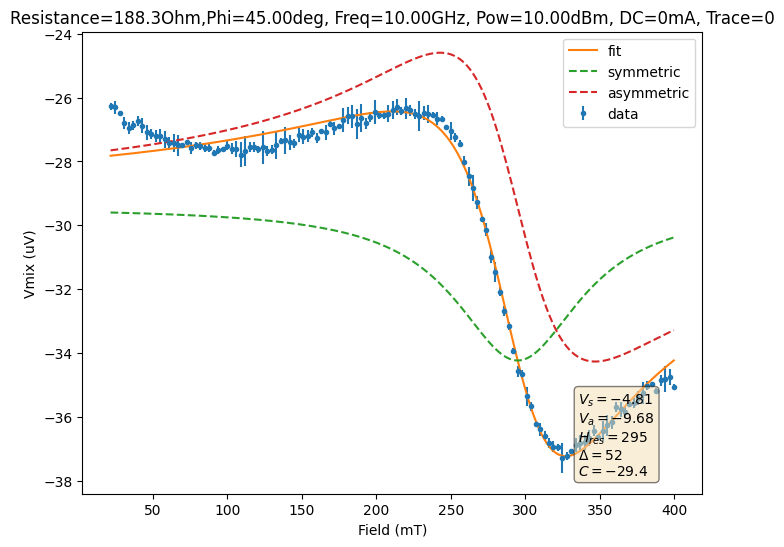

     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.322966 -13.335845 -0.289770  18.852855 -0.000035   
126     22.0    0.56997  15.248325 -15.454383 -0.264012  21.712187 -0.000035   
125     25.0    0.66001  17.675951 -17.617997 -0.309088  24.958537 -0.000035   
124     28.0    0.74003  19.665702 -19.697899 -0.321966  27.836141 -0.000036   
123     31.0    0.83007  22.054692 -21.758483 -0.334845  30.983111 -0.000036   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000003     0.0  18.852855  
126     0.0  0.000003     0.0  21.712187  
125     0.0  0.000003     0.0  24.958537  
124     0.0  0.000003     0.0  27.836141  
123     0.0  0.000003     0.0  30.983111  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.226376 -13.406677 -0.270452  18.834786 -0.000035   
126     22.0    0.56997  15.428626 -15.306278 -0.302648  21.735139 -0.000035   
125     25.0    0.660

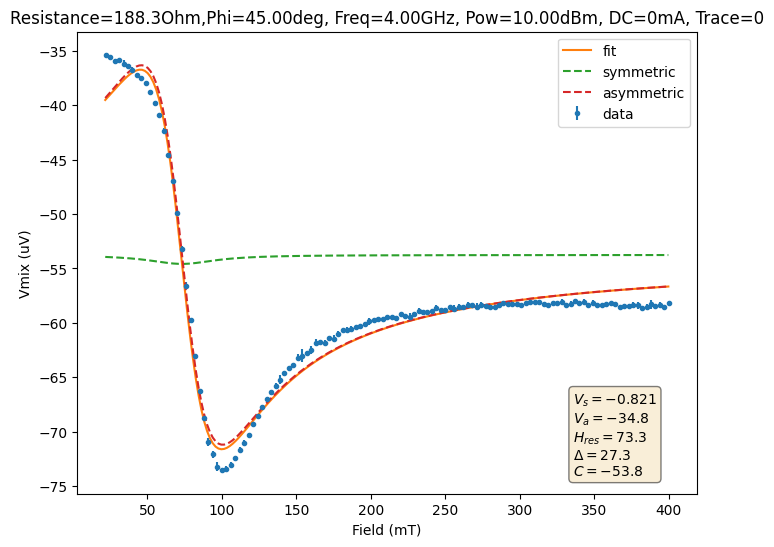

     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.355163 -13.400238 -0.186740  18.919874 -0.000038   
126     22.0    0.56997  15.428626 -15.274082 -0.264012  21.711973 -0.000038   
125     25.0    0.66001  17.804737 -17.675951 -0.225376  25.089812 -0.000039   
124     28.0    0.74003  19.588430 -19.627066 -0.367042  27.731986 -0.000039   
123     31.0    0.83007  22.003178 -21.958102 -0.476510  31.088988 -0.000039   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000003     0.0  18.919874  
126     0.0  0.000003     0.0  21.711973  
125     0.0  0.000003     0.0  25.089812  
124     0.0  0.000003     0.0  27.731986  
123     0.0  0.000003     0.0  31.088988  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.316527 -13.322966 -0.167422  18.837710 -0.000038   
126     22.0    0.56997  15.454383 -15.389990 -0.218937  21.811411 -0.000038   
125     25.0    0.660

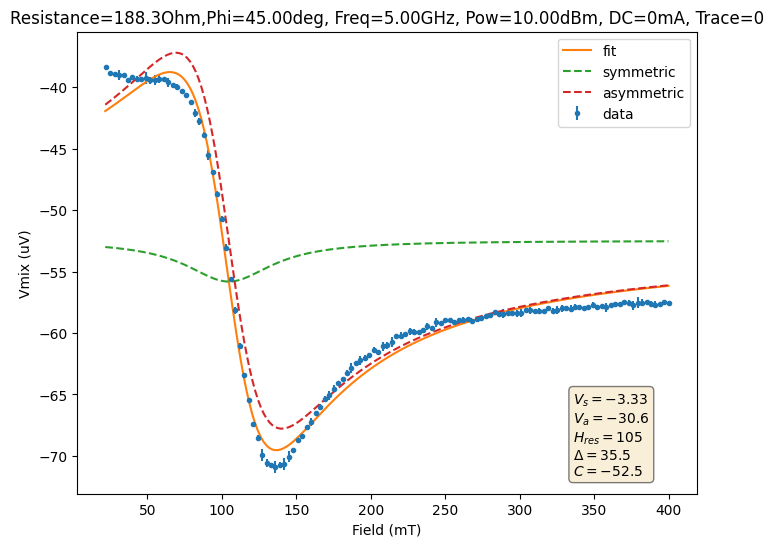

     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.316527 -13.329405 -0.231816  18.842947 -0.000034   
126     22.0    0.56997  15.332036 -15.389990 -0.270452  21.725475 -0.000035   
125     25.0    0.66001  17.663072 -17.598679 -0.347724  24.936289 -0.000035   
124     28.0    0.74003  19.633506 -19.575552 -0.379920  27.727624 -0.000035   
123     31.0    0.83007  21.983860 -21.829316 -0.379920  30.983116 -0.000035   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000003     0.0  18.842947  
126     0.0  0.000003     0.0  21.725475  
125     0.0  0.000003     0.0  24.936289  
124     0.0  0.000003     0.0  27.727624  
123     0.0  0.000003     0.0  30.983116  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.335845 -13.348723 -0.257573  18.870599 -0.000034   
126     22.0    0.56997  15.389990 -15.338475 -0.315527  21.730627 -0.000034   
125     25.0    0.660

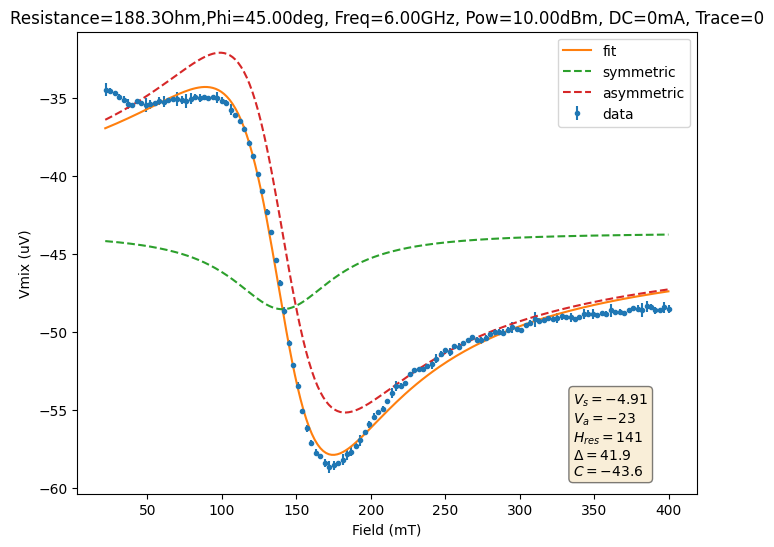

     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.342284 -13.329405 -0.128787  18.860174 -0.000040   
126     22.0    0.56997  15.454383 -15.306278 -0.193180  21.752182 -0.000041   
125     25.0    0.66001  17.727465 -17.617997 -0.347724  24.995554 -0.000041   
124     28.0    0.74003  19.839564 -19.601309 -0.463631  27.893271 -0.000042   
123     31.0    0.83007  22.022496 -21.822877 -0.431435  31.006683 -0.000041   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000003     0.0  18.860174  
126     0.0  0.000003     0.0  21.752182  
125     0.0  0.000003     0.0  24.995554  
124     0.0  0.000003     0.0  27.893271  
123     0.0  0.000003     0.0  31.006683  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.419556 -13.438874 -0.135226  18.992264 -0.000041   
126     22.0    0.56997  15.441504 -15.364232 -0.225376  21.784180 -0.000041   
125     25.0    0.660

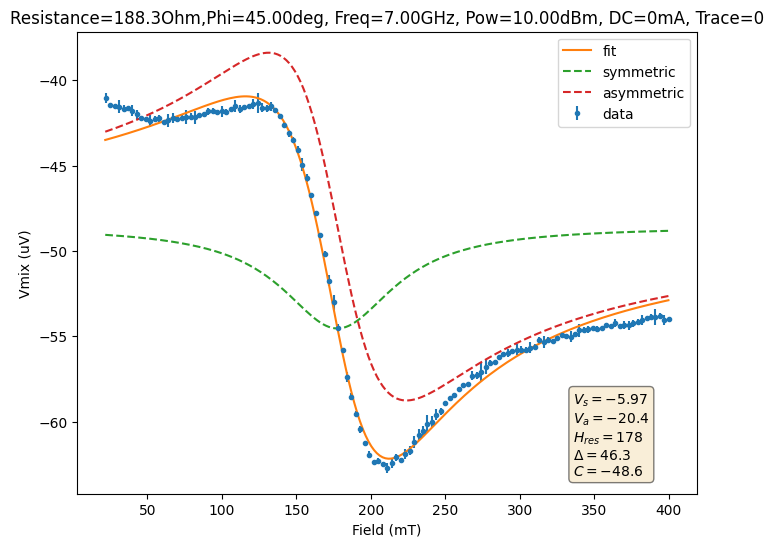

     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.348723 -13.380920 -0.141665  18.901257 -0.000034   
126     22.0    0.56997  15.357793 -15.454383 -0.264012  21.789205 -0.000034   
125     25.0    0.66001  17.675951 -17.540725 -0.270452  24.903602 -0.000034   
124     28.0    0.74003  19.639945 -19.581991 -0.450753  27.737790 -0.000034   
123     31.0    0.83007  22.041814 -21.822877 -0.399238  31.019976 -0.000035   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000002     0.0  18.901257  
126     0.0  0.000003     0.0  21.789205  
125     0.0  0.000003     0.0  24.903602  
124     0.0  0.000003     0.0  27.737790  
123     0.0  0.000003     0.0  31.019976  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.271451 -13.374481 -0.251134  18.843334 -0.000034   
126     22.0    0.56997  15.325596 -15.312718 -0.354163  21.667456 -0.000034   
125     25.0    0.660

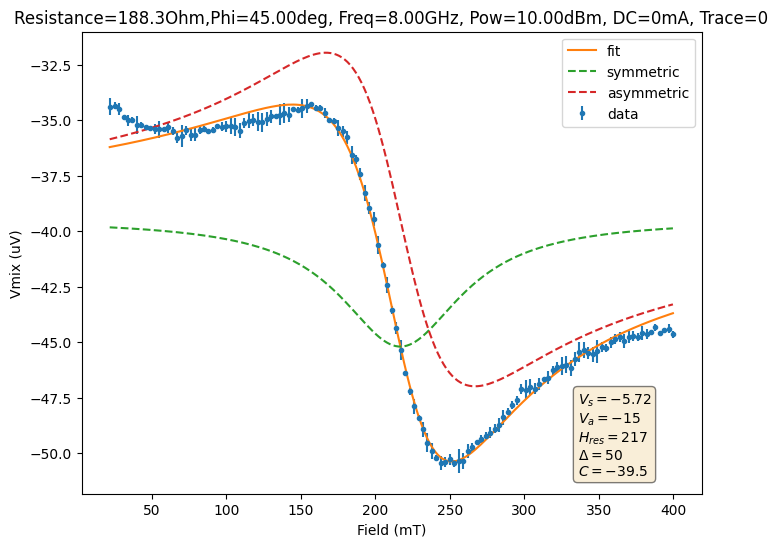

     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.316527 -13.406677 -0.148105  18.896847 -0.000027   
126     22.0    0.56997  15.325596 -15.280521 -0.173862  21.642515 -0.000027   
125     25.0    0.66001  17.688829 -17.682390 -0.334845  25.013471 -0.000027   
124     28.0    0.74003  19.723656 -19.556234 -0.315527  27.777121 -0.000027   
123     31.0    0.83007  21.951663 -21.797119 -0.444314  30.938444 -0.000027   

     Vx_err        Vy  Vy_err   H_signed  
127     0.0  0.000002     0.0  18.896847  
126     0.0  0.000002     0.0  21.642515  
125     0.0  0.000002     0.0  25.013471  
124     0.0  0.000002     0.0  27.777121  
123     0.0  0.000002     0.0  30.938444  
     H_given  I_Set(mA)         Hx         Hy        Hz      H_mag        Vx  \
127     19.0    0.48996  13.361602 -13.380920 -0.199619  18.910877 -0.000027   
126     22.0    0.56997  15.357793 -15.357793 -0.276891  21.720964 -0.000027   
125     25.0    0.660

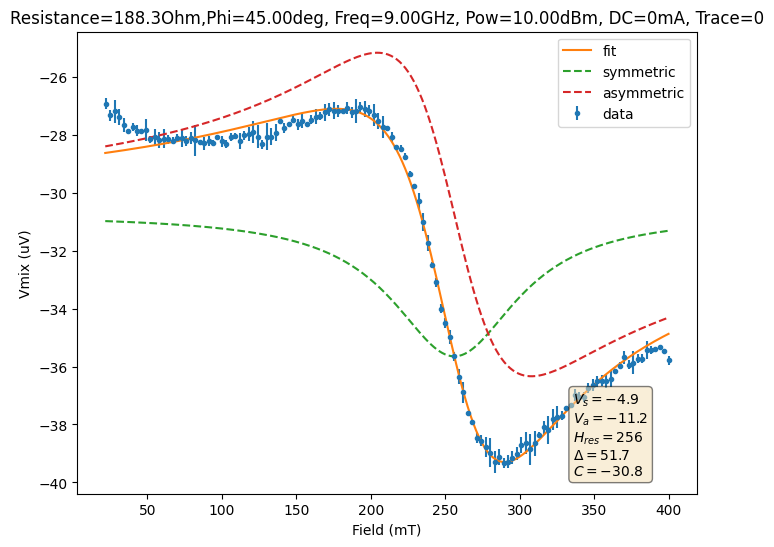

In [ ]:
# 23-11-2025 10:35
# ST-FMR analysis

# Improvements list:
# -

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re
import os 
import glob
import sys
from pathlib import Path
import itertools
from uncertainties import ufloat


# STFMR Class 1.1
class STFMR:
    def __init__(self, folder=None, filename=None, thicknessFolder=None, voltage_unit='uV', d_FM=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos'):
        """
        Parameters
        ----------
        filename : str
            Path to data file
        """
        if folder is not None:
            self.folder = folder
        if filename is not None:
            self.filename = filename
        if thicknessFolder is not None:
            self.thicknessFolder = thicknessFolder

        self.pattern = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Trace_(?P<trace>\d+)"
        )

        self.patternDC = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Curr_(?P<dc>[+-]?\d+(?:\.\d+)?)mA_"
            r"Trace_(?P<trace>\d+)"
        )

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.voltage_unit = voltage_unit  
        self.d_FM = d_FM
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Length = Length
        self.used_fields=used_fields

        
    # -----------Data loading and preprocessing-----------
    # IMPORTANT COMMENTS: 
    # The selection of analysed fields is being done in self.read_file()
    # The scaling of the voltage only happens in function V_mix, which is also used to plot

    def get_key(self, filepath):
        """Create a key for a file, which describes the most important parameters of the datafile. Distinghuishes between measurement with or without DC."""
        filename = Path(filepath).name
        if 'Curr' in filename:
            match = self.patternDC.search(filename)
            if match:
                phi, freq, pow_, dc, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
        else:
            dc = 0
            match = self.pattern.search(filename)
            if match:
                phi, freq, pow_, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
    
    def group_files(self):
        """Groups files based on their key. Will be performed for the inputted folder in the class. """
        grouped_files = {}
        for filename in os.listdir(self.folder):
            if filename.lower().endswith(".txt"): 
                (phi, freq, pow_, dc, trace) = self.get_key(filename)
                key = (phi, freq, pow_, dc)
                grouped_files.setdefault(key, []).append(filename)
            # print(grouped_files)
        return grouped_files

    def parse_resistance(self, first_line):
        # Look for "R = ... Ohm" with flexible spaces
        match = re.search(r"R\s*=\s*([0-9.]+)\s*Ohm", first_line)
        if match:
            return float(match.group(1))
        else:
            raise ValueError(f"Could not parse resistance from line: '{first_line}'")
        
    def read_file(self, filepath):
         # Read the resistance value from the first line
        with open(filepath, 'r') as f:
            first_line = f.readline().strip()

        # Extract resistance value (assuming format 'R =93.6Ohm')
        R = self.parse_resistance(first_line)

        # Read the actual data starting from the second line
        df = pd.read_csv(filepath, sep='\t', skiprows=1, header=0)
        df = df.sort_values(by='H_given')

        # Make a copy of the magnitude column
        df["H_signed"] = df["H_mag"]
        H = df["H_given"].to_numpy()
        H_signed = H.copy()
        idx_half = len(H) // 2
        df = df.fillna(0)

        if min(H) >= 0:
            return R, df
        elif abs(H[0]) == abs(H[-1]):
            # print("Detected symmetric sweep: multiplying first half with -1.")
            df.loc[:idx_half, "H_signed"] *= -1
            if self.used_fields == 'Neg':
                # Keep only positive fields
                df = df.iloc[:idx_half+1].reset_index(drop=True)
            elif self.used_fields == 'Pos':
                # Keep only negative fields
                df = df.iloc[idx_half:].reset_index(drop=True)
            elif self.used_fields == 'Both':
                df.loc[:idx_half, "H_signed"] *= -1
            return R, df
    
    
    # -----------Analyzing and plotting data----------- 
    def fit_Vmix(self, filepath, plot=True, textbox=True, cutoff=1):
        R, df = self.read_file(filepath)
        keys = self.get_key(filepath)

        # Perform fit using uV
        if self.voltage_unit == 'uV':
            df['Vx'] *= 1e6  # Convert Vx to microvolts
            df['Vy'] *= 1e6  # Convert Vy to microvolts
            df['Vx_err'] *= 1e6
            df['Vy_err'] *= 1e6
        elif self.voltage_unit == 'mV':
            df['Vx'] *= 1e3  # Convert Vx to millivolts
            df['Vy'] *= 1e3  # Convert Vy to millivolts
            df['Vx_err'] *= 1e3
            df['Vy_err'] *= 1e3

        if self.used_fields == 'Pos':
            H_min, H_max = 20, np.inf
        elif self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0

        df_filtered = df[(df["H_signed"] >= H_min) & (df["H_signed"] <= H_max)] # creating a proper field range

        fit_params, cov = self.fit_stfmr(df_filtered["H_signed"][cutoff:-cutoff], df_filtered["Vx"][cutoff:-cutoff]) # cutoff to remove outlier points

        if plot == True:
            self.plot_Vmix(df_filtered, R, fit_params, keys, textbox=textbox)
        return fit_params, cov

    def plot_Vmix(self, df, R, fit_params=None, keys=None, textbox=True):
        plt.figure(figsize=(8,6))
        plt.errorbar(df["H_given"], df["Vx"], df["Vx_err"], fmt='.', label="data")

        H = np.linspace(min(df["H_signed"]), max(df["H_signed"]), 200)
        plt.plot(H, STFMR.stfmr_model(H, **fit_params), '-', label="fit")
        if fit_params is not None:      
            Vs, Va, Hres, Delta, C = fit_params["Vs"], fit_params["Va"], fit_params["Hres"], fit_params["Delta"], fit_params["C"]
            plt.plot(H, STFMR.stfmr_symmetric(H, Vs, Hres, Delta, C), '--', label="symmetric")
            plt.plot(H, STFMR.stfmr_asymmetric(H, Va, Hres, Delta, C), '--', label="asymmetric")
        
        if keys is not None:
            plt.title(f"Resistance={R}Ohm,Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm, DC={keys[3]}mA, Trace={keys[4]}")

        if textbox and fit_params is not None:
            # --- Add textbox with fit parameters ---
            position = 0.8 if self.used_fields == 'Pos' else 0.05
            textstr = '\n'.join((
                r"$V_s=%.3g$" % Vs,
                r"$V_a=%.3g$" % Va,
                r"$H_{res}=%.3g$" % Hres,
                r"$\Delta=%.3g$" % Delta,
                r"$C=%.3g$" % C
            ))
            # Place text box in lower right corner of the plot
            plt.gca().text(
                position, 0.22, textstr,
                transform=plt.gca().transAxes,
                fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            )

        plt.xlabel("Field (mT)")
        plt.ylabel(f"Vmix ({self.voltage_unit})")       
        plt.legend()
        plt.show()

    def plot_general(self, df, col_x, col_y):
        """General plotting function to plot anything"""
        if col_x not in df.columns or col_y not in df.columns:
            raise ValueError(f"Columns '{col_x}' or '{col_y}' not found in DataFrame.")
    
        x = df[col_x]
        y = df[col_y]
        
        # Plot
        plt.figure(figsize=(8, 5))
        plt.plot(x, y)
        plt.xlabel(col_x)
        plt.ylabel(col_y)
        plt.title(f"Plot of {col_y} vs {col_x}")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_traces(self):
        """Plotting different traces to check the differences between measurements"""
        if self.folder is not None:
            grouped_files = self.group_files()

            fig, ax = plt.subplots(len(grouped_files), 1, figsize=(8, 11*len(grouped_files)))
            for i, (key, files) in enumerate(grouped_files.items()):
                for f in files:
                    path = os.path.join(self.folder, f)
                    if 'Curr' in f:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nDC={dc}\nTrace={trace}")
                    else:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nTrace={trace}")
                    R, df = self.read_file(path)
                    # PLOT FUNCTION
                    ax[i].plot(df["H_signed"], df["Vx"], '.', label=f"Trace {trace}")
                    ax[i].set_xlabel("Field (mT)")
                    ax[i].set_ylabel(f"$Vmix$ ({self.voltage_unit})")
                    ax[i].legend(fontsize='small')
                    # PLOT FUNCTION
        elif self.filename is not None:
            pass
        else:
            sys.exit("Folder or filename not set. Please initialize STFMR with a folder path to datafiles.")

    def plot_quick_scans(self):
        """Plotting all traces of the folder in one figure"""
        plt.figure(figsize=(12,8))

        for file in os.listdir(self.folder):
            if not os.path.isfile(self.folder) and not file.lower().endswith(".txt"):
                    print(f"⚠️ Skipping {file}: no proper file.")
                    continue
            path = os.path.join(self.folder, file)
            key = self.get_key(file)
            R, df = self.read_file(path)
            plt.errorbar(df["H_given"], df["Vx"], df['Vx_err'], fmt='.', label=f"Frequency = {key[1]} GHz")
        plt.title(f"Scan of all frequencies, sample: {Path(self.folder).parts[0]}, resistance: {R:.2f} Ohm")
        plt.legend()
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")

    def plot_averages(self):
        """Plotting the averages of all traces in one figure"""
        if self.used_fields== 'Pos':
            output_folder = os.path.join(self.folder, "Averaged_Traces_posB")
        elif self.used_fields== 'Neg':
            output_folder = os.path.join(self.folder, "Averaged_Traces_negB")
        
        if not os.path.exists(output_folder):
            self.average_traces()

        plt.figure(figsize=(8,6))
        for file in os.listdir(output_folder):
            if not os.path.isfile(file) and not file.lower().endswith(".txt"):
                    print(f"⚠️ Skipping {file}: no proper file.")
                    continue
            path = os.path.join(output_folder, file)
            key = self.get_key(file)
            R, df = self.read_file(path)
            df['Vx'] *= 1e6
            df['Vx_err'] *= 1e6
            plt.errorbar(df["H_given"], df["Vx"], df['Vx_err'], fmt='.', label=f"Frequency = {key[1]} GHz")
        plt.title(f"Scan of all frequencies, sample: {Path(self.folder).parts[0]}, resistance: {R:.2f} Ohm")
        plt.legend()
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")

    def average_traces(self, plot=False):
        """Function that takes measurements from different traces. Subsequently averages all datapoints and performs a fit for these datapoints. """
        try:
            if self.used_fields== 'Pos':
                output_folder = os.path.join(self.folder, "Averaged_Traces_posB")
            elif self.used_fields== 'Neg':
                output_folder = os.path.join(self.folder, "Averaged_Traces_negB")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles with multiple traces.")

        # Create folder if not exists, and delte all files in them
        os.mkdir(output_folder) if not os.path.exists(output_folder) else None
        [os.remove(f.path) for f in os.scandir(output_folder) if f.is_file()]

        # Collect files by (Phi, Freq, Pow, DC)
        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            try:
                phi, freq, pow_, dc = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Curr_{dc}mA_Trace_0.txt"
            except:
                raise ValueError(f"Something went wrong, might be wrong key length: {len(key)}")

            dfs = []
            for f in files:
                path = os.path.join(self.folder, f)
                R, df = self.read_file(path)
                dfs.append(df)
                print(df.head())

            # Check if all dfs have same length.
            lengths = [len(df) for df in dfs]
            if len(set(lengths)) != 1:
                raise ValueError(
                    "Not all dataframes have the same length.\n"
                    f"Lengths found: {lengths}"
                )
            
            # Taking the mean of the dfs and calculating the propagated error
            all_df = pd.concat(dfs)
            avg_df = all_df.groupby(level=0).mean()
            std_series = all_df.groupby(level=0)['Vx'].std()
            err_series = avg_df['Vx_err']
            avg_df['Vx_err'] = std_series.combine(err_series, lambda s, e: self.uncorrelated_errors(s, e))
            std_seriesy = all_df.groupby(level=0)['Vy'].std()
            err_seriesy = avg_df['Vy_err']
            avg_df['Vy_err'] = std_seriesy.combine(err_seriesy, lambda s, e: self.uncorrelated_errors(s, e))

            # Save averaged file
            outpath = os.path.join(output_folder, outname)
            with open(outpath, "w") as f:
                f.write(f"R ={R}Ohm\n")  # Write resistance
            avg_df.to_csv(outpath, sep="\t", index=False, mode="a")
            self.fit_Vmix(outpath, plot=plot)
        return 

    def average_fitparams(self, plot=False):
        """"Creates a .csv file with averages of the fitting variables from different measurements with different trace number.  """
        try:
            if self.used_fields == 'Pos':
                resultpath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg': 
                resultpath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file, in case needs to be updated

        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            temp = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}
            temp_cov = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}

            for f in files:
                fitparams_f, cov = self.fit_Vmix(os.path.join(self.folder, f), plot=plot)
                for i, name in enumerate(["Vs","Va","Hres","Delta","C"]):
                    temp[name].append(fitparams_f[name])
                    temp_cov[name].append(np.sqrt(cov[i,i]))  # per-fit error

            fitparams_avg = {key: np.mean(value) for key, value in temp.items()}

            fitparams_std = {}
            for name in temp.keys():
                between_std = np.std(temp[name])
                within_std = np.mean(temp_cov[name])
                fitparams_std[name] = self.uncorrelated_errors(between_std, within_std) 
            else:
                fitparams_std = {k: np.std(v) for k, v in temp.items()}

            self.append_fit_results(f, fitparams_avg, std_dict=fitparams_std)
        return 
    
    def append_fit_results(self, filepath, fit_params, std_dict=None):
        filepath = Path(filepath)  # ensure Path
        has_curr = "Curr" in filepath.name

        # Extract keys
        phi, freq, pow_, dc, trace = self.get_key(filepath)
        dc = None  # keep dc consistent

        # Decide filenames
        if self.used_fields == 'Pos':
            results_file = os.path.join(
                self.folder,
                "fit_results_average_posB.csv" if std_dict is not None else "fit_results_posB.csv"
            )
        elif self.used_fields == 'Neg': 
            results_file = os.path.join(
                self.folder,
                "fit_results_average_negB.csv" if std_dict is not None else "fit_results_negB.csv"
            )

        # Ensure file exists with header
        if not os.path.exists(results_file):
            with open(results_file, "w") as f:
                header = (
                        "Filename,phi,freq,pow_,dc,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                    )
                f.write(header)
        # Append row
        with open(results_file, "a") as f:
            trace = "avg"
            row = (
                f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                f"{fit_params['C']},{std_dict['C']}\n"
                if has_curr else
                f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                f"{fit_params['C']},{std_dict['C']}\n"
            )
            f.write(row)
    
    def angular_scan(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
       
        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

        df = pd.read_csv(resultspath)
        self.df = df.sort_values(by="phi")  # sort by angle

        # In case you want to remove outliers
        self.df1 = self.df[
            ((self.df["Vs"] > 0) & (self.df["phi"].between(-180, 0))) |
            ((self.df["Vs"] < 0) & (self.df["phi"].between(0, 180)))
        ]
        self.df2 = self.df[(self.df["Vs"].between(-0.5e3, 0.5e3))]

        f_Vs = lambda alpha, Vs_x, Vs_y, Vs_z: (
            Vs_x * np.sin(2*alpha) * np.sin(alpha) +
            Vs_y * np.sin(2*alpha) * np.cos(alpha) +
            Vs_z * np.sin(2*alpha) #+
            # V_SP * np.sin(alpha) 
        )

        f_Va = lambda alpha, Va_x, Va_y, Va_z: (
            Va_x * np.sin(2*alpha) * np.cos(alpha) +
            Va_y * np.sin(2*alpha) * np.sin(alpha) +
            Va_z * np.sin(2*alpha) 
        )

        # convert to radians for fitting
        phi_deg = self.df['phi'].to_numpy()
        phi_deg1 = self.df1['phi'].to_numpy()

        phi_rad = np.deg2rad(phi_deg)        # --- Plot Vs vs phi ---
        phi_rad1 = np.deg2rad(phi_deg1)        # --- Plot Vs vs phi ---

        phi_deg_plot = np.linspace(phi_deg.min(), phi_deg.max(), 400)
        phi_plot_rad = np.deg2rad(phi_deg_plot)

        params_Vs, cov_Vs = curve_fit(f_Vs, phi_rad, self.df['Vs'])
        params_Va, cov_Va = curve_fit(f_Va, phi_rad, self.df['Va'])

        # axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[0].errorbar(self.df["phi"], self.df["Vs"], yerr=self.df['Vsstd'], xerr=None, fmt="o",label="Vs")
        # axes[0].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")

        axes[0].plot(phi_deg_plot, f_Vs(phi_plot_rad, *params_Vs), label='Fit Vs', color='cyan')

        Vs_x, Vs_y, Vs_z = params_Vs
        axes[0].plot(phi_deg_plot, Vs_y * np.sin(2*phi_plot_rad) * np.cos(phi_plot_rad), label=f"Vs_y*sin(2φ)*cos(φ) [{Vs_y:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, Vs_x * np.sin(2*phi_plot_rad) * np.sin(phi_plot_rad), label=f"Vs_x*sin(2φ)*sin(φ) [{Vs_x:.3g}]", linestyle='--')
        axes[0].plot(phi_deg_plot, Vs_z * np.sin(2*phi_plot_rad), label=f"Vs_z*sin(2φ) [{Vs_z:.3g}]", linestyle='--')

        axes[0].set_xlabel("phi (deg)")
        axes[0].set_ylabel(f"V ({self.voltage_unit})")
        axes[0].set_title("Va and Vs with outliers")
        axes[0].grid(True)
        axes[0].legend()

        # axes[1].errorbar(self.df2["phi"], self.df2["Vs"], yerr=self.df2['Vsstd'], xerr=None, fmt="o",label="Vs")
        axes[1].errorbar(self.df["phi"], self.df["Va"], yerr=self.df['Vastd'], xerr=None, fmt="s", color="red", label="Va")
        axes[1].plot(phi_deg_plot, f_Va(phi_plot_rad, *params_Va), label='Fit Va', color='orange')
        Va_x, Va_y, Va_z = params_Va
        axes[1].plot(phi_deg_plot, Va_y * np.sin(2*phi_plot_rad) * np.cos(phi_plot_rad), label=f"Va_y*sin(2φ)*cos(φ) [{Va_y:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, Va_z * np.sin(2*phi_plot_rad), label=f"Va_z*sin(2φ) [{Va_z:.3g}]", linestyle='--')
        axes[1].plot(phi_deg_plot, Va_x * np.sin(2*phi_plot_rad) * np.sin(phi_plot_rad), label=f"Va_x*sin(2φ)*sin(φ) [{Va_x:.3g}]", linestyle='--')
        axes[1].set_xlabel("phi (deg)")
        axes[1].set_ylabel(f"Va ({self.voltage_unit})")
        axes[1].set_title("Va and Vs versus phi")    
        axes[1].grid(True)
        axes[1].legend()

        # --- Plot Va vs phi ---
        axes[2].plot(self.df["phi"], self.df["C"], "s-", color="orange", label="Vbias")
        axes[2].set_xlabel("phi (deg)")
        axes[2].set_ylabel(f"Vbias ({self.voltage_unit})")
        axes[2].set_title("Vbias")
        axes[2].grid(True)
        axes[2].legend()

        plt.suptitle(f"Fit Results of angular scan, frequency={df['freq'].iloc[1]} GHz and {self.used_fields} field sweep", fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_Kittel(self, plot=False):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        
        print(df_sorted.head())
        params, pcov = curve_fit(self.Kittel_formula, abs(df_sorted['Hres']*1e-3), df_sorted['freq'], p0=[1e-3])
        # params, pcov, kittel_params = self.fit_kittel(abs(df_sorted['Hres']*1e-3), df_sorted['freq']*1e9)
        print(df_sorted[['Hres', 'freq']])
        print("Fitted Kittel parameters:")
        print(f"mu0M_eff = {params[0]*1e3:.3g} mT ± {np.sqrt(pcov[0,0])*1e3:.3g} mT")

        if self.used_fields == 'Pos':
            H = np.linspace(0, max(df_sorted['Hres']) * 1.1, 200)
        elif self.used_fields == 'Neg':
            H = np.linspace(1.1 * min(df_sorted['Hres']), 0, 200)
        hmin = np.min(H)
        hmax = np.max(H)

        # Plot experimental data
        if plot:
            fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
            axes.errorbar(df_sorted['Hres'], df_sorted['freq'], 0, df_sorted['Hresstd'], "o-", label="Data points")

            # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
            axes.plot(
                H,
                self.Kittel_formula(abs(H) * 1e-3, *params),  # output in GHz
                '-',
                label=f"Kittel fit: $\\frac{{\\gamma}}{{2 \\pi}} \\sqrt{{|H_{{res}}|(|H_{{res}}| + H_{{eff}})}}$ \n with $\\mu_0 H{{eff}}$ = {params[0]*1e3:.3g} mT"
            )
            print(H, self.Kittel_formula(abs(H) * 1e-3, *params))
            axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
            axes.set_ylabel("Frequency (GHz)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_ylim(bottom=0, top = 20)
            axes.set_xlim(left=hmin, right=hmax)
            plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweep", fontsize=14)
            plt.tight_layout()
            plt.show()

            fig, ax = plt.subplots(3, 1, figsize=(14, 14))
            ax[0].errorbar(df_sorted['freq'], df_sorted['Va'], yerr=df_sorted['Vastd'], xerr=0, label="Data points Va")
            ax[0].legend()
            ax[1].errorbar(df_sorted['freq'], df_sorted['Vs'], yerr=df_sorted['Vsstd'], xerr=0, label="Data points Vs")
            ax[1].legend()
            ax[2].plot(df_sorted['freq'], df_sorted['Vs']/df_sorted['Va'], label="Vs/Va")
            ratio_mean = np.mean(df_sorted['Vs'] / df_sorted['Va'])
            ratio_std = np.std(df_sorted['Vs'] / df_sorted['Va'])
            ax[2].axhline(ratio_mean, linestyle='--', label="Mean(Vs/Va)")
            ax[2].fill_between(
                df_sorted['freq'],
                ratio_mean - ratio_std,
                ratio_mean + ratio_std,
                alpha=0.2,
                label="Std(Va/Vs)"
            )
            ax[2].legend()

        self.Heff_T, self.Heff_T_cov = params[0], np.sqrt(pcov[0])
        return df_sorted
    
    def fit_kittel(self, mu0H_FMR, frequencies):
        initial_guesses = [1e-5]  # Initial guesses for gamma, mu0M_eff
        popt, pcov = curve_fit(self.kittel_function, mu0H_FMR, frequencies, p0=initial_guesses)
        
        # Extract uncertainties
        perr = np.sqrt(np.diag(pcov))
        
        # Save the parameters
        kittel_params = {
            'mu0M_eff': ufloat(popt[0], perr[0]),
        }
        
        return popt, pcov, kittel_params

    # Step 1: Define the Kittel function
    def kittel_function(self, mu0H_FMR, mu0M_eff):
        #!!!! a = gamma/2pi (GHz/mT); It is material dependent, change accordingly after checking literature!!!!
        a = 0.0294  #GHz/mT
        return  a * np.sqrt(mu0H_FMR * (mu0H_FMR + mu0M_eff))  
    

    def plot_linewidth(self, plot=False):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        
        errs = df_sorted['Deltastd'].fillna(df_sorted['Deltastd'].max() * 2)  # remove NaNs, large uncertainty → low weight

        params, pcov = curve_fit(self.linewidth_formula, df_sorted["freq"]*1e9, df_sorted['Delta']*1e-3, sigma=errs,p0=[1/self.mu_0, 1])
        errs = np.sqrt(np.diag(pcov))
        # print(params)
        freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)

        # --- Plot H vs freq ---
        if plot == True:
            fig, axes = plt.subplots(1, 1, figsize=(10, 8), sharex=True)
            axes.errorbar(df_sorted["freq"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Sample data")
            axes.plot(freq, self.linewidth_formula(freq*1e9, *params)*1e3, '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\\gamma}}$ \n with inhomogeneous broadening $\\mu_0 \\Delta H_0$ = {params[0]*self.mu_0*1e3:.3g} mT \n and damping factor $\\alpha = $ {params[1]:.3g}") #
            axes.set_xlabel("Frequency (GHz)")
            axes.set_ylabel(f"$\\mu \\Delta H$ (mT)")
            axes.grid(True)
            axes.legend(fontsize=14)
            axes.set_xlim(right=18)
            # axes.set_ylim(bottom=0, top=8)
            plt.suptitle("Fit Results: $\\mu \\Delta H_0$ vs frequency", fontsize=14)
            plt.tight_layout()
            plt.show()

        self.alpha, self.DeltaH0 = params[1], params[0]
        self.alpha_cov, self.DeltaH0_cov = errs[1], errs[0]
        return df_sorted

    def plot_power(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        fig, axes = plt.subplots(2, 1, figsize=(10, 14), sharex=True)
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="pow_")  # sort by angle

        # params, pocv = curve_fit(self...., df_sorted["pow_"], df_sorted['Vs'], p0=[1/self.mu_0, 1])

        # if self.used_fields == 'Pos':
        #     freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)
        # elif self.used_fields == 'Neg':
        #     freq = np.linspace(1.2*min(df_sorted['freq']), 0, 200)

        # --- Plot H vs freq ---
        axes[0].errorbar(df_sorted["pow_"], df_sorted["Vs"], df_sorted["Vsstd"], 0, "o-", label="Vs")
        axes[0].errorbar(df_sorted["pow_"], df_sorted["Va"], df_sorted["Vastd"], 0, "o-", label="Va")
        axes[1].errorbar(df_sorted["pow_"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="Delta")
        axes[1].errorbar(df_sorted["pow_"], df_sorted["Hres"], df_sorted["Hresstd"], 0, "o-", label="Hres")
        axes[0].errorbar(df_sorted["pow_"], df_sorted["C"], df_sorted["Cstd"], 0, "o-", label="C")

        # axes.plot(freq, self.linewidth_formula(freq*1e9, *params), '-', label=f"Linewidth fit: $\\mu_0 \\Delta H_0 + \\frac{{2 \\pi \\alpha f}}{{\gamma}}$, with $\mu_0 \\Delta H_0$ = {params[0]*self.mu_0:.3g} mT and $\\alpha = $ {params[1]:.3g}")

        axes[0].set_xlabel("Power (db)")
        axes[0].set_ylabel(f"Voltage ($\\mu$V)")
        axes[0].grid(True)
        axes[0].legend(fontsize=14)
        # axes.set_xlim(right=15)
        # axes.set_ylim(bottom=0)
        plt.suptitle("Power Scan", fontsize=14)
        plt.tight_layout()
        plt.show()
        self.plot_general(df_sorted, 'pow_', 'Vs')
        self.plot_general(df_sorted, 'pow_', 'Va')
        self.plot_general(df_sorted, 'pow_', 'C')
        return

    def DCScan(self):
        try:
            resultspath_pos = os.path.join(self.folder, "fit_results_average_posB.csv")
            resultspath_neg = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath_pos):
            self.average_fitparams()
        if not os.path.exists(resultspath_neg):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 24), sharex=True)
        df_pos = pd.read_csv(resultspath_pos)
        df_neg = pd.read_csv(resultspath_neg)
        sample = Path(resultspath_neg).parent.parent.name   # one level higher

        df_pos = df_pos.sort_values(by="dc")  # sort by dc current
        df_neg = df_neg.sort_values(by="dc")  # sort by dc current

        # Define a common errorbar style for consistency
        err_style = dict(
            fmt="+-",             # circle markers, no connecting line
            capsize=4,           # small caps on error bars
            elinewidth=1,        # thin error bar lines
            linewidth=1,
            markersize=7,        # marker size
            mec="black",         # marker edge color
        )

        if sample == 'DK158':
            cutoff = 0
        else:
            cutoff = 0

        params_neg, pcov_neg = curve_fit(self.linewidth_DC_formula, df_neg['dc'].iloc[cutoff:], df_neg['Delta'].iloc[cutoff:], p0=[5, 1], sigma=df_pos['Deltastd'].iloc[cutoff:])
        params_pos, pcov_pos = curve_fit(self.linewidth_DC_formula, df_pos['dc'].iloc[:], df_pos['Delta'].iloc[:], p0=[5, 1], sigma=df_pos['Deltastd'])
 

        I_DC = np.linspace(min(df_neg['dc'])*1.2, max(df_neg['dc'])*1.2) 
        # --- Plot Delta vs dc ---
        axes[0].errorbar(
            df_neg["dc"].iloc[cutoff:],
            df_neg["Delta"].iloc[cutoff:],
            df_neg["Deltastd"].iloc[cutoff:],
            label="Delta negative field",
            color="tab:red",
            **err_style
        )
        axes[0].errorbar(
            df_pos["dc"].iloc[:],
            df_pos["Delta"].iloc[:],
            df_pos["Deltastd"].iloc[:],
            label="Delta positive field",
            color="tab:blue",
            **err_style
        )
        axes[0].plot(I_DC, self.linewidth_DC_formula(I_DC, *params_neg), label='Fit for negative field', color= 'r') # : $\mu_0 \Delta H_0 + I_{DC} \kappa$
        axes[0].plot(I_DC, self.linewidth_DC_formula(I_DC, *params_pos), label='Fit for positive field', color= 'b') #: $\mu_0 \Delta H_0 + I_{DC} \kappa$

        axes[0].set_xlabel("dc (mA)")
        axes[0].set_ylim(4, 8)
        axes[0].set_ylabel("Delta (mT)")
        axes[0].set_title("Delta vs dc")
        axes[0].grid(True, linestyle="--", alpha=0.6)
        axes[0].legend()

        # --- Plot Vs vs dc ---
        axes[1].errorbar(
            df_pos["dc"].iloc[1:],
            df_pos["Vs"].iloc[1:],
            df_pos["Vsstd"].iloc[1:],
            label="Vs positive field",
            color="tab:blue",
            **err_style
        )
        axes[1].errorbar(
            df_neg["dc"].iloc[1:],
            df_neg["Vs"].iloc[1:],
            df_neg["Vsstd"].iloc[1:],
            label="Vs negative field",
            color="tab:red",
            **err_style
        )
        axes[1].set_xlabel("dc (mA)")
        axes[1].set_ylabel(f"Vs ({self.voltage_unit})")
        axes[1].set_title("Vs vs dc")
        axes[1].grid(True, linestyle="--", alpha=0.6)
        axes[1].legend()

        # --- Plot Va vs dc ---
        axes[2].errorbar(
            df_pos["dc"].iloc[1:],
            df_pos["Va"].iloc[1:],
            df_pos["Vastd"].iloc[1:],
            label="Va positive field",
            color="tab:blue",
            **err_style
        )
        axes[2].errorbar(
            df_neg["dc"].iloc[1:],
            df_neg["Va"].iloc[1:],
            df_neg["Vastd"].iloc[1:],
            label="Va negative field",
            color="tab:red",
            **err_style
        )
        axes[2].set_xlabel("dc (mA)")
        axes[2].set_ylabel(f"Va ({self.voltage_unit})")
        axes[2].set_title("Va vs dc")
        axes[2].grid(True, linestyle="--", alpha=0.6)
        axes[2].legend()

        fig.suptitle(f"{sample}", fontsize=14, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    def calculate_xiFMR(self, plot=False):
        # Check for required data and extract it
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq").reset_index(drop=True)  # sort by frequency

        if not hasattr(self, "Heff_T") or self.Heff_T is None:
            self.plot_Kittel(plot=False) 

        if not hasattr(self, "Alpha") or self.alpha is None:
            self.plot_linewidth(plot=False)

        allowed_freqs = [7, 8, 9, 10, 11]  # select frequencies for xi, lower frequencies can give larger deviations
        df_to_save = df_sorted[df_sorted['freq'].isin(allowed_freqs)].copy()

        # 5) Compute xi_FMR for each row and add as column
        C = (self.e / self.hbar) * (self.mu_0 * self.Ms * self.d_FM * self.d_NM)    # constant for each xi_FMR

        xi_list = []
        xi_std_list = []
        # Error propagation made by ChatGPT
        for idx, row in df_to_save.iterrows():
            Vs = row['Vs']
            Va = row['Va']
            Hres = row['Hres'] * 1e-3       # in T

            Vs_std = row.get('Vsstd', 0.0)
            Va_std = row.get('Vastd', 0.0)
            Hres_std = row.get('Hresstd', 0.0) * 1e-3

            # compute xi
            xi = self.FMR_efficiency(Vs, Va, self.Ms, self.d_FM, self.d_NM, Hres, self.Heff_T)
            # partial derivatives
            dxi_dVs = xi / Vs
            dxi_dVa = -xi / Va
            dxi_dHres = C * (Vs / Va) * 0.5 * (1 + (4*np.pi*self.Heff_T)/Hres)**(-0.5) * (-4*np.pi*self.Heff_T / Hres**2)
            dxi_dHeff = C * (Vs / Va) * 0.5 * (1 + (4*np.pi*self.Heff_T)/Hres)**(-0.5) * (4*np.pi / Hres)

            # propagate uncertainties (assuming independence)
            xi_var = (
                (dxi_dVs * Vs_std)**2 +
                (dxi_dVa * Va_std)**2 +
                (dxi_dHres * Hres_std)**2 +
                (dxi_dHeff * self.Heff_T_cov)**2
            )

            xi_std = np.sqrt(xi_var)
            xi_list.append(float(xi))
            xi_std_list.append(float(xi_std))

        df_to_save['xi_FMR'] = xi_list
        df_to_save['xi_FMR_std'] = xi_std_list
        
        self.xi_fmr = np.mean(xi_list)
        self.xi_std = self.uncorrelated_errors(np.mean(xi_std_list), np.std(xi_list))
        self.Vs_mean, self.Va_mean = np.mean(df_to_save['Vs']), np.mean(df_to_save['Va'])
        # self.Vs_std = self.uncorrelated_errors(np.mean(df_to_save['Vsstd']), np.std(df_to_save['Vs']))
        # self.Va_std = self.uncorrelated_errors(np.mean(df_to_save['Vastd']), np.std(df_to_save['Va']))

        # Ensure no leftover xi columns from previous merges
        df = df.drop(columns=[c for c in df.columns if c.startswith('xi_FMR')], errors='ignore')

        # Merge cleanly
        df = df.merge(df_to_save[['freq', 'xi_FMR', 'xi_FMR_std']], on='freq', how='left')
        
        df.to_csv(resultspath, index=False)

        if plot==True: 
            fig, axs = plt.subplots(3, 1, figsize=(12, 14))
            axs = axs.flatten()   # easier indexing

            # ---- 1. Va and Vs ----
            axs[0].plot(df_to_save['freq'], df_to_save['Va'], 'o-', label='Va')
            axs[0].plot(df_to_save['freq'], df_to_save['Vs'], 'o-', label='Vs')
            axs[0].set_xlabel('Frequency (GHz)')
            axs[0].set_ylabel('Amplitude (arb.)')
            axs[0].set_title('Va and Vs vs Frequency')
            axs[0].grid(True)
            axs[0].legend()

            # ---- 2. Vs / Va ----
            ratio = df_to_save['Vs'] / df_to_save['Va']
            axs[1].plot(df_to_save['freq'], ratio, 'o-')
            axs[1].set_xlabel('Frequency (GHz)')
            axs[1].set_ylabel('Vs / Va')
            axs[1].set_title('Vs/Va vs Frequency')
            axs[1].grid(True)

            # ---- 3. xi_FMR ----
            axs[2].errorbar(
                df_to_save['freq'],
                df_to_save['xi_FMR'],
                yerr=df_to_save['xi_FMR_std'],
                fmt='o-',
                label='xi_FMR'
            )
            axs[2].set_xlabel('Frequency (GHz)')
            axs[2].set_ylabel('FMR efficiency ($\\xi_{FMR}$)')
            axs[2].set_title('xi_FMR vs Frequency')
            axs[2].grid(True)

            fig.suptitle(f"FMR Analysis Overview — Sample: {self.folder}", fontsize=16)

            fig.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

    def read_and_print_csv(self, name):
        path = os.path.join(self.folder, name)
        df = pd.read_csv(path, delimiter=',', header=0)
        print(df)

    # ---------------- FIT MODELS AND EQUATIONS ----------------
    def uncorrelated_errors(self, *errors):
        errors = np.array(errors, dtype=float)
        # Convert NaNs to zero
        errors = np.nan_to_num(errors, nan=0.0)
        return np.sqrt(np.sum(errors**2))
    
    def Kittel_formula(self, Hres, Heff):
        return (28.4) * np.sqrt((Hres) * (Hres + Heff))

    def linewidth_formula(self, f, DeltaH0, alpha):
        return self.mu_0*DeltaH0 + (np.pi * 2 * f * alpha)/self.gamma
    
    def linewidth_DC_formula(self, I_DC, DeltaH0, kappa):
        return DeltaH0 + I_DC * kappa
    
    def tau_DL(self, xi_DL, Je, Ms, t_FM):
        """Damping-like torque"""
        return xi_DL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_FL(self, xi_FL, Je, Ms, t_FM):
        """Field-like torque"""
        return xi_FL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_Oe(self, mu_0, gamma, Je, t_HM):
        """Oersted torque"""
        return mu_0 * gamma * Je * t_HM / 2
    
    def FMR_efficiency(self, Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1):
        # print('Vs/Va', Vs/Va, 'Hres', (Hres*1e-3)/self.mu_0)

        return (Vs/Va) * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((4* np.pi* Meff))/Hres))
    
    def inv_xi_SOT_model(self, x, xi_DL, xi_FL):
        """
        Model for 1/xi_SOT as a function of known quantities.
        x : array-like -> A variable, e.g., thickness t_NM or measured xi_SOT data.
        xi_DL : float -> Damping-like torque efficiency (fit parameter)
        xi_FL : float -> Field-like torque efficiency (fit parameter)
        """
        # Compute the correction factor
        correction = (self.hbar / (self.e * self.mu_0 * self.Ms * self.d_FM * self.d_NM)) * xi_FL

        # Equation: 1/xi_SOT = (1/xi_DL) * (1 + correction)
        return (1 / xi_DL) * (1 + correction)
    
    @staticmethod
    def stfmr_model(H, Vs, Va, Hres, Delta, C):
        """
        ST-FMR mixing voltage model.
        """
        # sym = Vs * (Delta**2) / ((H - Hres)**2 + Delta**2)
        # asym = Va * (Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2)
        sym = STFMR.stfmr_symmetric(H, Vs, Hres, Delta, 0)
        asym = STFMR.stfmr_asymmetric(H, Va, Hres, Delta, 0)
        return sym + asym + C

    def stfmr_symmetric(H, Vs, Hres, Delta, C):
        """
        Symmetric part of ST-FMR mixing voltage model.
        """
        return (Vs * Delta**2) / ((H - Hres)**2 + Delta**2) + C
    
    def stfmr_asymmetric(H, Va, Hres, Delta, C):
        """
        Asymmetric part of ST-FMR mixing voltage model.
        """
        return (Va * Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2) + C

    def fit_stfmr(self, H, V, p0=None, bounds=None):
        """        
        Parameters:
        H : array-like, Field values [mT]
        V : array-like, Mixing voltage [uV]
        p0 : list, optional, Initial guess [Vx, Vy, Hres, Delta, C]
        """
        if p0 is None:
            # crude guesses: peak ~ Vx, min ~ Vy, center ~ Hres
            try:
                Hres_guess = H[np.argmax(V)]
            except:
                Hres_guess = 0
            Delta_guess = (max(H) - min(H)) / 10
            Vs_guess = (max(V))
            # print(Vs_guess, max(V), np.mean(V), min(V))
            Va_guess = (max(V) - min(V)) / 2
            C = 0
            p0 = [Vs_guess, Va_guess, Hres_guess, Delta_guess, C]

        if self.used_fields == 'Pos':
            H_min, H_max = 0, np.inf
        if self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0
                
        bounds = ( 
            [-500*abs(min(V)), -500*abs(min(V)), H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
            [500*abs(max(V)), 500*abs(max(V)), H_max, np.inf, np.inf] # upper bounds 
            )
        # bounds = ( 
        #     [-np.inf, -np.inf, H_min, abs(H.iloc[1] - H.iloc[0]) , -np.inf], # lower bounds (Delta >= 0) 
        #     [np.inf, np.inf, H_max, np.inf, np.inf] # upper bounds 
        #     )
        # print(bounds)
        popt, pcov = curve_fit(
            self.stfmr_model,
            H, V,
            p0=p0,
            bounds=bounds,
            maxfev=100000
        )
        return {
            "Vs": popt[0],
            "Va": popt[1],
            "Hres": popt[2],
            "Delta": popt[3],
            "C": popt[4] 
        }, pcov


class STFMR_thickness_analysis:
    def __init__(self, folder=None, voltage_unit='uV', d_FMs=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos'):

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.folder = folder 
        self.voltage_unit = voltage_unit  
        self.d_FMs = d_FMs
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Length = Length
        self.used_fields = used_fields

    def analyze_thickness_folder(self):
        results = []

        thickness_map = self.d_FMs
        for sample_name in os.listdir(self.folder):
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            thickness = thickness_map.get(sample_name, None)
            if thickness is None:
                print(f"⚠️ Thickness for {sample_name} not found in mapping.")
            
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")
            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                stfmr.calculate_xiFMR(plot=False)
                stfmr.plot_Kittel(plot=False)
                stfmr.plot_linewidth(plot=False)
                results.append({
                    "Sample": sample_name,
                    "t_FM": thickness,
                    "Xi_fmr": stfmr.xi_fmr,
                    "Xi_fmr_std": stfmr.xi_std,
                    "Meff": stfmr.Heff_T,
                    "Meff_std": stfmr.Heff_T_cov,
                    "Alpha": stfmr.alpha,
                    "Alpha_std": stfmr.alpha_cov,
                    "DeltaH0": stfmr.DeltaH0,
                    "DeltaH0_std": stfmr.DeltaH0_cov,
                })
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        self.results = pd.DataFrame(results)
        return 
        
    def plot_xi(self):
        # Convert thickness to nm
        t_nm = self.results['t_FM'] * 1e9
        x = t_nm

        y = self.results['Xi_fmr']
        print(y)
        yerr = self.results['Xi_fmr_std'] 

        # Boolean masks
        mask_pos = t_nm > 0
        mask_neg = t_nm < 0

        plt.figure(figsize=(8,5))

        # Positive thickness (blue)
        plt.errorbar(x[mask_pos], y[mask_pos], yerr=yerr[mask_pos],
                    fmt='o', color='blue', label='Nb(t)/Ni(5) samples')

        # Negative thickness (red)
        plt.errorbar(abs(x[mask_neg]), y[mask_neg], yerr=yerr[mask_neg],
                    fmt='o', color='red', label='Ni(5)/Nb(t) samples')

        plt.ylim(-1, 1)
        
        plt.xlabel('(t_FM (nm))')
        plt.ylabel('$\\xi_{FMR}$')
        plt.title('Fit of xi_FMR vs Nb Thickness')
        plt.grid(True)
        plt.legend()

    def plot_xi_inv(self):
        # Perform the fit, using uncertainties
        # self.results = self.results[
        # (self.results['t_FM'] != 2e-9)
        # ]
        err_invs = self.results['Xi_fmr_std']/(self.results['Xi_fmr']**2)
        print(err_invs, 'errinvs')
        if err_invs.isna().any():
            print("Warning: err_invs contains NaNs. Replacing them with 2×max value.")
        err_invs = err_invs.fillna(err_invs.max())  # large uncertainty → low weight

        popt, pcov = curve_fit(self.inv_xi_model, self.results['t_FM'], 1/self.results['Xi_fmr'], sigma=err_invs, p0=[0.1, 0.1])
        xi_DL_fit, xi_FL_fit = popt
        print(f"Fitted xi_DL = {xi_DL_fit:.3e}, xi_FL = {xi_FL_fit:.3e}")

        t_fit = np.linspace(.9*min(self.results['t_FM']), 1.1*max(self.results['t_FM']), 200)
        plt.figure(figsize=(8,5))

        # --- 1. Create axes ---
        ax = plt.gca()

        # --- 2. Plot data WITHOUT errorbars first ---
        xdata = 1/(self.results['t_FM']*1e9)
        ydata = 1/self.results['Xi_fmr']

        ax.plot(xdata, ydata, 'o')

        # --- 3. Autoscale to these points only ---
        ax.relim()
        ax.autoscale()

        # Save axis limits
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()

        # --- 4. Now add errorbars (won't change limits) ---
        ax.errorbar(xdata, ydata, yerr=err_invs, fmt='o', label='Data')

        # Restore limits
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

        # --- 5. Plot the fit curve ---
        ax.plot(1/(t_fit*1e9), self.inv_xi_model(t_fit, *popt), '--', label=f'Fit with slope={popt[0]:.3e}, intercept={popt[1]:.3e}')

        # Labels and formatting
        ax.set_xlabel('1 / t_FM (nm)')
        ax.set_ylabel('1 / xi_FMR')
        ax.set_title('Fit of 1/xi_FMR vs 1 / Ferromagnet Thickness')
        ax.grid(True)
        ax.legend()

    def plot_linewidths(self):
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                df = stfmr.plot_linewidth(plot=False)  # Fit without showing individual plots

                # --- Plotting in the combined figure ---
                freq = np.linspace(0, max(df["freq"])*1.2, 200)
                axes.errorbar(df['freq'], df['Delta'], yerr=df['Deltastd'], label=f"{thickness * 1e9:.1f} nm", fmt='.-', markersize=7, markeredgecolor='black', color=color)
                axes.plot(freq, stfmr.linewidth_formula(freq*1e9, stfmr.DeltaH0, stfmr.alpha)*1e3, label=f"Fit: $\\mu_0 \\Delta H_0$ = {stfmr.DeltaH0*self.mu_0*1e3:.3g} mT \n  $\\alpha = $ {stfmr.alpha:.3g}", color=color, linestyle='-.') #

                axes.set_xlabel("Frequency (GHz)")
                axes.set_ylabel("$\\mu \\Delta H$ (mT)")
                axes.set_title("Linewidth vs Frequency for all samples")
                axes.legend(title="FM thickness")
                axes.grid(True)
                axes.set_xlim(left=0)
                axes.set_ylim(bottom=0)
                plt.tight_layout()

            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")

    def plot_frequency(self, freq=8):
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )
            try: 
                for file in os.listdir(freq_path):
                    if file.lower().endswith(".txt"):
                        key = stfmr.get_key(file)
                        if float(key[1]) == freq:
                            full_file_path = os.path.join(freq_path, file)
                            R, df = stfmr.read_file(full_file_path)
                            plt.plot(df["H_given"], df["Vx"], '.', label=f"Sample {sample_name} with t_FM= {thickness:.2g} nm", color=color)
                            break
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")
        plt.title(f"ST-FMR at {freq} GHz")
        plt.legend()
        plt.show()

    def plot_average_frequency(self, freq=8):
        if self.used_fields== 'Pos':
            average_folder = r"Averaged_Traces_posB"
        elif self.used_fields== 'Neg':
            average_folder =  r"Averaged_Traces_negB"
        thickness_map = self.d_FMs
        results = []

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            color = next(color_cycle)
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")
            folder_path = os.path.join(freq_path, average_folder)
            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")
            print(folder_path)

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )
            if not os.path.exists(folder_path):
                stfmr.average_traces(plot=False)
                continue
            try: 
                for file in os.listdir(folder_path):
                    if file.lower().endswith(".txt"):
                        key = stfmr.get_key(file)
                        print(key)
                        if float(key[1]) == freq:
                            full_file_path = os.path.join(folder_path, file)
                            print('chec1')

                            R, df = stfmr.read_file(full_file_path)
                            print('chec2')

                            plt.errorbar(df["H_given"], df["Vx"], df['Vx_err'], label=f"Sample {sample_name} with t_FM= {thickness:.2g} nm", color=color)
                            break
            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
        plt.xlabel("Magnetic Field (mT)")
        plt.ylabel(f"Mixing Voltage ({self.voltage_unit})")
        plt.title(f"ST-FMR at {freq} GHz")
        plt.legend()
        plt.show()

    def plot_kittels(self):
        thickness_map = self.d_FMs

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        color_cycle = itertools.cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

        for sample_name, thickness in sorted(thickness_map.items(), key=lambda x: x[1]):
            sample_path = os.path.join(self.folder, sample_name)
            freq_path = os.path.join(sample_path, "FrequencyScan")

            if not os.path.isdir(freq_path):
                print(f"⚠️ Skipping {sample_name}: no FrequencyScan folder.")
                continue

            # Get thickness from map (or None if missing)
            print(f"🔍 Analyzing {sample_name} (t_FM= {thickness} nm)")

            stfmr = STFMR(
                folder=freq_path,
                voltage_unit=self.voltage_unit,
                d_FM=thickness,
                d_NM=self.d_NM,
                Ms=self.Ms,
                Width=self.Width,
                Length=self.Length,
                used_fields=self.used_fields
            )

            try:
                df = stfmr.plot_Kittel(plot=False)  # Fit without showing individual plots
                color = next(color_cycle)

                if self.used_fields == 'Pos':
                    H = np.linspace(0, max(df['Hres']) * 1.1, 200)
                elif self.used_fields == 'Neg':
                    H = np.linspace(1.1 * min(df['Hres']), 0, 200)
                # --- Plotting in the combined figure ---
                axes.errorbar(df['Hres'], df['freq'], 0, df['Hresstd'], "o-", label=f"{thickness * 1e9:.1f} nm data", color=color)

                # Compute fit curve (convert H from mT to T for formula, output from Hz → GHz)
                axes.plot(
                    H,
                    stfmr.Kittel_formula(abs(H) * 1e-3, stfmr.Heff_T) / 1e9,  # output in GHz
                    '-',
                    color=color,
                    label=f"{thickness * 1e9:.1f} nm fit (Heff={stfmr.Heff_T*1e3:.3g} mT)"
                )
    
                axes.set_xlabel("$\\mu_0 H_{res}$ (mT)")
                axes.set_ylabel("Frequency (GHz)")
                axes.grid(True)
                axes.legend(fontsize=14)
                axes.set_ylim(bottom=0, top = 15)
                plt.suptitle(f"Fit Results: Resonance Field vs Frequency with {self.used_fields} field sweeps", fontsize=14)
                plt.tight_layout()

            except Exception as e:
                print(f"❌ Error analyzing {sample_name}: {e}")
            
    def plot_alpha(self):
        plt.figure(figsize=(8,5))
        plt.errorbar((1/(self.results['t_FM']*1e9)), self.results['Alpha'], yerr=self.results['Alpha_std'], fmt='o', label='Data')
        plt.xlabel('1/t_FM (nm)')
        plt.ylabel('Damping factor $\\alpha$')
        plt.ylim(bottom=0)

        plt.title('Alpha versus thickness')
        plt.grid(True)
        plt.legend()

    def plot_DeltaH0(self):
        plt.figure(figsize=(8,5))
        plt.errorbar(((self.results['t_FM']*1e9)), self.results['DeltaH0']*1e-3, yerr=self.results['DeltaH0_std']*1e-3, fmt='o', label='Data')
        plt.xlabel('(t_FM (nm))')
        plt.ylabel('Inhomogeneous Broadening $\\mu_0 \\Delta H$ (mT)')
        plt.ylim(bottom=0)

        plt.title('Meff vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()

    def plot_Meff(self):
        # Convert thickness to nm
        t_nm = self.results['t_FM'] * 1e9
        x = t_nm

        y = self.results['Meff'] * 1e3
        yerr = self.results['Meff_std'] * 1e3

        # Boolean masks
        mask_pos = t_nm > 0
        mask_neg = t_nm < 0

        plt.figure(figsize=(8,5))

        # Positive thickness (blue)
        plt.errorbar(x[mask_pos], y[mask_pos], yerr=yerr[mask_pos],
                    fmt='o', color='blue', label='Nb(t)/Ni(5) samples')

        # Negative thickness (red)
        plt.errorbar(abs(x[mask_neg]), y[mask_neg], yerr=yerr[mask_neg],
                    fmt='o', color='red', label='Ni(5)/Nb(t) samples')

        plt.xlabel('(t_FM (nm))')
        plt.ylabel(r'$\mu_0$ Meff (mT)')
        plt.ylim(bottom=0)
        plt.title('Fit of Meff vs Ferromagnet Thickness')
        plt.grid(True)
        plt.legend()


    def inv_xi_model(self, t_FM, xi_DL, xi_FL):
        return (1/xi_DL) * (1 + (self.hbar/self.e) * (xi_FL / (self.mu_0 * self.Ms * t_FM * self.d_NM)))


path = r"C:\git\MasterProject\ST-FMR\NbSamples\DK144\FrequencyScan"
stfmr = STFMR(folder=path, voltage_unit='uV', used_fields='Pos', Ms=1e3, d_FM=5e-9, d_NM=5e-9, Width=20e-6, Length=20e-6)

# stfmr.plot_traces()


stfmr.average_traces(plot=True)  

In [ ]:
import pandas as pd
import numpy as np

# ----------- Load two files -----------
file1 = r".\\DK141\\FrequencyScan\\fit_results_average_posB.csv"
file2 = r".\\DK141\\FrequencyScan\\Averaged_Traces_posB\\fit_results_average_posB.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# ----------- Merge the files on shared columns (freq + phi recommended) -----------

merge_cols = ["phi", "freq", "pow_", "trace"]

merged = df1.merge(df2, on=merge_cols, suffixes=("_A", "_B"))

# If they don't merge correctly, check:
if merged.empty:
    raise ValueError("The files do not share common phi/freq/pow_/trace values.")

# ----------- Compute differences -----------

diffs = pd.DataFrame()
diffs["phi"] = merged["phi"]
diffs["freq"] = merged["freq"]

numeric_cols = ["Vs","Va","Hres","Delta","C"]  # you can include std columns also

for col in numeric_cols:
    colA = col + "_A"
    colB = col + "_B"
    
    diffs[col + "_abs_diff"] = (merged[colA] - merged[colB]).abs()
    diffs[col + "_rel_diff_%"] = 100 * (merged[colA] - merged[colB]).abs() / merged[colA].abs()

# ----------- Optional: check standard deviations too -----------

std_cols = ["Vsstd", "Vastd", "Hresstd", "Deltastd", "Cstd"]

for col in std_cols:
    colA = col + "_A"
    colB = col + "_B"
    diffs[col + "_abs_diff"] = (merged[colA] - merged[colB]).abs()

# ----------- Print results -----------

print("\n=== Differences between methods A and B ===\n")
print(diffs)

# ----------- Highlight large differences -----------

threshold = 5  # percent
print("\n=== Changes larger than 5% ===\n")
for col in diffs.columns:
    if col.endswith("_rel_diff_%"):
        big = diffs[diffs[col] > threshold]
        if not big.empty:
            print(f"\nLarge difference in {col}:")
            print(big[["phi", "freq", col]])


0     -10.0
1    -100.0
2    -105.0
3    -110.0
4    -115.0
      ...  
68     75.0
69     80.0
70     85.0
71     90.0
72     95.0
Name: phi, Length: 73, dtype: float64
0     8.898056e+00
1    -2.374454e+06
2    -3.897962e+06
3    -1.406667e+06
4    -2.161969e+01
          ...     
68    3.781814e+06
69    1.542731e+06
70    1.280980e+02
71    1.250234e+02
72    1.265306e+02
Name: Vs, Length: 73, dtype: float64


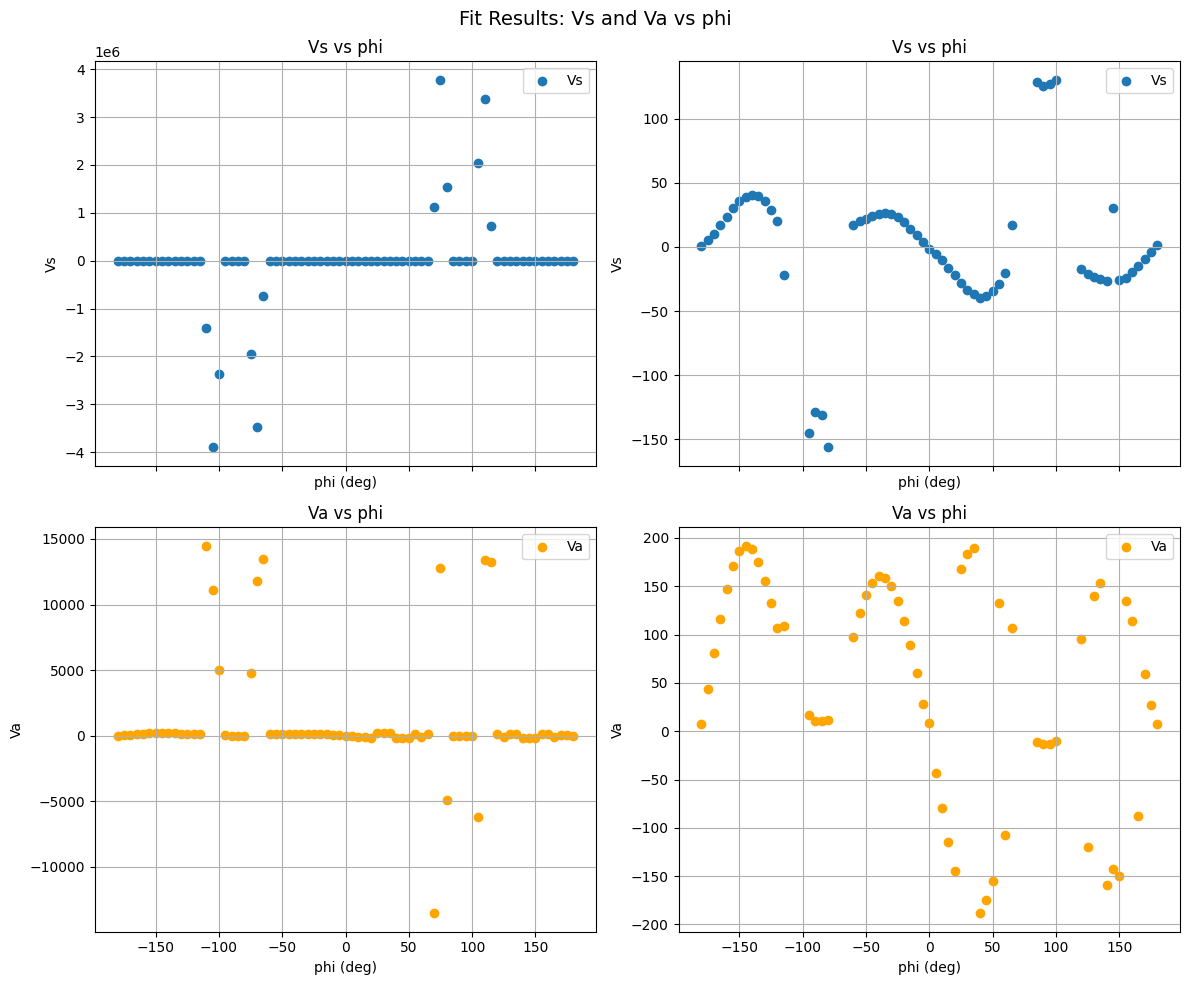

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

class FitResultsPlotter:
    def __init__(self, filepath="fit_results.csv"):
        self.filepath = filepath
        self.df = pd.read_csv(filepath)
        self.df1 = pd.read_csv(r".\AngularScan\fit_results_average.csv")

    def plot_vs_va(self):
        fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

        # --- Plot Vs vs phi ---
        print(self.df["phi"])
        print(self.df["Vs"])

        df1 = self.df

        axes[0,0].scatter(df1["phi"], df1["Vs"], label="Vs")
        axes[0,0].set_xlabel("phi (deg)")
        axes[0,0].set_ylabel("Vs")
        axes[0,0].set_title("Vs vs phi")
        axes[0,0].grid(True)
        axes[0,0].legend()
        
        df0 = self.df[(self.df["Vs"].between(-0.5e6, 0.5e6))]

        axes[0,1].scatter(df0["phi"], df0["Vs"], label="Vs")
        axes[0,1].set_xlabel("phi (deg)")
        axes[0,1].set_ylabel("Vs")
        axes[0,1].set_title("Vs vs phi")
        axes[0,1].grid(True)
        axes[0,1].legend()
        # --- Plot Va vs phi ---
        df2 = self.df

        axes[1,0].scatter(df2["phi"], df2["Va"], color="orange", label="Va")
        axes[1,0].set_xlabel("phi (deg)")
        axes[1,0].set_ylabel("Va")
        axes[1,0].set_title("Va vs phi")
        axes[1,0].grid(True)
        axes[1,0].legend()

        # df2 = self.df
        df3 = self.df[(self.df["Va"].between(-2.5e3, 2.5e3))]

        axes[1,1].scatter(df3["phi"], df3["Va"], color="orange", label="Va")
        axes[1,1].set_xlabel("phi (deg)")
        axes[1,1].set_ylabel("Va")
        axes[1,1].set_title("Va vs phi")
        axes[1,1].grid(True)
        axes[1,1].legend()

        plt.suptitle("Fit Results: Vs and Va vs phi", fontsize=14)
        plt.tight_layout()
        plt.show()


# Example usage:
if __name__ == "__main__":
    plotter = FitResultsPlotter(r".\AngularScan\fit_results_average.csv")
    plotter.plot_vs_va()


In [ ]:
# ST-FMR analysis

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import re
import os 
import glob
import sys
from pathlib import Path

folder = ".\Data"

# STFMR Class 1.1
class STFMR:
    def __init__(self, folder=None, filename=None, voltage_unit='uV', d_FM=None, d_NM=None, Ms=None, Width=None, Length=None, used_fields='Pos'):
        """
        Parameters
        ----------
        filename : str
            Path to data file
        """
        if folder is not None:
            self.folder = folder
        if filename is not None:
            self.filename = filename

        self.pattern = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Trace_(?P<trace>\d+)"
        )

        self.patternDC = re.compile(
            r"Phi_(?P<phi>[+-]?\d+(?:\.\d+)?)deg_"
            r"Freq_(?P<freq>[+-]?\d+(?:\.\d+)?)GHz_"
            r"Pow_(?P<pow>[+-]?\d+(?:\.\d+)?)dBm_"
            r"Curr_(?P<dc>[+-]?\d+(?:\.\d+)?)mA_"
            r"Trace_(?P<trace>\d+)"
        )

        # Physical constants
        self.mu_B = 9.274009994e-24  # Bohr magneton [J/T]
        self.e = 1.602176634e-19     # elementary charge [C]
        self.mu_0 = 4 * np.pi * 1e-7 # vacuum permeability [H/m]
        self.gamma = 1.760859e11     # gyromagnetic ratio [rad/(s·T)]
        self.hbar = 6.626e-34

        # System settings
        self.voltage_unit = voltage_unit  
        self.d_FM = d_FM
        self.d_NM = d_NM
        self.Ms = Ms
        self.Width = Width
        self.Lenght = Length
        self.used_fields=used_fields
        # self.remove_symmetric = remove_symmetric #In principle not necessary, if you look at used_fields which could also be 'Both'

    # -----------Data loading and preprocessing-----------
    def get_key(self, filepath):
        """Create a key for a file, which describes the most important parameters of the datafile. Distinghuishes between measurement with or without DC."""
        filename = Path(filepath).name
        if 'Curr' in filename:
            # print('filename:', filename)
            match = self.patternDC.search(filename)
            # print('Pattern:', self.patternDC)
            # print('match:', match)
            if match:
                phi, freq, pow_, dc, trace = match.groups()
                return (phi, freq, pow_, dc, trace)
            return None
        
        else:
            # print('filename:', filename)
            match = self.pattern.search(filename)
            # print('Pattern:', self.pattern)
            # print('match:', match)
            if match:
                phi, freq, pow_, trace = match.groups()
                return (phi, freq, pow_, trace)
            return None
    
    def group_files(self):
        """Groups files based on their key. Will be performed for the inputted folder in the class. """
        grouped_files = {}
        for filename in os.listdir(self.folder):
            if filename.lower().endswith(".txt"): 
                if 'Curr' in filename:
                    (phi, freq, pow_, dc, trace) = self.get_key(filename)
                    key = (phi, freq, pow_, dc)
                else:           
                    (phi, freq, pow_, trace) = self.get_key(filename)
                    key = (phi, freq, pow_)
                grouped_files.setdefault(key, []).append(filename)
            # print(grouped_files)
        return grouped_files

    def parse_resistance(self, first_line):
        # Look for "R = 93.6 Ohm" with flexible spaces
        match = re.search(r"R\s*=\s*([0-9.]+)\s*Ohm", first_line)
        if match:
            return float(match.group(1))
        else:
            raise ValueError(f"Could not parse resistance from line: '{first_line}'")
        
    def read_file(self, filepath):
         # Read the resistance value from the first line
        with open(filepath, 'r') as f:
            first_line = f.readline().strip()

        # Extract resistance value (assuming format 'R =93.6Ohm')
        R = self.parse_resistance(first_line)

        # Read the actual data starting from the second line
        df = pd.read_csv(filepath, sep='\t', skiprows=1, header=0)

        if self.voltage_unit == 'uV':
            df['Vx'] *= 1e6  # Convert Vx to microvolts
            df['Vy'] *= 1e6  # Convert Vy to microvolts
        elif self.voltage_unit == 'mV':
            df['Vx'] *= 1e3  # Convert Vx to millivolts
            df['Vy'] *= 1e3  # Convert Vy to millivolts

        # Make a copy of the magnitude column
        df["H_signed"] = df["H_mag"]
        H = df["H_given"].to_numpy()
        H_signed = H.copy()
        idx_half = len(H) // 2

        # Case 1: symmetric sweep (e.g. 2,1,0,1,2) 
        if abs(H[0]) == abs(H[-1]):
            # print("Detected symmetric sweep: multiplying first half with -1.")
            df.loc[:idx_half, "H_signed"] *= -1
            if self.used_fields == 'Neg':
                # Keep only positive fields
                df = df.iloc[:idx_half+1].reset_index(drop=True)
            elif self.used_fields == 'Pos':
                # Keep only negative fields
                df = df.iloc[idx_half:].reset_index(drop=True)
            elif self.used_fields == 'Both':
                df.loc[:idx_half, "H_signed"] *= -1
            return R, df

        # Case 2: monotonic positive sweep (e.g. 0,1,2)
        else:
            # print("Detected positive-only sweep: kept fields as it is.")
            return R, df

    def plot_traces(self):
        # Check for set folder or filename. Then extract data and plot
        if self.folder is not None:
            grouped_files = self.group_files()

            fig, ax = plt.subplots(len(grouped_files), 1, figsize=(8, 11*len(grouped_files)))
            for i, (key, files) in enumerate(grouped_files.items()):
                for f in files:
                    path = os.path.join(self.folder, f)
                    if 'Curr' in f:
                        (phi, freq, pow_, dc, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nDC={dc}\nTrace={trace}")
                    else:
                        (phi, freq, pow_, trace) = self.get_key(f)
                        ax[i].set_title(f"Phi={phi}deg\nFreq={freq}GHz\nPow={pow_}dBm\nTrace={trace}")
                    R, df = self.read_file(path)
                    # PLOT FUNCTION
                    ax[i].plot(df["H_signed"], df["Vx"], '.', label=f"Trace {trace}")
                    ax[i].set_xlabel("Field (mT)")
                    ax[i].set_ylabel(f"$Vmix$ ({self.voltage_unit})")
                    ax[i].legend(fontsize='small')
                    # PLOT FUNCTION
        
        elif self.filename is not None:
            pass
        else:
            sys.exit("Folder or filename not set. Please initialize STFMR with a folder path to datafiles.")


    def average_traces(self, plot=False):
        """Function that takes measurements from different traces. Subsequently averages all datapoints and performs a fit for these datapoints. Technically this is not right, as you first do a fit for multiple measurements and take the average of the fitting parameters. Actually, also the avg of the field in x is taken, so this function does not make much sense. """
        try:
            if self.used_fields== 'Pos':
                output_folder = os.path.join(self.folder, "Averaged_Traces_posB")
            elif self.used_fields== 'Neg':
                output_folder = os.path.join(self.folder, "Averaged_Traces_negB")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles with multiple traces.")

        os.mkdir(output_folder) if not os.path.exists(output_folder) else None
        [os.remove(f.path) for f in os.scandir(output_folder) if f.is_file()]

        # Collect files by (Phi, Freq, Pow, DC)
        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            if len(key) == 4:
                phi, freq, pow_, dc = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Curr_{dc}mA_Trace_0.txt"
            elif len(key) == 3:
                phi, freq, pow_ = key
                outname = f"Average_Phi_{phi}deg_Freq_{freq}GHz_Pow_{pow_}dBm_Trace_0.txt"
            else:
                raise ValueError(f"Unexpected key length: {len(key)}")
            
            dfs = []
            for f in files:
                path = os.path.join(self.folder, f)
                R, df = self.read_file(path)
                df['Vx'] *= (1e-6 if self.voltage_unit == 'uV' else 1e-3 if self.voltage_unit == 'mV' else 1) # Keeping data files in volts for consistency in datafiles, file is read again below changing unit back uV/mV
                df['Vy'] *= (1e-6 if self.voltage_unit == 'uV' else 1e-3 if self.voltage_unit == 'mV' else 1)
                dfs.append(df)

            all_df = pd.concat(dfs)
            avg_df = all_df.groupby(level=0).mean()
            vx_std = all_df.groupby(level=0)['Vx'].std()
            avg_df['Vxstd'] = vx_std

            # Save averaged file
            outpath = os.path.join(output_folder, outname)
            with open(outpath, "w") as f:
                f.write(f"R ={R}Ohm\n")  # Write resistance
            avg_df.to_csv(outpath, sep="\t", index=False, mode="a")

            self.fit_Vmix(outpath, plot=plot)
        
        return output_folder
    
    def plot_Vmix(self, df, fit_params, keys=None, textbox=True):
            Vs, Va, Hres, Delta, C = fit_params["Vs"], fit_params["Va"], fit_params["Hres"], fit_params["Delta"], fit_params["C"]

            plt.figure(figsize=(8,6))
            if "Vxstd" in df.columns:
                plt.errorbar(df["H_given"], df["Vx"], df["Vxstd"], fmt='.', label="data")
            else:
                plt.plot(df["H_given"], df["Vx"], '.', label="data")

            H = np.linspace(min(df["H_signed"]), max(df["H_signed"]), 200)
            plt.plot(H, STFMR.stfmr_model(H, **fit_params), '-', label="fit")
            plt.plot(H, STFMR.stfmr_symmetric(H, Vs, Hres, Delta, C), '--', label="symmetric")
            plt.plot(H, STFMR.stfmr_asymmetric(H, Va, Hres, Delta, C), '--', label="asymmetric")
            if keys is not None:
                plt.title(f"Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm")
                if keys[3] is not None:
                    plt.title(f"Phi={keys[0]}deg, Freq={keys[1]}GHz, Pow={keys[2]}dBm, DC={keys[3]}mA")

            plt.xlabel("Field (mT)")
            plt.ylabel(f"Vmix ({self.voltage_unit})")

            if textbox:
                # --- Add textbox with fit parameters ---
                position = 0.8 if self.used_fields == 'Pos' else 0.05
                textstr = '\n'.join((
                    r"$V_s=%.3g$" % Vs,
                    r"$V_a=%.3g$" % Va,
                    r"$H_{res}=%.3g$" % Hres,
                    r"$\Delta=%.3g$" % Delta,
                    r"$C=%.3g$" % C
                ))
                # Place text box in lower right corner of the plot
                plt.gca().text(
                    position, 0.22, textstr,
                    transform=plt.gca().transAxes,
                    fontsize=10,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                )

            plt.legend()
            plt.show()


    def fit_Vmix(self, filepath, plot=True, textbox=True, cutoff=5):
        R, df = self.read_file(filepath)
        keys = self.get_key(filepath)

        if self.used_fields == 'Pos':
            H_min, H_max = 0, 250
        elif self.used_fields == 'Neg':
            H_min, H_max = -250, 0
        df_filtered = df[(df["H_signed"] >= H_min) & (df["H_signed"] <= H_max)] # creating a proper field range

        fit_params, cov = self.fit_stfmr(df_filtered["H_signed"][cutoff:-cutoff], df_filtered["Vx"][cutoff:-cutoff]) # cutoff to remove outlier points

        if plot == True:
            self.plot_Vmix(df_filtered, fit_params, keys)

        return fit_params
    
    def average_fitparams(self):
        """"Creates a .csv file with averages of the fitting variables from different measurements with different trace number.  """
        try:
            if self.used_fields == 'Pos':
                resultpath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg': 
                resultpath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file, in case needs to be updated

        grouped_files = self.group_files()

        # Process each group
        for key, files in grouped_files.items():
            temp = {"Vs": [], "Va": [], "Hres": [], "Delta": [], "C": []}

            for f in files:
                fitparams_f = self.fit_Vmix(os.path.join(self.folder, f), plot=False)
                temp["Vs"].append(fitparams_f["Vs"])
                temp["Va"].append(fitparams_f["Va"])  
                temp["Hres"].append(fitparams_f["Hres"])
                temp["Delta"].append(fitparams_f["Delta"])
                temp["C"].append(fitparams_f["C"])

            fitparams_avg = {key: np.mean(value) for key, value in temp.items()}
            fitparams_std = {k: np.std(v) for k, v in temp.items()}

            self.append_fit_results(f, fitparams_avg, std_dict=fitparams_std)
        return 
    
    def append_fit_results(self, filepath, fit_params, std_dict=None):
        filepath = Path(filepath)  # ensure Path
        has_curr = "Curr" in filepath.name

        # Extract keys
        if has_curr:
            phi, freq, pow_, dc, trace = self.get_key(filepath)
        else:
            phi, freq, pow_, trace = self.get_key(filepath)
            dc = None  # keep dc consistent

        # Decide filenames
        if self.used_fields == 'Pos':
            results_file = os.path.join(
                self.folder,
                "fit_results_average_posB.csv" if std_dict is not None else "fit_results_posB.csv"
            )
        elif self.used_fields == 'Neg': 
            results_file = os.path.join(
                self.folder,
                "fit_results_average_negB.csv" if std_dict is not None else "fit_results_negB.csv"
            )

        # Ensure file exists with header
        if not os.path.exists(results_file):
            with open(results_file, "w") as f:
                if std_dict is None:  # no averages
                    header = (
                        "Filename,phi,freq,pow_,dc,trace,Vs,Va,Hres,Delta,C\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,Vs,Va,Hres,Delta,C\n"
                    )
                else:  # averages
                    header = (
                        "Filename,phi,freq,pow_,dc,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                        if has_curr else
                        "Filename,phi,freq,pow_,trace,"
                        "Vs,Vsstd,Va,Vastd,Hres,Hresstd,Delta,Deltastd,C,Cstd\n"
                    )
                f.write(header)

        # Append row
        with open(results_file, "a") as f:
            if std_dict is None:  # single run --- add fit errors
                row = (
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                    f"{fit_params['Vs']},{fit_params['Va']},{fit_params['Hres']},"
                    f"{fit_params['Delta']},{fit_params['C']}\n"
                    if has_curr else
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                    f"{fit_params['Vs']},{fit_params['Va']},{fit_params['Hres']},"
                    f"{fit_params['Delta']},{fit_params['C']}\n"
                )
            else:  # averages
                trace = "avg"
                row = (
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {dc}, {trace}, "
                    f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                    f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                    f"{fit_params['C']},{std_dict['C']}\n"
                    if has_curr else
                    f"{filepath.name}, {phi}, {freq}, {pow_}, {trace}, "
                    f"{fit_params['Vs']},{std_dict['Vs']},{fit_params['Va']},{std_dict['Va']},"
                    f"{fit_params['Hres']},{std_dict['Hres']},{fit_params['Delta']},{std_dict['Delta']},"
                    f"{fit_params['C']},{std_dict['C']}\n"
                )
            f.write(row)
        
    def angular_scan(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
       
        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

        df = pd.read_csv(resultspath)
        self.df = df.sort_values(by="phi")  # sort by angle
        self.df1 = self.df[(self.df["Va"].between(-0.5e3, 0.5e3))] # remove outliers
        self.df2 = self.df[(self.df["Vs"].between(-0.5e3, 0.5e3))]

        # --- Plot Vs vs phi ---
        axes[0].plot(self.df["phi"], self.df["Va"], "s-", color="orange", label="Va")
        axes[0].plot(self.df["phi"], self.df["Vs"], "o-", label="Vs")
        axes[0].set_xlabel("phi (deg)")
        axes[0].set_ylabel(f"V ({self.voltage_unit})")
        axes[0].set_title("Va and Vs with outliers")
        axes[0].grid(True)
        axes[0].legend()
        
        axes[1].plot(self.df1["phi"], self.df1["Va"], "s-", color="orange", label="Va")
        axes[1].plot(self.df2["phi"], self.df2["Vs"], "o-", label="Vs")
        axes[1].set_xlabel("phi (deg)")
        axes[1].set_ylabel(f"Va ({self.voltage_unit})")
        axes[1].set_title("Va and Vs without outliers")    
        axes[1].grid(True)
        axes[1].legend()

        # --- Plot Va vs phi ---
        axes[2].plot(self.df["phi"], self.df["C"], "s-", color="orange", label="Vbias")
        axes[2].set_xlabel("phi (deg)")
        axes[2].set_ylabel(f"Vbias ({self.voltage_unit})")
        axes[2].set_title("Vbias")
        axes[2].grid(True)
        axes[2].legend()

        plt.suptitle(f"Fit Results of angular scan, frequency={df['freq'].iloc[1]} GHz and {self.used_fields} field sweep", fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_Kittel(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath):
            self.average_fitparams()

        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)

        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle
        
        mu0_Hres = np.array(df_sorted['Hres'])*self.mu_0
        params, pocv = curve_fit(self.Kittel_formula, mu0_Hres, df_sorted['freq'], p0=[1])
        # Meff = (params[0]*1e-3)/self.mu_0
        print(params)
        # for i, v in enumerate(df_sorted['Vs']):
            # print('Calculating SOT efficiency with Vs=', df_sorted['Vs'].iloc[i], 'Va =',df_sorted['Va'].iloc[i], 'Ms=', self.Ms,'A/m3, d_FM=', self.d_FM, 'd_NM=', self.d_NM, 'Mres=',df_sorted['Hres'].iloc[i], 'Meff', Meff )

            # Mres_A_m =  (df_sorted['Hres'].iloc[i]*1e-3)/self.mu_0

            # xi_fmr = self.FMR_efficiency(df_sorted['Vs'].iloc[i], df_sorted['Va'].iloc[i], self.Ms, self.d_FM, self.d_NM, Mres_A_m, Meff)
            # print('xi_FMR = ' , xi_fmr)

        if self.used_fields == 'Pos':
            H = np.linspace(0, max(mu0_Hres)*1.1, 200)
        elif self.used_fields == 'Neg':
            H = np.linspace(1.1*min(mu0_Hres), 0, 200)

        # --- Plot H vs freq ---
        axes.errorbar(mu0_Hres, df_sorted["freq"], df_sorted["Hresstd"], 0, "o-", label="Vs")
        axes.plot(H, self.Kittel_formula(H, *params), '-', label="Kittel fit")
        axes.set_xlabel("$\mu Hres$ (mT)")
        axes.set_ylabel(f"Frequency (GHz)")
        axes.grid(True)
        axes.legend()
        # axes.set_ylim(bottom=0)
        plt.suptitle("Fit Results: Resonance Field vs Frequency", fontsize=14)
        plt.tight_layout()
        plt.show()

    def plot_linewidth(self):
        try:
            if self.used_fields == 'Pos':
                resultspath = os.path.join(self.folder, "fit_results_average_posB.csv")
            elif self.used_fields == 'Neg':
                resultspath = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")
        
        fig, axes = plt.subplots(1, 1, figsize=(12, 10), sharex=True)
        df = pd.read_csv(resultspath)
        df_sorted = df.sort_values(by="freq")  # sort by angle

        params, pocv = curve_fit(self.linewidth_formula, df_sorted["freq"], df_sorted['Delta'], p0=[1/self.mu_0, 1])

        # print(params)
        if self.used_fields == 'Pos':
            freq = np.linspace(0, max(df_sorted["freq"])*1.2, 200)
        elif self.used_fields == 'Neg':
            freq = np.linspace(1.2*min(df_sorted['freq']), 0, 200)

        # --- Plot H vs freq ---
        axes.errorbar(df_sorted["freq"], df_sorted["Delta"], df_sorted["Deltastd"], 0, "o-", label="$")
        axes.plot(freq, self.linewidth_formula(freq, *params), '-', label="Linewidth fit")
        axes.set_xlabel("Frequency (GHz)")
        axes.set_ylabel(f"$\mu \Delta H_0$ (mT)")
        axes.grid(True)
        axes.legend()
        axes.set_xlim(right=15)
        axes.set_ylim(bottom=0)
        plt.suptitle("Fit Results: $\mu H_0$ vs frequency", fontsize=14)
        plt.tight_layout()
        plt.show()
        return

    def DCScan(self):
        try:
            resultspath_pos = os.path.join(self.folder, "fit_results_average_posB.csv")
            resultspath_neg = os.path.join(self.folder, "fit_results_average_negB.csv")
        except AttributeError:
            sys.exit("Folder not set. Please initialize STFMR with a folder path to datafiles.")

        if not os.path.exists(resultspath_pos):
            self.average_fitparams()
        if not os.path.exists(resultspath_neg):
            self.average_fitparams()

        fig, axes = plt.subplots(3, 1, figsize=(12, 24), sharex=True)
        df_pos = pd.read_csv(resultspath_pos)
        df_neg = pd.read_csv(resultspath_neg)

        df_pos = df_pos.sort_values(by="dc")  # sort by dc current
        # print(df_pos.head())
        df_neg = df_neg.sort_values(by="dc")  # sort by dc current
        # print(df_neg.head())

        # Define a common errorbar style for consistency
        err_style = dict(
            fmt="+-",             # circle markers, no connecting line
            capsize=4,           # small caps on error bars
            elinewidth=1,        # thin error bar lines
            linewidth=1,
            markersize=7,        # marker size
            mec="black",         # marker edge color
        )

        # --- Plot Delta vs dc ---
        axes[0].errorbar(
            df_neg["dc"].iloc[:],
            df_neg["Delta"].iloc[:],
            df_neg["Deltastd"].iloc[:],
            label="Delta negative field",
            color="tab:red",
            **err_style
        )
        axes[0].errorbar(
            df_pos["dc"].iloc[:-2],
            df_pos["Delta"].iloc[:-2],
            df_pos["Deltastd"].iloc[:-2],
            label="Delta positive field",
            color="tab:blue",
            **err_style
        )
        
        axes[0].set_xlabel("dc (mA)")
        axes[0].set_ylim(4, 7)
        axes[0].set_ylabel("Delta")
        axes[0].set_title("Delta vs dc")
        axes[0].grid(True, linestyle="--", alpha=0.6)
        axes[0].legend()

        # --- Plot Vs vs dc ---
        axes[1].errorbar(
            df_pos["dc"].iloc[:-2],
            df_pos["Vs"].iloc[:-2],
            df_pos["Vsstd"].iloc[:-2],
            label="Vs positive field",
            color="tab:blue",
            **err_style
        )
        axes[1].errorbar(
            df_neg["dc"].iloc[:],
            df_neg["Vs"].iloc[:],
            df_neg["Vsstd"].iloc[:],
            label="Vs negative field",
            color="tab:red",
            **err_style
        )
        axes[1].set_xlabel("dc (mA)")
        axes[1].set_ylabel(f"Vs ({self.voltage_unit})")
        axes[1].set_title("Vs vs dc")
        axes[1].grid(True, linestyle="--", alpha=0.6)
        axes[1].legend()

        # --- Plot Va vs dc ---
        axes[2].errorbar(
            df_pos["dc"].iloc[:-2],
            df_pos["Va"].iloc[:-2],
            df_pos["Vastd"].iloc[:-2],
            label="Va positive field",
            color="tab:blue",
            **err_style
        )
        axes[2].errorbar(
            df_neg["dc"].iloc[:],
            df_neg["Va"].iloc[:],
            df_neg["Vastd"].iloc[:],
            label="Va negative field",
            color="tab:red",
            **err_style
        )
        axes[2].set_xlabel("dc (mA)")
        axes[2].set_ylabel(f"Va ({self.voltage_unit})")
        axes[2].set_title("Va vs dc")
        axes[2].grid(True, linestyle="--", alpha=0.6)
        axes[2].legend()
        fig.suptitle("DK159", fontsize=14, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    def analyse_folder(self, plot=False):
        if self.used_fields == 'Pos':
            resultpath = os.path.join(self.folder, "fit_results_posB.csv")
        elif self.used_fields=='Neg':
            resultpath = os.path.join(self.folder, "fit_results_negB.csv")

        if os.path.exists(resultpath):
            os.remove(resultpath)  # delete existing results file
        # print(resultpath)

        for fname in os.listdir(self.folder):
            if fname.lower().endswith(".txt"):
                filepath = os.path.join(self.folder, fname)   # ✅ build full path
                # print(fname)
                fitparams = self.fit_Vmix(filepath, plot=plot)
                self.append_fit_results(filepath, fitparams)
    
    def read_and_print_csv(self, name):
        path = os.path.join(self.folder, name)
        df = pd.read_csv(path, delimiter=',', header=0)
        # print(df)


    # ---------------- FIT MODEL ----------------
    def Kittel_formula(self, Hres, Ms):
        return ((self.gamma*self.mu_0) / (2 * np.pi)) * np.sqrt((Hres) * (Hres + Ms))

    def linewidth_formula(self, f, DeltaH0, alpha):
        return self.mu_0*DeltaH0 + (np.pi * 2 * f*1e12 * alpha)/self.gamma
    
    def tau_DL(self, xi_DL, Je, Ms, t_FM):
        """Damping-like torque"""
        return xi_DL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_FL(self, xi_FL, Je, Ms, t_FM):
        """Field-like torque"""
        return xi_FL * self.mu_B * Je / (self.e * Ms * t_FM)

    def tau_Oe(self, mu_0, gamma, Je, t_HM):
        """Oersted torque"""
        return mu_0 * gamma * Je * t_HM / 2
    
    def FMR_efficiency(self, Vs, Va, Ms, d_FM, d_NM, Hres, Meff=1):
        # print('Vs/Va', Vs/Va, 'Hres', (Hres*1e-3)/self.mu_0)

        return (Vs/Va) * (self.e/self.hbar) * (self.mu_0 * Ms * d_FM * d_NM ) * np.sqrt(1+(((4* np.pi* Meff))/Hres))
    
    @staticmethod
    def stfmr_model(H, Vs, Va, Hres, Delta, C):
        """
        ST-FMR mixing voltage model.
        """
        # sym = Vs * (Delta**2) / ((H - Hres)**2 + Delta**2)
        # asym = Va * (Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2)
        sym = STFMR.stfmr_symmetric(H, Vs, Hres, Delta, 0)
        asym = STFMR.stfmr_asymmetric(H, Va, Hres, Delta, 0)
        return sym + asym + C

    def stfmr_symmetric(H, Vs, Hres, Delta, C):
        """
        Symmetric part of ST-FMR mixing voltage model.
        """
        return Vs * ((Delta**2) / ((H - Hres)**2 + Delta**2)) + C
    
    def stfmr_asymmetric(H, Va, Hres, Delta, C):
        """
        Asymmetric part of ST-FMR mixing voltage model.
        """
        return Va * ((Delta * (H - Hres)) / ((H - Hres)**2 + Delta**2)) + C

    def fit_stfmr(self, H, V, p0=None, bounds=None):
        """        
        Parameters:
        H : array-like, Field values [mT]
        V : array-like, Mixing voltage [uV]
        p0 : list, optional, Initial guess [Vx, Vy, Hres, Delta, C]
        """
        if p0 is None:
            # crude guesses: peak ~ Vx, min ~ Vy, center ~ Hres
            try:
                Hres_guess = H[np.argmax(V)]
            except:
                Hres_guess = 0
            Delta_guess = abs(max(H) - min(H)) / 10
            Vs_guess = (max(V)-np.mean(V) if np.mean(V) > 0 else max(V)-np.mean(V))
            # print(Vs_guess, max(V), np.mean(V), min(V))
            Va_guess = (max(V) - min(V)) /2
            C = np.mean(V)
            p0 = [Vs_guess, Va_guess, Hres_guess, Delta_guess, C]

        sign_min = 4 if min(V) < 0 else -4
        sign_max = -4 if max(V) < 0 else 4

        if self.used_fields == 'Pos':
            H_min, H_max = 0, np.inf
        if self.used_fields == 'Neg':
            H_min, H_max = -np.inf, 0
                
        bounds = ( 
            [-np.inf, -np.inf, H_min, 0, -np.inf], # lower bounds (Delta >= 0) 
            [np.inf, np.inf, H_max, np.inf, np.inf] # upper bounds 
            )
        # print(bounds)
        popt, pcov = curve_fit(
            self.stfmr_model,
            H, V,
            p0=p0,
            bounds=bounds,
            maxfev=100000
        )
        return {
            "Vs": popt[0],
            "Va": popt[1],
            "Hres": popt[2],
            "Delta": popt[3],
            "C": popt[4] 
        }, pcov


# Example usage
folder1 = ".\\DK158\\AngularScan"
folder2 = ".\\DK158\\FrequencyScan"
folder3 = ".\\DK158\\DCScan"
folder4 = ".\\DK158\\PowerScan"
stfmr1 = STFMR(folder=folder1, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6)
stfmr2 = STFMR(folder=folder2, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6, used_fields='Pos')
stfmr3 = STFMR(folder=folder3, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=20e-6)
stfmr4 = STFMR(folder=folder4, voltage_unit='uV', d_FM=5e-9, d_NM=5e-9, Ms=1e6, Width=20e-6, Length=40e-6)


# stfmr2.plot_traces()
# stfmr2.average_traces(plot=True)

# stfmr2.analyse_folder(plot=True)
# stfmr2.analyse_folder(plot=False, remove_symmetric=True, used_fields='Neg')
# stfmr2.average_fitparams()
# stfmr2.read_and_print_csv('fit_results_average_posB.csv')
stfmr2.plot_linewidth()
stfmr2.plot_Kittel()
# stfmr2.average_fitparams(used_fields='Neg') check if this averages in right way

# stfmr2.frequency_scan(plot=True, used_fields='Pos')
# stfmr2.frequency_scan(plot=True, used_fields='Neg')

